<a href="https://colab.research.google.com/github/atikhasan007/Machine-Learning/blob/main/tft_and_n_beats_another_filefinal1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

atikhasannnnn_weather_data_path = kagglehub.dataset_download('atikhasannnnn/weather-data')

print('Data source import complete.')


100%|██████████| 78.7M/78.7M [00:05<00:00, 15.3MB/s]

Extracting files...


Data source import complete.


**import all necessary library**

In [2]:
# Basic Python Libraries
import os
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#  Statistical Analysis
from scipy import stats

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# Reproducibility
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)




In [3]:
# Device Configuration
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.11.0+cu128
Device: cuda


**Dataset Load**

In [4]:
import pandas as pd

df_2025 = pd.read_csv(
    "/content/Alice_Springs_2025.csv",
    engine="python",
    on_bad_lines="skip"
)

df_2026 = pd.read_csv(
    "/content/Alice_Springs_2026.csv",
    engine="python",
    on_bad_lines="skip"
)

print("2025 shape:", df_2025.shape)
print("2026 shape:", df_2026.shape)

2025 shape: (105391, 210)
2026 shape: (12090, 210)


In [5]:
common_cols = set(df_2025.columns) & set(df_2026.columns)

print("2025 columns:", len(df_2025.columns))
print("2026 columns:", len(df_2026.columns))
print("Common columns:", len(common_cols))
print("Merged columns:", len(set(df_2025.columns) | set(df_2026.columns)))

2025 columns: 210
2026 columns: 210
Common columns: 14
Merged columns: 406


In [6]:
# common column
print(sorted(common_cols))

['100_DKA_M1_A_Phase_Active_Energy_Delivered_Received', '100_DKA_M1_A_Phase_Active_Power', '100_DKA_M1_A_Phase_Current_Phase_Average', '100_DKA_M1_A_Phase_Performance_Ratio', '103_DKA_M1_B_Phase_Active_Energy_Delivered_Received', '103_DKA_M1_B_Phase_Active_Power', '103_DKA_M1_B_Phase_Current_Phase_Average', '105_DKA_M1_C_Phase_Active_Energy_Delivered_Received', '105_DKA_M1_C_Phase_Active_Power', '105_DKA_M1_C_Phase_Current_Phase_Average', '205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Energy_Delivered_Received', '205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Power', '205_Archived_DKA_M15_BPhase_UMG_QCells_Current_Phase_Average', 'timestamp']


**Dataset marge**

In [7]:
# Merge datasets
df = pd.concat(
    [df_2025, df_2026],
    axis=0,
    ignore_index=True
)

In [8]:
# check the marge dataset shape
df.shape

(117481, 406)

In [9]:
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

0: timestamp
1: 205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Energy_Delivered_Received
2: 205_Archived_DKA_M15_BPhase_UMG_QCells_Current_Phase_Average
3: 205_Archived_DKA_M15_BPhase_UMG_QCells_Active_Power
4: 239_DKA_Totals_BESS_Reactive_Power
5: 239_DKA_Totals_BESS_Active_Power
6: 239_DKA_Totals_BESS_Apparent_Power
7: 239_DKA_Totals_BESS_State_of_Charge
8: 242_DKA_Totals_Grid_Reactive_Power
9: 242_DKA_Totals_Grid_Active_Power
10: 242_DKA_Totals_Grid_Apparent_Power
11: 241_DKA_Totals_PV_Reactive_Power
12: 241_DKA_Totals_PV_Active_Power
13: 241_DKA_Totals_PV_Apparent_Power
14: 240_DKA_Totals_Site_Demand_Reactive_Power
15: 240_DKA_Totals_Site_Demand_Active_Power
16: 240_DKA_Totals_Site_Demand_Apparent_Power
17: 100_DKA_M1_A_Phase_Active_Energy_Delivered_Received
18: 100_DKA_M1_A_Phase_Current_Phase_Average
19: 100_DKA_M1_A_Phase_Active_Power
20: 100_DKA_M1_A_Phase_Performance_Ratio
21: 103_DKA_M1_B_Phase_Active_Energy_Delivered_Received
22: 103_DKA_M1_B_Phase_Current_Phase_Average
23: 1

In [10]:
# feature selection
target_col = "241_DKA_Totals_PV_Active_Power"

weather_features = [
    "101_DKA_WeatherStation_Global_Horizontal_Radiation",
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Diffuse_Horizontal_Radiation",
    "101_DKA_WeatherStation_Wind_Speed",
    "101_DKA_WeatherStation_Wind_Direction",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "101_DKA_WeatherStation_Weather_Daily_Rainfall",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
]

# ডেটাসেটে আসলে আছে কিনা যাচাই
weather_features = [c for c in weather_features if c in df.columns]
print(weather_features)

['101_DKA_WeatherStation_Global_Horizontal_Radiation', '101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Diffuse_Horizontal_Radiation', '101_DKA_WeatherStation_Wind_Speed', '101_DKA_WeatherStation_Wind_Direction', '101_DKA_WeatherStation_Weather_Relative_Humidity', '101_DKA_WeatherStation_Weather_Daily_Rainfall', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted']


In [11]:
corr_df = df[weather_features + [target_col]].corr()

print("Correlation with target (sorted):")
print(corr_df[target_col].sort_values(ascending=False))

Correlation with target (sorted):
241_DKA_Totals_PV_Active_Power                         1.000000
101_DKA_WeatherStation_Radiation_Global_Tilted         0.990146
101_DKA_WeatherStation_Global_Horizontal_Radiation     0.956140
101_DKA_WeatherStation_Radiation_Diffuse_Tilted        0.661751
101_DKA_WeatherStation_Diffuse_Horizontal_Radiation    0.519209
101_DKA_WeatherStation_Weather_Temperature_Celsius     0.414928
101_DKA_WeatherStation_Wind_Direction                  0.032775
101_DKA_WeatherStation_Weather_Daily_Rainfall         -0.034506
101_DKA_WeatherStation_Weather_Relative_Humidity      -0.449397
101_DKA_WeatherStation_Wind_Speed                           NaN
Name: 241_DKA_Totals_PV_Active_Power, dtype: float64


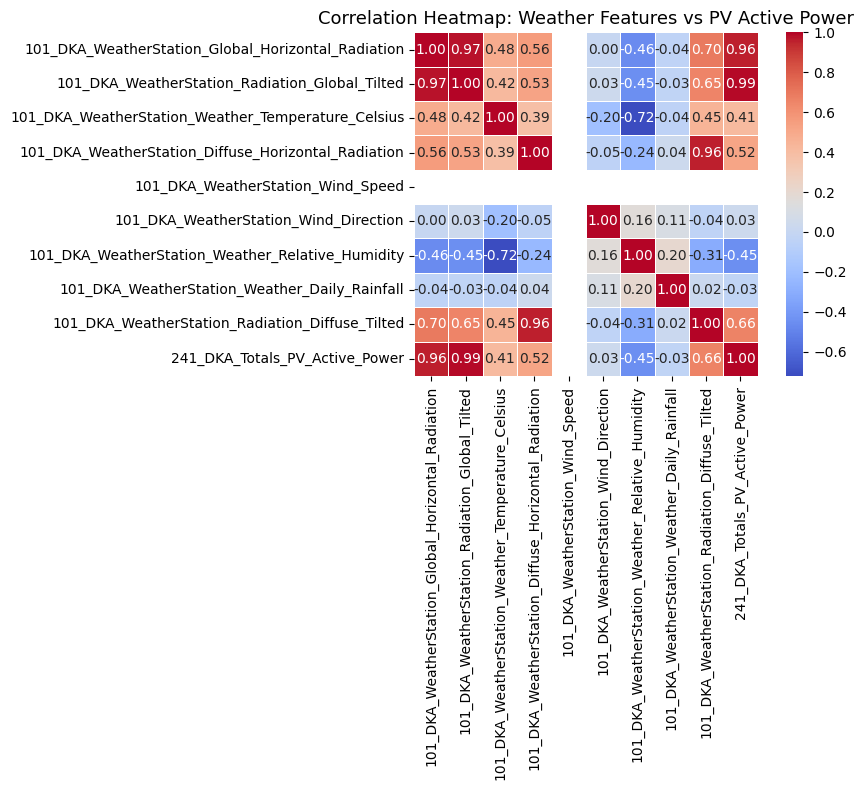

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Weather Features vs PV Active Power", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [13]:
final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Global_Horizontal_Radiation",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",  # optional
    "101_DKA_WeatherStation_Diffuse_Horizontal_Radiation",  # optional
]

# বাদ দেওয়া হলো:
# Wind_Direction (0.03), Weather_Daily_Rainfall (-0.03), Wind_Speed (NaN)

In [14]:
final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",   # target corr: 0.99 — সবচেয়ে শক্তিশালী
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",  # target corr: 0.66 — diffuse light effect
    "101_DKA_WeatherStation_Weather_Temperature_Celsius", # target corr: 0.41 — thermal effect
    "101_DKA_WeatherStation_Weather_Relative_Humidity",   # target corr: -0.45 — moisture/cloud effect
]

In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

In [16]:
# ==============================
# 1. Target and features
# ==============================

target_col_original = "241_DKA_Totals_PV_Active_Power"
target_col = "pv_power"

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

In [16]:
# ==============================
# 2. Timestamp conversion
# ==============================

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Remove invalid timestamps
df = df.dropna(subset=["timestamp"])

In [17]:
# ==============================
# 3. Sort chronologically
# ==============================

df = df.sort_values("timestamp").reset_index(drop=True)

In [18]:
# ==============================
# 4. Remove duplicate timestamps
# ==============================

print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

df = df.drop_duplicates(
    subset=["timestamp"],
    keep="first"
).reset_index(drop=True)

print("After duplicate removal:", df.shape)

Duplicate timestamps: 288
After duplicate removal: (117193, 406)


In [19]:
# ==============================
# 5. Rename target
# ==============================

df = df.rename(columns={
    target_col_original: target_col
})

In [20]:
# ==============================
# 6. Keep only required columns
# ==============================

required_columns = ["timestamp", target_col] + final_features

df = df[required_columns].copy()

print(df.shape)
print(df.columns.tolist())

(117193, 6)
['timestamp', 'pv_power', '101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Weather_Relative_Humidity']


In [21]:
# ==============================
# 7. Chronological split
# ==============================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

In [22]:
print("Train:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())

print("\nValidation:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())

print("\nTest:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())

Train:
2025-01-01 00:00:00 → 2025-10-12 20:50:00

Validation:
2025-10-12 20:55:00 → 2025-12-12 21:55:00

Test:
2025-12-12 22:00:00 → 2026-02-11 23:55:00


**missing value handelling**

In [23]:
target_col = "pv_power"

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

required_cols = ["timestamp", target_col] + final_features

print(df[required_cols].isna().sum())

timestamp                                                 0
pv_power                                              12021
101_DKA_WeatherStation_Radiation_Global_Tilted        13533
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       13533
101_DKA_WeatherStation_Weather_Temperature_Celsius    18210
101_DKA_WeatherStation_Weather_Relative_Humidity      18210
dtype: int64


In [24]:
# Missing percentage
missing_summary = pd.DataFrame({
    "missing_count": df[required_cols].isna().sum(),
    "missing_percent": (df[required_cols].isna().mean() * 100).round(2)
})

print(missing_summary)

                                                    missing_count  \
timestamp                                                       0   
pv_power                                                    12021   
101_DKA_WeatherStation_Radiation_Global_Tilted              13533   
101_DKA_WeatherStation_Radiation_Diffuse_Tilted             13533   
101_DKA_WeatherStation_Weather_Temperature_Celsius          18210   
101_DKA_WeatherStation_Weather_Relative_Humidity            18210   

                                                    missing_percent  
timestamp                                                      0.00  
pv_power                                                      10.26  
101_DKA_WeatherStation_Radiation_Global_Tilted                11.55  
101_DKA_WeatherStation_Radiation_Diffuse_Tilted               11.55  
101_DKA_WeatherStation_Weather_Temperature_Celsius            15.54  
101_DKA_WeatherStation_Weather_Relative_Humidity              15.54  


In [25]:
for col in required_cols:
    if col == "timestamp":
        continue

    is_missing = df[col].isna()

    groups = (is_missing != is_missing.shift()).cumsum()

    gap_sizes = (
        is_missing.groupby(groups)
        .sum()
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    print("Largest consecutive missing rows:", int(gap_sizes.iloc[0]))


pv_power
Largest consecutive missing rows: 11802

101_DKA_WeatherStation_Radiation_Global_Tilted
Largest consecutive missing rows: 11802

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
Largest consecutive missing rows: 11802

101_DKA_WeatherStation_Weather_Temperature_Celsius
Largest consecutive missing rows: 11802

101_DKA_WeatherStation_Weather_Relative_Humidity
Largest consecutive missing rows: 11802


In [26]:
cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:
    missing_idx = df.index[df[col].isna()]

    print(f"\n{col}")
    print("First missing:", df.loc[missing_idx.min(), "timestamp"])
    print("Last missing :", df.loc[missing_idx.max(), "timestamp"])


pv_power
First missing: 2025-01-02 03:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Radiation_Global_Tilted
First missing: 2025-01-04 09:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
First missing: 2025-01-04 09:35:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Weather_Temperature_Celsius
First missing: 2025-01-04 21:00:00
Last missing : 2026-02-11 23:55:00

101_DKA_WeatherStation_Weather_Relative_Humidity
First missing: 2025-01-04 21:00:00
Last missing : 2026-02-11 23:55:00


In [27]:
import pandas as pd

cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:

    is_missing = df[col].isna()

    # Consecutive missing groups
    groups = (is_missing != is_missing.shift()).cumsum()

    missing_blocks = (
        df.loc[is_missing]
        .groupby(groups[is_missing])
        .agg(
            start=("timestamp", "min"),
            end=("timestamp", "max"),
            rows=("timestamp", "size")
        )
    )

    # Largest missing block
    largest_block = missing_blocks.sort_values(
        "rows",
        ascending=False
    ).iloc[0]

    duration = (
        largest_block["end"] - largest_block["start"]
    )

    print(f"\n{col}")
    print("Start   :", largest_block["start"])
    print("End     :", largest_block["end"])
    print("Rows    :", largest_block["rows"])
    print("Duration:", duration)


pv_power
Start   : 2026-01-02 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 11802
Duration: 40 days 23:55:00

101_DKA_WeatherStation_Radiation_Global_Tilted
Start   : 2026-01-02 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 11802
Duration: 40 days 23:55:00

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
Start   : 2026-01-02 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 11802
Duration: 40 days 23:55:00

101_DKA_WeatherStation_Weather_Temperature_Celsius
Start   : 2026-01-02 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 11802
Duration: 40 days 23:55:00

101_DKA_WeatherStation_Weather_Relative_Humidity
Start   : 2026-01-02 00:00:00
End     : 2026-02-11 23:55:00
Rows    : 11802
Duration: 40 days 23:55:00


In [28]:
# Large continuous missing period
start_gap = pd.Timestamp("2026-01-02 00:00:00")
end_gap = pd.Timestamp("2026-02-11 23:55:00")

# Remove the complete missing block
df = df[
    ~df["timestamp"].between(start_gap, end_gap)
].copy()

# Reset index
df = df.reset_index(drop=True)

print("New shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())

New shape: (105391, 6)
Start: 2025-01-01 00:00:00
End  : 2026-01-01 23:55:00


In [29]:
required_cols = ["timestamp", "pv_power"] + final_features

missing_summary = pd.DataFrame({
    "missing_count": df[required_cols].isna().sum(),
    "missing_percent": (
        df[required_cols].isna().mean() * 100
    ).round(2)
})

print(missing_summary)

                                                    missing_count  \
timestamp                                                       0   
pv_power                                                      219   
101_DKA_WeatherStation_Radiation_Global_Tilted               1731   
101_DKA_WeatherStation_Radiation_Diffuse_Tilted              1731   
101_DKA_WeatherStation_Weather_Temperature_Celsius           6408   
101_DKA_WeatherStation_Weather_Relative_Humidity             6408   

                                                    missing_percent  
timestamp                                                      0.00  
pv_power                                                       0.21  
101_DKA_WeatherStation_Radiation_Global_Tilted                 1.64  
101_DKA_WeatherStation_Radiation_Diffuse_Tilted                1.64  
101_DKA_WeatherStation_Weather_Temperature_Celsius             6.08  
101_DKA_WeatherStation_Weather_Relative_Humidity               6.08  


In [30]:
cols_to_check = ["pv_power"] + final_features

for col in cols_to_check:

    is_missing = df[col].isna()

    groups = (is_missing != is_missing.shift()).cumsum()

    missing_blocks = (
        df.loc[is_missing]
        .groupby(groups[is_missing])
        .agg(
            start=("timestamp", "min"),
            end=("timestamp", "max"),
            rows=("timestamp", "size")
        )
        .sort_values("rows", ascending=False)
    )

    print(f"\n{'='*70}")
    print(col)
    print(missing_blocks.head(10))


pv_power
                       start                 end  rows
pv_power                                              
194      2026-01-01 14:10:00 2026-01-01 14:40:00     7
128      2026-01-01 01:30:00 2026-01-01 01:55:00     6
226      2026-01-01 21:10:00 2026-01-01 21:30:00     5
200      2026-01-01 15:30:00 2026-01-01 15:50:00     5
148      2026-01-01 05:15:00 2026-01-01 05:35:00     5
236      2026-01-01 23:00:00 2026-01-01 23:20:00     5
216      2026-01-01 18:35:00 2026-01-01 18:55:00     5
212      2026-01-01 17:55:00 2026-01-01 18:15:00     5
104      2025-12-14 23:00:00 2025-12-14 23:15:00     4
54       2025-05-30 12:50:00 2025-05-30 13:05:00     4

101_DKA_WeatherStation_Radiation_Global_Tilted
                                                             start  \
101_DKA_WeatherStation_Radiation_Global_Tilted                       
202                                            2025-09-27 14:05:00   
222                                            2025-11-02 18:00:00   
37

In [31]:
# ============================================
# Missing Value Handling
# ============================================

target_col = "pv_power"

weather_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

# --------------------------------------------
# 1. Remove rows where target is missing
# --------------------------------------------

df = df.dropna(subset=[target_col]).copy()

print("After removing missing pv_power:")
print(df.shape)


# --------------------------------------------
# 2. Interpolate only small gaps
#    Maximum 1 hour = 12 consecutive 5-min rows
# --------------------------------------------

df[weather_features] = df[weather_features].interpolate(
    method="linear",
    limit=11,
    limit_direction="both"
)


# --------------------------------------------
# 3. Remove rows where large weather gaps
#    are still missing
# --------------------------------------------

df = df.dropna(
    subset=weather_features
).reset_index(drop=True)


# --------------------------------------------
# 4. Final missing-value check
# --------------------------------------------

print("\nFinal missing values:")
print(df[["timestamp", target_col] + weather_features].isna().sum())

print("\nFinal dataset shape:")
print(df.shape)

After removing missing pv_power:
(105172, 6)

Final missing values:
timestamp                                             0
pv_power                                              0
101_DKA_WeatherStation_Radiation_Global_Tilted        0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       0
101_DKA_WeatherStation_Weather_Temperature_Celsius    0
101_DKA_WeatherStation_Weather_Relative_Humidity      0
dtype: int64

Final dataset shape:
(98054, 6)


In [32]:
# Check chronological order
is_sorted = df["timestamp"].is_monotonic_increasing

print("Chronological:", is_sorted)

Chronological: True


In [33]:
# Check duplicate timestamps
duplicate_count = df["timestamp"].duplicated().sum()

print("Duplicate timestamps:", duplicate_count)

Duplicate timestamps: 0


In [34]:
# Check timestamp intervals
time_diff = df["timestamp"].diff().dropna()

print(time_diff.value_counts().head(10))

timestamp
0 days 00:05:00     97915
0 days 00:10:00        77
0 days 00:15:00        22
0 days 00:25:00         8
0 days 00:20:00         8
0 days 00:30:00         6
0 days 00:05:02         2
0 days 00:04:59         2
0 days 00:04:58         2
20 days 23:40:00        1
Name: count, dtype: int64


In [35]:
# Show all large timestamp gaps
time_diff = df["timestamp"].diff()

large_gaps = df.loc[
    time_diff > pd.Timedelta(minutes=5),
    ["timestamp"]
].copy()

large_gaps["gap"] = time_diff[
    time_diff > pd.Timedelta(minutes=5)
].values

print(large_gaps)

                timestamp              gap
331   2025-01-02 03:40:00  0 days 00:10:00
617   2025-01-03 03:35:00  0 days 00:10:00
1668  2025-01-27 18:45:00 20 days 23:40:00
3945  2025-02-04 16:40:00  0 days 00:15:00
4080  2025-02-05 04:05:00  0 days 00:15:00
...                   ...              ...
98045 2026-01-01 22:30:00  0 days 00:15:00
98049 2026-01-01 22:55:00  0 days 00:10:00
98050 2026-01-01 23:25:00  0 days 00:30:00
98051 2026-01-01 23:35:00  0 days 00:10:00
98053 2026-01-01 23:55:00  0 days 00:15:00

[132 rows x 2 columns]


In [36]:
# Make a copy
df_regular = df.copy()

# Set timestamp as index
df_regular = df_regular.set_index("timestamp")

# Create regular 5-minute timeline
df_regular = df_regular.asfreq("5min")

print("Shape:", df_regular.shape)

print("\nMissing values after 5-min regularization:")
print(df_regular.isna().sum())

Shape: (105408, 5)

Missing values after 5-min regularization:
pv_power                                              7360
101_DKA_WeatherStation_Radiation_Global_Tilted        7360
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       7360
101_DKA_WeatherStation_Weather_Temperature_Celsius    7360
101_DKA_WeatherStation_Weather_Relative_Humidity      7360
dtype: int64


In [37]:
# Use the cleaned dataset before asfreq()
df = df.copy()

# Make sure chronological
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)

print("\nMissing values:")
print(df[required_cols].isna().sum())

Shape: (98054, 6)

Missing values:
timestamp                                             0
pv_power                                              0
101_DKA_WeatherStation_Radiation_Global_Tilted        0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted       0
101_DKA_WeatherStation_Weather_Temperature_Celsius    0
101_DKA_WeatherStation_Weather_Relative_Humidity      0
dtype: int64


In [38]:
# ============================================
# Chronological Train / Validation / Test
# ============================================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:")
print(train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Rows:", len(train_df))

print("\nValidation:")
print(val_df["timestamp"].min(), "→", val_df["timestamp"].max())
print("Rows:", len(val_df))

print("\nTest:")
print(test_df["timestamp"].min(), "→", test_df["timestamp"].max())
print("Rows:", len(test_df))

Train:
2025-01-01 00:00:00 → 2025-09-17 10:45:00
Rows: 68637

Validation:
2025-09-17 10:50:00 → 2025-11-11 08:15:00
Rows: 14708

Test:
2025-11-11 08:20:00 → 2026-01-01 23:55:00
Rows: 14709


In [39]:
print("\nTrain → Validation:")
print(train_df["timestamp"].max() < val_df["timestamp"].min())

print("\nValidation → Test:")
print(val_df["timestamp"].max() < test_df["timestamp"].min())


Train → Validation:
True

Validation → Test:
True


feature engineering

In [40]:
import numpy as np

# ============================================================
# TIME / CYCLICAL FEATURE ENGINEERING
# ============================================================

def add_time_features(data):

    data = data.copy()

    # ----------------------------------------
    # Basic time features
    # ----------------------------------------

    data["hour"] = data["timestamp"].dt.hour
    data["dayofweek"] = data["timestamp"].dt.dayofweek
    data["dayofyear"] = data["timestamp"].dt.dayofyear
    data["month"] = data["timestamp"].dt.month

    # ----------------------------------------
    # Time of day in minutes
    # ----------------------------------------

    minutes_of_day = (
        data["timestamp"].dt.hour * 60
        + data["timestamp"].dt.minute
    )

    # ----------------------------------------
    # Daily cyclical encoding
    # ----------------------------------------

    data["hour_sin"] = np.sin(
        2 * np.pi * minutes_of_day / 1440
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * minutes_of_day / 1440
    )

    # ----------------------------------------
    # Yearly / seasonal cyclical encoding
    # ----------------------------------------

    data["dayofyear_sin"] = np.sin(
        2 * np.pi *
        data["dayofyear"] / 365.25
    )

    data["dayofyear_cos"] = np.cos(
        2 * np.pi *
        data["dayofyear"] / 365.25
    )

    return data


# Apply to all splits
train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("TIME FEATURE ENGINEERING")
print("=" * 70)

new_time_features = [
    "hour",
    "dayofweek",
    "dayofyear",
    "month",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos"
]

print("New features:")
print(new_time_features)

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSample:")
print(
    train_df[
        ["timestamp"] + new_time_features
    ].head()
)

TIME FEATURE ENGINEERING
New features:
['hour', 'dayofweek', 'dayofyear', 'month', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos']

Train shape: (68637, 14)
Validation shape: (14708, 14)
Test shape: (14709, 14)

Sample:
            timestamp  hour  dayofweek  dayofyear  month  hour_sin  hour_cos  \
0 2025-01-01 00:00:00     0          2          1      1  0.000000  1.000000   
1 2025-01-01 00:05:00     0          2          1      1  0.021815  0.999762   
2 2025-01-01 00:10:00     0          2          1      1  0.043619  0.999048   
3 2025-01-01 00:15:00     0          2          1      1  0.065403  0.997859   
4 2025-01-01 00:20:00     0          2          1      1  0.087156  0.996195   

   dayofyear_sin  dayofyear_cos  
0       0.017202       0.999852  
1       0.017202       0.999852  
2       0.017202       0.999852  
3       0.017202       0.999852  
4       0.017202       0.999852  


In [41]:
# ============================================================
# LAG + ROLLING FEATURE ANALYSIS
# Use TRAIN data only
# ============================================================

import pandas as pd
import numpy as np

target_col = "pv_power"

# ------------------------------------------------------------
# 1. PV LAG CORRELATION
# ------------------------------------------------------------

print("=" * 70)
print("1. PV POWER LAG CORRELATION")
print("=" * 70)

lag_steps = {
    "5min": 1,
    "15min": 3,
    "30min": 6,
    "1hour": 12,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288,
}

lag_results = {}

for name, step in lag_steps.items():

    corr = train_df[target_col].corr(
        train_df[target_col].shift(step)
    )

    lag_results[name] = corr

lag_result = pd.DataFrame({
    "Lag": lag_results.keys(),
    "Correlation": lag_results.values()
})

print(lag_result.to_string(index=False))


# ------------------------------------------------------------
# 2. WEATHER / RADIATION LAG CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. WEATHER / RADIATION LAG CORRELATION WITH PV")
print("=" * 70)

for feature in final_features:

    print(f"\n{feature}")

    for name, step in lag_steps.items():

        corr = train_df[target_col].corr(
            train_df[feature].shift(step)
        )

        print(f"{name:>8}: {corr:.4f}")


# ------------------------------------------------------------
# 3. ROLLING MEAN CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. PV ROLLING MEAN CORRELATION")
print("=" * 70)

rolling_windows = {
    "30min": 6,
    "1hour": 12,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288,
}

for name, window in rolling_windows.items():

    rolling_mean = (
        train_df[target_col]
        .shift(1)
        .rolling(window)
        .mean()
    )

    corr = train_df[target_col].corr(
        rolling_mean
    )

    print(
        f"{name:>6} → "
        f"Rolling Mean Correlation: {corr:.4f}"
    )


# ------------------------------------------------------------
# 4. ROLLING STD CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. PV ROLLING STD CORRELATION")
print("=" * 70)

for name, window in rolling_windows.items():

    rolling_std = (
        train_df[target_col]
        .shift(1)
        .rolling(window)
        .std()
    )

    corr = train_df[target_col].corr(
        rolling_std
    )

    print(
        f"{name:>6} → "
        f"Rolling Std Correlation: {corr:.4f}"
    )


# ------------------------------------------------------------
# 5. FEATURE-TO-FEATURE CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5. FEATURE-TO-FEATURE CORRELATION")
print("=" * 70)

feature_corr = train_df[final_features].corr()

print(feature_corr.round(4))


# ------------------------------------------------------------
# 6. FINAL ANALYSIS SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. ANALYSIS SUMMARY")
print("=" * 70)

print("""
Forecasting Horizons:
30 min  = 6 steps
2 hour  = 24 steps
6 hour  = 72 steps
12 hour = 144 steps
24 hour = 288 steps

Lag candidates:
5 min, 15 min, 30 min, 1 hour,
2 hour, 6 hour, 12 hour, 24 hour

Rolling candidates:
30 min, 1 hour, 2 hour,
6 hour, 12 hour, 24 hour
""")

1. PV POWER LAG CORRELATION
   Lag  Correlation
  5min     0.991786
 15min     0.980626
 30min     0.966176
 1hour     0.918797
 2hour     0.760143
 6hour    -0.143322
12hour    -0.532217
24hour     0.955833

2. WEATHER / RADIATION LAG CORRELATION WITH PV

101_DKA_WeatherStation_Radiation_Global_Tilted
    5min: 0.9874
   15min: 0.9780
   30min: 0.9653
   1hour: 0.9217
   2hour: 0.7682
   6hour: -0.1438
  12hour: -0.5332
  24hour: 0.9521

101_DKA_WeatherStation_Radiation_Diffuse_Tilted
    5min: 0.6544
   15min: 0.6487
   30min: 0.6388
   1hour: 0.6057
   2hour: 0.4902
   6hour: -0.1593
  12hour: -0.4612
  24hour: 0.6725

101_DKA_WeatherStation_Weather_Temperature_Celsius
    5min: 0.4162
   15min: 0.4018
   30min: 0.3783
   1hour: 0.3244
   2hour: 0.1982
   6hour: -0.3012
  12hour: -0.3135
  24hour: 0.4052

101_DKA_WeatherStation_Weather_Relative_Humidity
    5min: -0.4586
   15min: -0.4431
   30min: -0.4178
   1hour: -0.3610
   2hour: -0.2279
   6hour: 0.2896
  12hour: 0.2280
  24hou

In [42]:
# ============================================================
# FINAL FEATURE ENGINEERING
# Based on TRAIN-only correlation analysis
# Timestamp-based lag + rolling features
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. SAVE CURRENT SPLIT SIZES
# ============================================================

train_len = len(train_df)
val_len = len(val_df)
test_len = len(test_df)


# ============================================================
# 2. COMBINE DATA
#    Only for creating historical features
# ============================================================

all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

all_df = (
    all_df
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ============================================================
# 3. REMOVE OLD ENGINEERED FEATURES IF THEY EXIST
# ============================================================

engineered_columns = [
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

all_df.drop(
    columns=[
        col for col in engineered_columns
        if col in all_df.columns
    ],
    inplace=True,
    errors="ignore"
)


# ============================================================
# 4. EXACT TIMESTAMP-BASED PV LAGS
# ============================================================

print("=" * 70)
print("PV LAG FEATURE ENGINEERING")
print("=" * 70)

lag_config = {
    "pv_lag_5min": 5,
    "pv_lag_15min": 15,
    "pv_lag_30min": 30,
    "pv_lag_1hour": 60,
    "pv_lag_2hour": 120,
    "pv_lag_24hour": 1440
}


# Lookup table
pv_lookup = (
    all_df[
        ["timestamp", "pv_power"]
    ]
    .drop_duplicates("timestamp")
    .copy()
)


for feature_name, minutes in lag_config.items():

    lookup = pv_lookup.copy()

    # Move historical value forward to match current timestamp
    lookup["timestamp"] = (
        lookup["timestamp"]
        + pd.Timedelta(minutes=minutes)
    )

    lookup.rename(
        columns={
            "pv_power": feature_name
        },
        inplace=True
    )

    all_df = all_df.merge(
        lookup[
            ["timestamp", feature_name]
        ],
        on="timestamp",
        how="left"
    )

    print(
        f"{feature_name:<20} "
        f"← {minutes} minutes ago"
    )


# ============================================================
# 5. TIME-BASED ROLLING MEAN
# ============================================================

print("\n" + "=" * 70)
print("PV ROLLING MEAN FEATURE ENGINEERING")
print("=" * 70)


# Set timestamp as index
rolling_base = (
    all_df[
        ["timestamp", "pv_power"]
    ]
    .drop_duplicates("timestamp")
    .set_index("timestamp")
    .sort_index()
)


# ------------------------------------------------------------
# 30-minute rolling mean
# ------------------------------------------------------------

rolling_30min = (
    rolling_base["pv_power"]
    .rolling(
        "30min",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ------------------------------------------------------------
# 1-hour rolling mean
# ------------------------------------------------------------

rolling_1hour = (
    rolling_base["pv_power"]
    .rolling(
        "1h",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ------------------------------------------------------------
# 2-hour rolling mean
# ------------------------------------------------------------

rolling_2hour = (
    rolling_base["pv_power"]
    .rolling(
        "2h",
        closed="left",
        min_periods=1
    )
    .mean()
)


# ============================================================
# 6. ADD ROLLING FEATURES
# ============================================================

rolling_features = pd.DataFrame({
    "timestamp": rolling_base.index,
    "pv_roll_mean_30min": rolling_30min.values,
    "pv_roll_mean_1hour": rolling_1hour.values,
    "pv_roll_mean_2hour": rolling_2hour.values
})


all_df = all_df.merge(
    rolling_features,
    on="timestamp",
    how="left"
)


# ============================================================
# 7. SPLIT BACK
# ============================================================

train_df = all_df.iloc[
    :train_len
].copy()

val_df = all_df.iloc[
    train_len:train_len + val_len
].copy()

test_df = all_df.iloc[
    train_len + val_len:
].copy()


# ============================================================
# 8. FINAL FEATURES
# ============================================================

final_features = [

    # --------------------------------------------------------
    # Original weather / radiation features
    # --------------------------------------------------------

    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    # --------------------------------------------------------
    # Time / cyclical features
    # --------------------------------------------------------

    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",

    # --------------------------------------------------------
    # Selected PV lags
    # --------------------------------------------------------

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    # --------------------------------------------------------
    # Selected PV rolling means
    # --------------------------------------------------------

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 9. FINAL FEATURE COUNT
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Total features:", len(final_features))

for i, feature in enumerate(final_features, 1):
    print(f"{i:02d}. {feature}")


# ============================================================
# 10. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 70)

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    print(f"\n{name}")

    missing = data[
        final_features
    ].isna().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)


# ============================================================
# 11. FINAL SHAPES
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 12. CHECK TIMESTAMP ORDER
# ============================================================

print("\n" + "=" * 70)
print("TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train chronological:",
    train_df["timestamp"].is_monotonic_increasing
)

print(
    "Validation chronological:",
    val_df["timestamp"].is_monotonic_increasing
)

print(
    "Test chronological:",
    test_df["timestamp"].is_monotonic_increasing
)


# ============================================================
# 13. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train duplicates:",
    train_df["timestamp"].duplicated().sum()
)

print(
    "Validation duplicates:",
    val_df["timestamp"].duplicated().sum()
)

print(
    "Test duplicates:",
    test_df["timestamp"].duplicated().sum()
)


# ============================================================
# 14. FINAL PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE PREVIEW")
print("=" * 70)

preview_columns = [
    "timestamp",
    "pv_power"
] + final_features

print(
    train_df[
        preview_columns
    ].head(10).to_string(index=False)
)

PV LAG FEATURE ENGINEERING
pv_lag_5min          ← 5 minutes ago
pv_lag_15min         ← 15 minutes ago
pv_lag_30min         ← 30 minutes ago
pv_lag_1hour         ← 60 minutes ago
pv_lag_2hour         ← 120 minutes ago
pv_lag_24hour        ← 1440 minutes ago

PV ROLLING MEAN FEATURE ENGINEERING

FINAL FEATURE SET
Total features: 17
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

MISSING VALUES AFTER FEATURE ENGINEERING

Train
pv_lag_5min            39
pv_lag_15min           55
pv_lag_30min           62
pv_lag_1hour           74
pv_lag_2hour           98
pv_lag_24hour         626
pv_roll_mean_30min 

In [43]:
# ============================================================
# COMPLETE FEATURE ENGINEERING
# Time + Cyclical + Lag + Rolling
# ============================================================

import pandas as pd
import numpy as np

target_col = "pv_power"

# ============================================================
# 1. SORT DATA
# ============================================================

df = df.sort_values("timestamp").reset_index(drop=True)

print("=" * 70)
print("DATA CHECK")
print("=" * 70)

print("Shape:", df.shape)
print("Start:", df["timestamp"].min())
print("End  :", df["timestamp"].max())


# ============================================================
# 2. TIME FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 70)
print("TIME FEATURE ENGINEERING")
print("=" * 70)

df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["dayofyear"] = df["timestamp"].dt.dayofyear
df["month"] = df["timestamp"].dt.month

# Hourly cyclical features
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Yearly cyclical features
df["dayofyear_sin"] = np.sin(
    2 * np.pi * df["dayofyear"] / 365.25
)

df["dayofyear_cos"] = np.cos(
    2 * np.pi * df["dayofyear"] / 365.25
)

print("Time features created:")
print([
    "hour",
    "dayofweek",
    "dayofyear",
    "month",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos"
])


# ============================================================
# 3. PV LAG FEATURES
# ============================================================

print("\n" + "=" * 70)
print("PV LAG FEATURE ENGINEERING")
print("=" * 70)

lag_steps = {
    "pv_lag_5min": 1,
    "pv_lag_15min": 3,
    "pv_lag_30min": 6,
    "pv_lag_1hour": 12,
    "pv_lag_2hour": 24,
    "pv_lag_24hour": 288
}

for feature_name, step in lag_steps.items():

    df[feature_name] = (
        df[target_col].shift(step)
    )

    print(
        f"{feature_name:<20} "
        f"<- {step * 5} minutes ago"
    )


# ============================================================
# 4. PV ROLLING MEAN
# ============================================================

print("\n" + "=" * 70)
print("PV ROLLING MEAN FEATURE ENGINEERING")
print("=" * 70)

rolling_windows = {
    "pv_roll_mean_30min": 6,
    "pv_roll_mean_1hour": 12,
    "pv_roll_mean_2hour": 24
}

for feature_name, window in rolling_windows.items():

    df[feature_name] = (
        df[target_col]
        .shift(1)
        .rolling(window=window)
        .mean()
    )

    print(
        f"{feature_name:<22} "
        f"<- previous {window * 5} minutes"
    )


# ============================================================
# 5. FINAL FEATURE LIST
# ============================================================

final_features = [

    # Weather / Radiation
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    # Cyclical Time
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",

    # PV Lag
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    # PV Rolling Mean
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 6. FEATURE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

print("Total features:", len(final_features))

for i, feature in enumerate(final_features, 1):
    print(f"{i:02d}. {feature}")


# ============================================================
# 7. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES AFTER FEATURE ENGINEERING")
print("=" * 70)

missing_features = (
    df[final_features]
    .isnull()
    .sum()
)

print(
    missing_features[
        missing_features > 0
    ]
)


# ============================================================
# 8. REMOVE INITIAL NaN
# ============================================================
#
# 24-hour lag requires 288 previous 5-minute observations.
# Therefore initial rows cannot have complete history.
#
# We remove only rows where feature history is unavailable.
# ============================================================

before_rows = len(df)

df = df.dropna(
    subset=final_features
).reset_index(drop=True)

after_rows = len(df)

print("\n" + "=" * 70)
print("INITIAL NaN REMOVAL")
print("=" * 70)

print("Rows before :", before_rows)
print("Rows after  :", after_rows)
print("Rows removed:", before_rows - after_rows)


# ============================================================
# 9. FINAL MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL MISSING VALUE CHECK")
print("=" * 70)

print(
    "Total missing:",
    df[final_features].isnull().sum().sum()
)


# ============================================================
# 10. CHRONOLOGICAL TRAIN / VALIDATION / TEST
# ============================================================

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()


# ============================================================
# 11. SPLIT INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("CHRONOLOGICAL TRAIN / VALIDATION / TEST")
print("=" * 70)

print("\nTrain:")
print(
    train_df["timestamp"].min(),
    "→",
    train_df["timestamp"].max()
)
print("Rows:", len(train_df))

print("\nValidation:")
print(
    val_df["timestamp"].min(),
    "→",
    val_df["timestamp"].max()
)
print("Rows:", len(val_df))

print("\nTest:")
print(
    test_df["timestamp"].min(),
    "→",
    test_df["timestamp"].max()
)
print("Rows:", len(test_df))


# ============================================================
# 12. CHRONOLOGICAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train chronological:",
    train_df["timestamp"].is_monotonic_increasing
)

print(
    "Validation chronological:",
    val_df["timestamp"].is_monotonic_increasing
)

print(
    "Test chronological:",
    test_df["timestamp"].is_monotonic_increasing
)


# ============================================================
# 13. DUPLICATE TIMESTAMP CHECK
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE TIMESTAMP CHECK")
print("=" * 70)

print(
    "Train duplicates:",
    train_df["timestamp"].duplicated().sum()
)

print(
    "Validation duplicates:",
    val_df["timestamp"].duplicated().sum()
)

print(
    "Test duplicates:",
    test_df["timestamp"].duplicated().sum()
)


# ============================================================
# 14. MISSING VALUES BY SPLIT
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES BY SPLIT")
print("=" * 70)

print(
    "Train:",
    train_df[final_features].isnull().sum().sum()
)

print(
    "Validation:",
    val_df[final_features].isnull().sum().sum()
)

print(
    "Test:",
    test_df[final_features].isnull().sum().sum()
)


# ============================================================
# 15. FINAL SHAPES
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 16. FINAL PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("FINAL FEATURE PREVIEW")
print("=" * 70)

preview_columns = [
    "timestamp",
    target_col
] + final_features

print(
    train_df[preview_columns]
    .head(10)
    .to_string(index=False)
)

DATA CHECK
Shape: (98054, 6)
Start: 2025-01-01 00:00:00
End  : 2026-01-01 23:55:00

TIME FEATURE ENGINEERING
Time features created:
['hour', 'dayofweek', 'dayofyear', 'month', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos']

PV LAG FEATURE ENGINEERING
pv_lag_5min          <- 5 minutes ago
pv_lag_15min         <- 15 minutes ago
pv_lag_30min         <- 30 minutes ago
pv_lag_1hour         <- 60 minutes ago
pv_lag_2hour         <- 120 minutes ago
pv_lag_24hour        <- 1440 minutes ago

PV ROLLING MEAN FEATURE ENGINEERING
pv_roll_mean_30min     <- previous 30 minutes
pv_roll_mean_1hour     <- previous 60 minutes
pv_roll_mean_2hour     <- previous 120 minutes

FINAL FEATURE SET
Total features: 17
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min

In [44]:
# ============================================================
# FEATURE SCALING
# Fit scaler ONLY on TRAIN data
# ============================================================

from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("FEATURE SCALING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Feature columns
# ------------------------------------------------------------

feature_cols = final_features

print("Number of features:", len(feature_cols))
print("\nFeatures:")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:02d}. {col}")


# ------------------------------------------------------------
# 2. Create scaler
# ------------------------------------------------------------

scaler = StandardScaler()


# ------------------------------------------------------------
# 3. Fit ONLY on training data
# ------------------------------------------------------------

scaler.fit(train_df[feature_cols])


# ------------------------------------------------------------
# 4. Transform Train / Validation / Test
# ------------------------------------------------------------

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_cols] = scaler.transform(
    train_df[feature_cols]
)

val_scaled[feature_cols] = scaler.transform(
    val_df[feature_cols]
)

test_scaled[feature_cols] = scaler.transform(
    test_df[feature_cols]
)


# ------------------------------------------------------------
# 5. Check shapes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCALED DATASET SHAPES")
print("=" * 70)

print("Train      :", train_scaled.shape)
print("Validation :", val_scaled.shape)
print("Test       :", test_scaled.shape)


# ------------------------------------------------------------
# 6. Check for missing values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUE CHECK AFTER SCALING")
print("=" * 70)

print("Train missing      :", train_scaled[feature_cols].isnull().sum().sum())
print("Validation missing :", val_scaled[feature_cols].isnull().sum().sum())
print("Test missing       :", test_scaled[feature_cols].isnull().sum().sum())


# ------------------------------------------------------------
# 7. Check scaling using TRAIN only
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN SCALING CHECK")
print("=" * 70)

scaling_check = pd.DataFrame({
    "Mean": train_scaled[feature_cols].mean(),
    "Std": train_scaled[feature_cols].std()
})

print(scaling_check.round(4))


# ------------------------------------------------------------
# 8. Check that original target is unchanged
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TARGET CHECK")
print("=" * 70)

print("Train pv_power range:")
print(
    train_scaled["pv_power"].min(),
    "→",
    train_scaled["pv_power"].max()
)

print("\nValidation pv_power range:")
print(
    val_scaled["pv_power"].min(),
    "→",
    val_scaled["pv_power"].max()
)

print("\nTest pv_power range:")
print(
    test_scaled["pv_power"].min(),
    "→",
    test_scaled["pv_power"].max()
)


# ------------------------------------------------------------
# 9. Final preview
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCALED FEATURE PREVIEW")
print("=" * 70)

print(
    train_scaled[
        ["timestamp", "pv_power"] + feature_cols
    ].head(5)
)

FEATURE SCALING
Number of features: 17

Features:
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

SCALED DATASET SHAPES
Train      : (68436, 23)
Validation : (14665, 23)
Test       : (14665, 23)

MISSING VALUE CHECK AFTER SCALING
Train missing      : 0
Validation missing : 0
Test missing       : 0

TRAIN SCALING CHECK
                                                    Mean  Std
101_DKA_WeatherStation_Radiation_Global_Tilted      -0.0  1.0
101_DKA_WeatherStation_Radiation_Diffuse_Tilted      0.0  1.0
101_DKA_WeatherStation_Weather_Temperature_Celsius  -0.0  1.0
101_DKA_WeatherStation_Weather_Rela

**outlier detection**

In [45]:
# ============================================================
# OUTLIER DETECTION
# Z-SCORE + ISOLATION FOREST
# BEFORE TARGET SCALING & SEQUENCE CREATION
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest


# ============================================================
# 1. OUTLIER DETECTION FEATURES
# ============================================================

outlier_features = [
    "pv_power",
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
]

print("=" * 70)
print("OUTLIER DETECTION")
print("=" * 70)

print("\nFeatures used for outlier detection:")

for i, col in enumerate(outlier_features, 1):
    print(f"{i:02d}. {col}")


# ============================================================
# 2. SAFETY CHECK
# ============================================================

missing_columns = [
    col for col in outlier_features
    if col not in train_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in train_df: {missing_columns}"
    )

print("\nAll outlier features are available.")


# ============================================================
# 3. Z-SCORE ANALYSIS
# TRAIN DATA ONLY
# ============================================================

print("\n" + "=" * 70)
print("1. Z-SCORE OUTLIER ANALYSIS - TRAIN")
print("=" * 70)

train_outlier = train_df[outlier_features].copy()

# Calculate absolute Z-score
train_zscore_array = np.abs(
    zscore(
        train_outlier,
        nan_policy="omit"
    )
)

# Convert to DataFrame
train_zscore = pd.DataFrame(
    train_zscore_array,
    columns=outlier_features,
    index=train_df.index
)

# Z-score threshold
z_threshold = 3


# ============================================================
# 4. Z-SCORE RESULT BY FEATURE
# ============================================================

zscore_counts = (
    train_zscore > z_threshold
).sum()

zscore_percent = (
    zscore_counts / len(train_df) * 100
)

zscore_result = pd.DataFrame({
    "Outlier Count": zscore_counts,
    "Outlier %": zscore_percent
})

print(zscore_result.round(4))


# ============================================================
# 5. PV POWER Z-SCORE DETAILS
# ============================================================

print("\n" + "=" * 70)
print("2. PV POWER Z-SCORE")
print("=" * 70)

pv_zscore = train_zscore["pv_power"]

pv_z_outlier_mask = (
    pv_zscore > z_threshold
)

pv_z_outlier_count = (
    pv_z_outlier_mask.sum()
)

pv_z_outlier_percent = (
    pv_z_outlier_mask.mean() * 100
)

print(f"Threshold             : {z_threshold}")
print(f"PV Z-score outliers   : {pv_z_outlier_count}")
print(f"PV outlier %          : {pv_z_outlier_percent:.4f}%")
print(f"Maximum |Z-score|     : {pv_zscore.max():.4f}")


# ============================================================
# 6. EXTREME PV VALUES
# ============================================================

print("\n" + "=" * 70)
print("3. EXTREME PV POWER VALUES")
print("=" * 70)

extreme_pv = train_df.loc[
    pv_z_outlier_mask,
    ["timestamp", "pv_power"]
].copy()

extreme_pv["z_score"] = (
    pv_zscore[pv_z_outlier_mask]
)

if len(extreme_pv) > 0:

    print(
        extreme_pv
        .sort_values(
            "z_score",
            ascending=False
        )
        .head(20)
        .to_string(index=False)
    )

else:
    print("No PV power Z-score outliers detected.")


# ============================================================
# 7. ISOLATION FOREST
# TRAIN DATA ONLY
# ============================================================

print("\n" + "=" * 70)
print("4. ISOLATION FOREST")
print("=" * 70)

X_train_outlier = train_df[
    outlier_features
].copy()

print("Input shape:", X_train_outlier.shape)


# ============================================================
# 8. ISOLATION FOREST MODEL
# ============================================================

iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_prediction = iso_forest.fit_predict(
    X_train_outlier
)

iso_score = iso_forest.decision_function(
    X_train_outlier
)


# -1 = anomaly
#  1 = normal

train_df["isolation_outlier"] = (
    iso_prediction == -1
)

train_df["isolation_score"] = (
    iso_score
)


# ============================================================
# 9. ISOLATION FOREST RESULT
# ============================================================

iso_count = int(
    train_df["isolation_outlier"].sum()
)

iso_percent = (
    iso_count / len(train_df) * 100
)

print(
    f"\nIsolation Forest outliers : {iso_count}"
)

print(
    f"Isolation Forest outlier %: {iso_percent:.4f}%"
)


# ============================================================
# 10. TOP ISOLATION FOREST ANOMALIES
# ============================================================

print("\n" + "=" * 70)
print("5. TOP ISOLATION FOREST ANOMALIES")
print("=" * 70)

iso_anomalies = train_df.loc[
    train_df["isolation_outlier"],
    [
        "timestamp",
        "pv_power",
        "101_DKA_WeatherStation_Radiation_Global_Tilted",
        "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
        "101_DKA_WeatherStation_Weather_Temperature_Celsius",
        "101_DKA_WeatherStation_Weather_Relative_Humidity",
        "isolation_score",
    ]
].copy()

if len(iso_anomalies) > 0:

    print(
        iso_anomalies
        .sort_values(
            "isolation_score",
            ascending=True
        )
        .head(20)
        .to_string(index=False)
    )

else:
    print("No Isolation Forest anomalies detected.")


# ============================================================
# 11. COMBINE Z-SCORE + ISOLATION FOREST
# ============================================================

print("\n" + "=" * 70)
print("6. Z-SCORE vs ISOLATION FOREST")
print("=" * 70)

train_df["zscore_outlier"] = (
    train_zscore[
        outlier_features
    ]
    .max(axis=1)
    > z_threshold
)

comparison = pd.DataFrame({
    "Z-score outlier":
        train_df["zscore_outlier"],

    "Isolation Forest outlier":
        train_df["isolation_outlier"]
})

comparison_table = pd.crosstab(
    comparison["Z-score outlier"],
    comparison["Isolation Forest outlier"],
    rownames=["Z-score"],
    colnames=["Isolation Forest"]
)

print(comparison_table)


# ============================================================
# 12. CONSENSUS OUTLIERS
# BOTH METHODS AGREE
# ============================================================

train_df["consensus_outlier"] = (
    train_df["zscore_outlier"]
    &
    train_df["isolation_outlier"]
)

consensus_count = int(
    train_df["consensus_outlier"].sum()
)

consensus_percent = (
    consensus_count / len(train_df) * 100
)


print("\n" + "=" * 70)
print("7. CONSENSUS OUTLIERS")
print("=" * 70)

print(
    f"Both methods detected : {consensus_count}"
)

print(
    f"Percentage            : {consensus_percent:.4f}%"
)


# ============================================================
# 13. CONSENSUS OUTLIER DETAILS
# ============================================================

print("\n" + "=" * 70)
print("8. CONSENSUS OUTLIER DETAILS")
print("=" * 70)

consensus_data = train_df.loc[
    train_df["consensus_outlier"],
    [
        "timestamp",
        "pv_power",
        "101_DKA_WeatherStation_Radiation_Global_Tilted",
        "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
        "101_DKA_WeatherStation_Weather_Temperature_Celsius",
        "101_DKA_WeatherStation_Weather_Relative_Humidity",
        "isolation_score",
    ]
].copy()

if len(consensus_data) > 0:

    print(
        consensus_data
        .sort_values(
            "isolation_score",
            ascending=True
        )
        .head(30)
        .to_string(index=False)
    )

else:
    print("No consensus outliers detected.")


# ============================================================
# 14. FINAL OUTLIER ANALYSIS SUMMARY
# ============================================================

z_total = int(
    train_df["zscore_outlier"].sum()
)

z_percent = (
    train_df["zscore_outlier"].mean() * 100
)

iso_total = int(
    train_df["isolation_outlier"].sum()
)

iso_percent = (
    train_df["isolation_outlier"].mean() * 100
)

consensus_total = int(
    train_df["consensus_outlier"].sum()
)

consensus_percent = (
    train_df["consensus_outlier"].mean() * 100
)


print("\n" + "=" * 70)
print("9. OUTLIER ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"Train rows                    : {len(train_df)}"
)

print(
    f"Z-score threshold             : {z_threshold}"
)

print(
    f"Z-score outliers              : {z_total}"
)

print(
    f"Z-score outlier %             : {z_percent:.4f}%"
)

print(
    f"Isolation Forest outliers     : {iso_total}"
)

print(
    f"Isolation Forest outlier %    : {iso_percent:.4f}%"
)

print(
    f"Consensus outliers            : {consensus_total}"
)

print(
    f"Consensus outlier %           : {consensus_percent:.4f}%"
)


# ============================================================
# 15. IMPORTANT DECISION
# ============================================================

print("\n" + "=" * 70)
print("10. OUTLIER DECISION")
print("=" * 70)

print("""
Outliers have NOT been removed.

Reason:
PV power peaks can represent genuine daytime
solar generation and should not be removed blindly.

Z-score and Isolation Forest are used here for
experimental/anomaly analysis only.

Next step:
Investigate detected anomalies.

If anomalies are genuine measurements:
    → Keep them.

If anomalies are confirmed data errors:
    → Correct/remove them.

Do NOT remove all detected outliers automatically.
""")

OUTLIER DETECTION

Features used for outlier detection:
01. pv_power
02. 101_DKA_WeatherStation_Radiation_Global_Tilted
03. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
04. 101_DKA_WeatherStation_Weather_Temperature_Celsius
05. 101_DKA_WeatherStation_Weather_Relative_Humidity

All outlier features are available.

1. Z-SCORE OUTLIER ANALYSIS - TRAIN
                                                    Outlier Count  Outlier %
pv_power                                                        0     0.0000
101_DKA_WeatherStation_Radiation_Global_Tilted                  0     0.0000
101_DKA_WeatherStation_Radiation_Diffuse_Tilted              1736     2.5367
101_DKA_WeatherStation_Weather_Temperature_Celsius              0     0.0000
101_DKA_WeatherStation_Weather_Relative_Humidity                0     0.0000

2. PV POWER Z-SCORE
Threshold             : 3
PV Z-score outliers   : 0
PV outlier %          : 0.0000%
Maximum |Z-score|     : 2.3899

3. EXTREME PV POWER VALUES
No PV power Z-score 

**feature scalling**

In [46]:
# ============================================================
# ROBUST SCALING
# AFTER OUTLIER / ANOMALY ANALYSIS
# BEFORE TARGET SCALING & SEQUENCE CREATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler


# ============================================================
# 1. FINAL FEATURES
# ============================================================

final_features = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]


# ============================================================
# 2. DISPLAY FEATURES
# ============================================================

print("=" * 70)
print("ROBUST SCALING")
print("=" * 70)

print("Number of features:", len(final_features))

print("\nFeatures:")

for i, col in enumerate(final_features, 1):
    print(f"{i:02d}. {col}")


# ============================================================
# 3. CREATE ROBUST SCALER
# ============================================================

feature_scaler = RobustScaler(
    quantile_range=(25.0, 75.0)
)


# ============================================================
# 4. FIT ONLY ON TRAIN
# ============================================================

feature_scaler.fit(
    train_df[final_features]
)


# ============================================================
# 5. TRANSFORM TRAIN / VALIDATION / TEST
# ============================================================

train_df.loc[:, final_features] = feature_scaler.transform(
    train_df[final_features]
)

val_df.loc[:, final_features] = feature_scaler.transform(
    val_df[final_features]
)

test_df.loc[:, final_features] = feature_scaler.transform(
    test_df[final_features]
)


# ============================================================
# 6. SCALING CHECK
# ============================================================

print("\n" + "=" * 70)
print("ROBUST SCALING CHECK")
print("=" * 70)

scaling_check = pd.DataFrame({
    "Median": train_df[final_features].median(),
    "Q1": train_df[final_features].quantile(0.25),
    "Q3": train_df[final_features].quantile(0.75)
})

print(
    scaling_check.round(4)
)


# ============================================================
# 7. MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUE CHECK AFTER ROBUST SCALING")
print("=" * 70)

print(
    "Train missing      :",
    train_df[final_features].isnull().sum().sum()
)

print(
    "Validation missing :",
    val_df[final_features].isnull().sum().sum()
)

print(
    "Test missing       :",
    test_df[final_features].isnull().sum().sum()
)


# ============================================================
# 8. DATASET SHAPES
# ============================================================

print("\n" + "=" * 70)
print("SCALED DATASET SHAPES")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)


# ============================================================
# 9. PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("ROBUST SCALED FEATURE PREVIEW")
print("=" * 70)

print(
    train_df[
        ["timestamp", "pv_power"] + final_features
    ].head(10).to_string(index=False)
)


# ============================================================
# 10. SAVE SCALER
# ============================================================

import joblib

joblib.dump(
    feature_scaler,
    "feature_robust_scaler.pkl"
)

print("\nRobustScaler saved as:")
print("feature_robust_scaler.pkl")

ROBUST SCALING
Number of features: 17

Features:
01. 101_DKA_WeatherStation_Radiation_Global_Tilted
02. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
03. 101_DKA_WeatherStation_Weather_Temperature_Celsius
04. 101_DKA_WeatherStation_Weather_Relative_Humidity
05. hour_sin
06. hour_cos
07. dayofyear_sin
08. dayofyear_cos
09. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

ROBUST SCALING CHECK
                                                    Median      Q1      Q3
101_DKA_WeatherStation_Radiation_Global_Tilted        -0.0 -0.0043  0.9957
101_DKA_WeatherStation_Radiation_Diffuse_Tilted        0.0 -0.0305  0.9695
101_DKA_WeatherStation_Weather_Temperature_Celsius    -0.0 -0.5418  0.4582
101_DKA_WeatherStation_Weather_Relative_Humidity       0.0 -0.3382  0.6618
hour_sin                                               0.0 -0.5000  0.5000
hour_cos                           

In [47]:
# ============================================================
# REMOVE ANOMALY ANALYSIS COLUMNS
# These columns are NOT model features
# ============================================================

anomaly_columns = [
    "isolation_outlier",
    "isolation_score",
    "zscore_outlier",
    "consensus_outlier"
]

for df in [train_df, val_df, test_df]:
    df.drop(
        columns=[col for col in anomaly_columns if col in df.columns],
        inplace=True
    )

print("=" * 70)
print("AFTER REMOVING ANOMALY COLUMNS")
print("=" * 70)

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

AFTER REMOVING ANOMALY COLUMNS
Train      : (68436, 23)
Validation : (14665, 23)
Test       : (14665, 23)


In [48]:
# ============================================================
# TARGET SCALING
# RobustScaler - pv_power
# ============================================================

from sklearn.preprocessing import RobustScaler
import joblib

target_col = "pv_power"

print("=" * 70)
print("TARGET SCALING")
print("=" * 70)

# Create target scaler
target_scaler = RobustScaler()

# ------------------------------------------------------------
# FIT ONLY ON TRAIN TARGET
# ------------------------------------------------------------
train_df[target_col] = target_scaler.fit_transform(
    train_df[[target_col]]
)

# ------------------------------------------------------------
# TRANSFORM VALIDATION AND TEST
# ------------------------------------------------------------
val_df[target_col] = target_scaler.transform(
    val_df[[target_col]]
)

test_df[target_col] = target_scaler.transform(
    test_df[[target_col]]
)

# ------------------------------------------------------------
# SAVE TARGET SCALER
# ------------------------------------------------------------
joblib.dump(
    target_scaler,
    "target_robust_scaler.pkl"
)

# ============================================================
# CHECK
# ============================================================

print("\nTarget:", target_col)

print("\nScaled target statistics:")

print("\nTrain:")
print(train_df[target_col].describe().round(4))

print("\nValidation:")
print(val_df[target_col].describe().round(4))

print("\nTest:")
print(test_df[target_col].describe().round(4))

print("\n" + "=" * 70)
print("TARGET SCALER SAVED")
print("=" * 70)

print("target_robust_scaler.pkl")

TARGET SCALING

Target: pv_power

Scaled target statistics:

Train:
count    68436.0000
mean         0.4527
std          0.6215
min         -0.0058
25%         -0.0009
50%          0.0000
75%          0.9991
max          1.9380
Name: pv_power, dtype: float64

Validation:
count    14665.0000
mean         0.4856
std          0.6477
min         -0.0056
25%         -0.0011
50%          0.0068
75%          1.0351
max          1.9809
Name: pv_power, dtype: float64

Test:
count    14665.0000
mean         0.4748
std          0.6175
min         -0.0051
25%         -0.0027
50%          0.0441
75%          0.9779
max          1.9259
Name: pv_power, dtype: float64

TARGET SCALER SAVED
target_robust_scaler.pkl


In [49]:
# ============================================================
# SEQUENCE CREATION FOR MULTI-HORIZON PV FORECASTING
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURATION
# ============================================================

feature_cols = [
    "101_DKA_WeatherStation_Radiation_Global_Tilted",
    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",
    "101_DKA_WeatherStation_Weather_Temperature_Celsius",
    "101_DKA_WeatherStation_Weather_Relative_Humidity",
    "hour_sin",
    "hour_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",
    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

target_col = "pv_power"

# 5-minute interval
STEPS_PER_5MIN = 1

# Forecast horizons
FORECAST_HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}

print("=" * 70)
print("SEQUENCE CREATION")
print("=" * 70)

print("\nNumber of input features:", len(feature_cols))

print("\nForecast horizons:")
for name, steps in FORECAST_HORIZONS.items():
    print(f"{name:>6} → {steps} steps")

SEQUENCE CREATION

Number of input features: 17

Forecast horizons:
 30min → 6 steps
 2hour → 24 steps
 6hour → 72 steps
12hour → 144 steps
24hour → 288 steps


In [50]:
# ============================================================
# 2. SEQUENCE CREATION FUNCTION
# ============================================================

def create_sequences(
    df,
    feature_cols,
    target_col,
    sequence_length,
    forecast_horizon
):
    """
    Creates:
        X = historical input sequence
        y = future target value

    sequence_length:
        number of historical timesteps used as input

    forecast_horizon:
        number of steps into the future to predict
    """

    X = df[feature_cols].values.astype(np.float32)
    y = df[target_col].values.astype(np.float32)

    timestamps = df["timestamp"].values

    X_sequences = []
    y_values = []
    y_timestamps = []

    # --------------------------------------------------------
    # Example:
    #
    # sequence_length = 72
    # forecast_horizon = 6
    #
    # X = t-71 ... t
    # y = t+6
    # --------------------------------------------------------

    max_start = len(df) - sequence_length - forecast_horizon + 1

    for i in range(max_start):

        X_seq = X[
            i : i + sequence_length
        ]

        target_index = (
            i + sequence_length + forecast_horizon - 1
        )

        y_target = y[target_index]

        target_timestamp = timestamps[target_index]

        X_sequences.append(X_seq)
        y_values.append(y_target)
        y_timestamps.append(target_timestamp)

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_values, dtype=np.float32),
        np.array(y_timestamps)
    )

In [51]:
# ============================================================
# 3. INPUT LOOKBACK
# ============================================================

LOOKBACK_STEPS = 288

print("=" * 70)
print("INPUT LOOKBACK")
print("=" * 70)

print("Lookback:", LOOKBACK_STEPS, "steps")
print("Lookback: 24 hours")
print("Interval: 5 minutes")

INPUT LOOKBACK
Lookback: 288 steps
Lookback: 24 hours
Interval: 5 minutes


In [52]:
# ============================================================
# 4. CROSS-SPLIT SEQUENCE CREATION
# ============================================================

import numpy as np
import pandas as pd


def create_sequences_cross_split(
    history_df,
    current_df,
    feature_cols,
    target_col,
    lookback,
    horizon
):
    """
    Create sequences using previous split history.

    history_df:
        Previous data used only for lookback history.

    current_df:
        Current split from which prediction samples are created.

    X:
        Previous LOOKBACK steps

    y:
        Future HORIZON target values
    """

    # Combine history + current split
    combined_df = pd.concat(
        [history_df, current_df],
        axis=0
    ).copy()

    combined_df = (
        combined_df
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    # Number of history rows
    history_len = len(history_df)

    X_values = combined_df[feature_cols].values
    y_values = combined_df[target_col].values

    X_sequences = []
    y_sequences = []

    # Start from first row of current split
    for i in range(
        history_len,
        len(combined_df) - horizon + 1
    ):

        # Previous LOOKBACK observations
        X_seq = X_values[
            i - lookback:i
        ]

        # Future target values
        y_seq = y_values[
            i:i + horizon
        ]

        # Safety check
        if len(X_seq) == lookback and len(y_seq) == horizon:
            X_sequences.append(X_seq)
            y_sequences.append(y_seq)

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32)
    )


# ============================================================
# 5. FORECASTING HORIZONS
# ============================================================

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


print("=" * 70)
print("FORECASTING HORIZONS")
print("=" * 70)

for name, steps in HORIZONS.items():
    print(f"{name:8s} → {steps} steps")


# ============================================================
# 6. PREPARE HISTORY FOR EACH SPLIT
# ============================================================

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------
# Train-এর আগে কোনো data নেই.
# তাই Train-এর প্রথম 288 rows sequence হিসেবে ব্যবহার করা যাবে না.

train_history = train_df.iloc[:0].copy()


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------
# Train-এর শেষ 24 hours = 288 rows
# Validation-এর শুরুতে এগুলো history হিসেবে ব্যবহার হবে.

val_history = train_df.tail(LOOKBACK_STEPS).copy()


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------
# Validation-এর শেষ 24 hours = 288 rows
# Test-এর শুরুতে এগুলো history হিসেবে ব্যবহার হবে.

test_history = val_df.tail(LOOKBACK_STEPS).copy()


print("\n" + "=" * 70)
print("LOOKBACK HISTORY")
print("=" * 70)

print(
    "Train history:",
    len(train_history),
    "rows"
)

print(
    "Validation history:",
    len(val_history),
    "rows"
)

print(
    "Test history:",
    len(test_history),
    "rows"
)


# ============================================================
# 7. CREATE SEQUENCES
# ============================================================

sequence_data = {}


for horizon_name, horizon_steps in HORIZONS.items():

    print("\n" + "=" * 70)
    print(f"CREATING SEQUENCES → {horizon_name}")
    print("=" * 70)

    # ========================================================
    # TRAIN
    # ========================================================

    X_train, y_train = create_sequences_cross_split(
        history_df=train_history,
        current_df=train_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    X_val, y_val = create_sequences_cross_split(
        history_df=val_history,
        current_df=val_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # TEST
    # ========================================================

    X_test, y_test = create_sequences_cross_split(
        history_df=test_history,
        current_df=test_df,
        feature_cols=final_features,
        target_col="pv_power",
        lookback=LOOKBACK_STEPS,
        horizon=horizon_steps
    )


    # ========================================================
    # STORE
    # ========================================================

    sequence_data[horizon_name] = {

        "X_train": X_train,
        "y_train": y_train,

        "X_val": X_val,
        "y_val": y_val,

        "X_test": X_test,
        "y_test": y_test
    }


    # ========================================================
    # PRINT SHAPES
    # ========================================================

    print("\nTrain:")
    print("X_train:", X_train.shape)
    print("y_train:", y_train.shape)

    print("\nValidation:")
    print("X_val:", X_val.shape)
    print("y_val:", y_val.shape)

    print("\nTest:")
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)


# ============================================================
# 8. SEQUENCE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SEQUENCE CREATION SUMMARY")
print("=" * 70)


for horizon_name, data in sequence_data.items():

    print(f"\n{horizon_name}")

    print(
        "  X_train:",
        data["X_train"].shape
    )

    print(
        "  y_train:",
        data["y_train"].shape
    )

    print(
        "  X_val  :",
        data["X_val"].shape
    )

    print(
        "  y_val  :",
        data["y_val"].shape
    )

    print(
        "  X_test :",
        data["X_test"].shape
    )

    print(
        "  y_test :",
        data["y_test"].shape
    )


# ============================================================
# 9. DIMENSION CHECK
# ============================================================

print("\n" + "=" * 70)
print("SEQUENCE DIMENSION CHECK")
print("=" * 70)


for horizon_name, data in sequence_data.items():

    expected_horizon = HORIZONS[horizon_name]

    # Input shape check
    assert data["X_train"].shape[1] == LOOKBACK_STEPS
    assert data["X_val"].shape[1] == LOOKBACK_STEPS
    assert data["X_test"].shape[1] == LOOKBACK_STEPS

    # Feature count check
    assert data["X_train"].shape[2] == len(final_features)
    assert data["X_val"].shape[2] == len(final_features)
    assert data["X_test"].shape[2] == len(final_features)

    # Output horizon check
    assert data["y_train"].shape[1] == expected_horizon
    assert data["y_val"].shape[1] == expected_horizon
    assert data["y_test"].shape[1] == expected_horizon

    print(
        f"{horizon_name:8s} → "
        f"Input: {LOOKBACK_STEPS} × {len(final_features)} | "
        f"Output: {expected_horizon}"
    )


print("\n" + "=" * 70)
print("SEQUENCE CREATION COMPLETED")
print("=" * 70)

FORECASTING HORIZONS
30min    → 6 steps
2hour    → 24 steps
6hour    → 72 steps
12hour   → 144 steps
24hour   → 288 steps

LOOKBACK HISTORY
Train history: 0 rows
Validation history: 288 rows
Test history: 288 rows

CREATING SEQUENCES → 30min

Train:
X_train: (68143, 288, 17)
y_train: (68143, 6)

Validation:
X_val: (14660, 288, 17)
y_val: (14660, 6)

Test:
X_test: (14660, 288, 17)
y_test: (14660, 6)

CREATING SEQUENCES → 2hour

Train:
X_train: (68125, 288, 17)
y_train: (68125, 24)

Validation:
X_val: (14642, 288, 17)
y_val: (14642, 24)

Test:
X_test: (14642, 288, 17)
y_test: (14642, 24)

CREATING SEQUENCES → 6hour

Train:
X_train: (68077, 288, 17)
y_train: (68077, 72)

Validation:
X_val: (14594, 288, 17)
y_val: (14594, 72)

Test:
X_test: (14594, 288, 17)
y_test: (14594, 72)

CREATING SEQUENCES → 12hour

Train:
X_train: (68005, 288, 17)
y_train: (68005, 144)

Validation:
X_val: (14522, 288, 17)
y_val: (14522, 144)

Test:
X_test: (14522, 288, 17)
y_test: (14522, 144)

CREATING SEQUENCES →

**Model Architecture**

In [53]:
# ============================================================
# 10. SEQUENCE DATA CHECK FOR MODEL TRAINING
# ============================================================

print("=" * 70)
print("SEQUENCE DATA CHECK")
print("=" * 70)

for horizon_name in HORIZONS:

    data = sequence_data[horizon_name]

    print(f"\n{horizon_name}")

    print("X_train:", data["X_train"].shape)
    print("y_train:", data["y_train"].shape)

    print("X_val  :", data["X_val"].shape)
    print("y_val  :", data["y_val"].shape)

    print("X_test :", data["X_test"].shape)
    print("y_test :", data["y_test"].shape)

SEQUENCE DATA CHECK

30min
X_train: (68143, 288, 17)
y_train: (68143, 6)
X_val  : (14660, 288, 17)
y_val  : (14660, 6)
X_test : (14660, 288, 17)
y_test : (14660, 6)

2hour
X_train: (68125, 288, 17)
y_train: (68125, 24)
X_val  : (14642, 288, 17)
y_val  : (14642, 24)
X_test : (14642, 288, 17)
y_test : (14642, 24)

6hour
X_train: (68077, 288, 17)
y_train: (68077, 72)
X_val  : (14594, 288, 17)
y_val  : (14594, 72)
X_test : (14594, 288, 17)
y_test : (14594, 72)

12hour
X_train: (68005, 288, 17)
y_train: (68005, 144)
X_val  : (14522, 288, 17)
y_val  : (14522, 144)
X_test : (14522, 288, 17)
y_test : (14522, 144)

24hour
X_train: (67861, 288, 17)
y_train: (67861, 288)
X_val  : (14378, 288, 17)
y_val  : (14378, 288)
X_test : (14378, 288, 17)
y_test : (14378, 288)


In [54]:
sequence_data["30min"]["X_train"]

array([[[-0.0061979 , -0.04974203,  0.33743128, ..., -0.00181272,
         -0.00190247, -0.01827959],
        [-0.00603234, -0.04844933,  0.3323267 , ..., -0.00177553,
         -0.00189559, -0.01824515],
        [-0.005637  , -0.04389619,  0.32128605, ..., -0.00177731,
         -0.00188671, -0.01820939],
        ...,
        [-0.00603694, -0.04831795,  0.3169367 , ..., -0.00178965,
         -0.00192149, -0.0181856 ],
        [-0.00626819, -0.04944592,  0.3139672 , ..., -0.00176125,
         -0.00191265, -0.01815061],
        [-0.00601876, -0.04844613,  0.30737972, ..., -0.00176331,
         -0.00190028, -0.01811493]],

       [[-0.00603234, -0.04844933,  0.3323267 , ..., -0.00177553,
         -0.00189559, -0.01824515],
        [-0.005637  , -0.04389619,  0.32128605, ..., -0.00177731,
         -0.00188671, -0.01820939],
        [-0.00557742, -0.04711043,  0.30371326, ..., -0.00177281,
         -0.00187615, -0.01817307],
        ...,
        [-0.00626819, -0.04944592,  0.3139672 , ..., -

In [63]:
# ============================================================
# HYBRID TFT + N-BEATS
# MEMORY-SAFE CONFIGURATION
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    MultiHeadAttention,
    LayerNormalization,
    Dropout,
    Flatten,
    Add,
    Concatenate,
    Reshape,
    AveragePooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 1. GENERAL CONFIGURATION
# ============================================================

LOOKBACK_STEPS = 288
N_FEATURES = len(final_features)

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# 2. BEST CONFIGURATION
# ============================================================

EMBEDDING_DIM = 64

LSTM_UNITS = 64

ATTENTION_HEADS = 4

ATTENTION_KEY_DIM = 16


# IMPORTANT:
# Reduced from 256 → 128 for memory safety
NBEATS_FC_UNITS = 128

TREND_HIDDEN_UNITS = 128

REPRESENTATION_UNITS = 64

FUSION_DENSE_UNITS = 128

DROPOUT_RATE = 0.2

LEARNING_RATE = 0.001


# ============================================================
# 3. MEMORY-SAFE TRAINING SETTINGS
# ============================================================

BATCH_SIZE = 32

EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5

REDUCE_LR_PATIENCE = 2

REDUCE_LR_FACTOR = 0.5

MIN_LEARNING_RATE = 1e-6


# ============================================================
# 4. ATTENTION DOWNSAMPLING
# ============================================================

# Original:
# 288 time steps → attention
#
# New:
# 288 time steps → 144 time steps → attention

ATTENTION_POOL_SIZE = 2


# ============================================================
# 5. FUSION DIMENSION
# ============================================================

FUSION_DIM = 64


# ============================================================
# 6. MODEL SAVE DIRECTORY
# ============================================================

MODEL_DIR = "final_hybrid_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 7. PRINT CONFIGURATION
# ============================================================

print("=" * 70)
print("MEMORY-SAFE HYBRID TFT + N-BEATS")
print("=" * 70)

print("\nLookback steps :", LOOKBACK_STEPS)
print("Features       :", N_FEATURES)

print("\nHyperparameters:")

print("Embedding dim      :", EMBEDDING_DIM)
print("LSTM units         :", LSTM_UNITS)
print("Attention heads    :", ATTENTION_HEADS)
print("Attention key dim  :", ATTENTION_KEY_DIM)

print("N-BEATS FC units   :", NBEATS_FC_UNITS)
print("Trend hidden units :", TREND_HIDDEN_UNITS)
print("Representation     :", REPRESENTATION_UNITS)

print("Fusion dense units :", FUSION_DENSE_UNITS)

print("Dropout            :", DROPOUT_RATE)
print("Learning rate      :", LEARNING_RATE)

print("\nMemory settings:")

print("Batch size         :", BATCH_SIZE)
print("Attention pooling  :", ATTENTION_POOL_SIZE)
print("Fusion dimension   :", FUSION_DIM)

print("\nForecast horizons:")

for name, steps in HORIZONS.items():
    print(f"{name:8s} → {steps} steps")

MEMORY-SAFE HYBRID TFT + N-BEATS

Lookback steps : 288
Features       : 17

Hyperparameters:
Embedding dim      : 64
LSTM units         : 64
Attention heads    : 4
Attention key dim  : 16
N-BEATS FC units   : 128
Trend hidden units : 128
Representation     : 64
Fusion dense units : 128
Dropout            : 0.2
Learning rate      : 0.001

Memory settings:
Batch size         : 32
Attention pooling  : 2
Fusion dimension   : 64

Forecast horizons:
30min    → 6 steps
2hour    → 24 steps
6hour    → 72 steps
12hour   → 144 steps
24hour   → 288 steps


In [ ]:
# ============================================================
# MEMORY-SAFE FINAL HYBRID MODEL
# ============================================================

def build_final_model(
    lookback=LOOKBACK_STEPS,
    n_features=N_FEATURES,
    output_steps=6
):

    # ========================================================
    # INPUT
    # ========================================================

    inputs = Input(
        shape=(
            lookback,
            n_features
        ),
        name="input_sequence"
    )


    # ========================================================
    # TFT BRANCH
    # ========================================================

    # --------------------------------------------------------
    # Sequence Embedding
    # --------------------------------------------------------

    embedding = Dense(
        EMBEDDING_DIM,
        activation="relu",
        name="sequence_embedding"
    )(inputs)


    # --------------------------------------------------------
    # LSTM Encoder
    # --------------------------------------------------------

    lstm_output = LSTM(
        LSTM_UNITS,
        return_sequences=True,
        name="tft_lstm_encoder"
    )(embedding)


    # --------------------------------------------------------
    # TEMPORAL DOWNSAMPLING
    # --------------------------------------------------------
    #
    # 288 time steps
    #       ↓
    # 144 time steps
    #
    # This reduces Multi-Head Attention memory usage.

    attention_input = AveragePooling1D(
        pool_size=ATTENTION_POOL_SIZE,
        strides=ATTENTION_POOL_SIZE,
        padding="valid",
        name="temporal_downsampling"
    )(lstm_output)


    # --------------------------------------------------------
    # Multi-Head Attention
    # --------------------------------------------------------

    attention_output = MultiHeadAttention(
        num_heads=ATTENTION_HEADS,
        key_dim=ATTENTION_KEY_DIM,
        name="tft_multihead_attention"
    )(
        attention_input,
        attention_input
    )


    # --------------------------------------------------------
    # Residual Connection
    # --------------------------------------------------------

    attention_residual = Add(
        name="tft_attention_residual"
    )([
        attention_input,
        attention_output
    ])


    # --------------------------------------------------------
    # Layer Normalization
    # --------------------------------------------------------

    attention_norm = LayerNormalization(
        name="tft_layer_normalization"
    )(
        attention_residual
    )


    # --------------------------------------------------------
    # Short-Term Temporal Representation
    # --------------------------------------------------------

    short_term = LSTM(
        LSTM_UNITS,
        return_sequences=False,
        name="short_term_temporal_encoder"
    )(
        attention_norm
    )


    # --------------------------------------------------------
    # TFT Prediction
    # --------------------------------------------------------

    tft_prediction = Dense(
        output_steps,
        name="tft_prediction"
    )(
        short_term
    )


    # ========================================================
    # N-BEATS-INSPIRED BRANCH
    # ========================================================

    # --------------------------------------------------------
    # Input Flattening
    # --------------------------------------------------------

    flattened = Flatten(
        name="nbeats_input_flattening"
    )(
        inputs
    )


    # --------------------------------------------------------
    # Fully Connected Layer
    # --------------------------------------------------------
    #
    # 4896 → 128
    #
    # Previously:
    # 4896 → 256
    #
    # This significantly reduces parameters.

    nbeats_fc = Dense(
        NBEATS_FC_UNITS,
        activation="relu",
        name="nbeats_fully_connected"
    )(
        flattened
    )


    # --------------------------------------------------------
    # Dropout
    # --------------------------------------------------------

    nbeats_fc = Dropout(
        DROPOUT_RATE,
        name="nbeats_dropout"
    )(
        nbeats_fc
    )


    # --------------------------------------------------------
    # Trend Block
    # --------------------------------------------------------

    trend_hidden = Dense(
        TREND_HIDDEN_UNITS,
        activation="relu",
        name="nbeats_trend_block"
    )(
        nbeats_fc
    )


    # --------------------------------------------------------
    # Trend Representation
    # --------------------------------------------------------

    trend_representation = Dense(
        REPRESENTATION_UNITS,
        activation="relu",
        name="nbeats_trend_representation"
    )(
        trend_hidden
    )


    # --------------------------------------------------------
    # Sequential Representation
    # --------------------------------------------------------

    sequential_representation = Dense(
        REPRESENTATION_UNITS,
        activation="relu",
        name="nbeats_sequential_representation"
    )(
        trend_representation
    )


    # --------------------------------------------------------
    # N-BEATS Prediction
    # --------------------------------------------------------

    nbeats_prediction = Dense(
        output_steps,
        name="nbeats_prediction"
    )(
        sequential_representation
    )


    # ========================================================
    # ATTENTION-BASED FUSION
    # ========================================================

    # --------------------------------------------------------
    # Project TFT prediction
    # --------------------------------------------------------

    tft_fusion_projection = Dense(
        FUSION_DIM,
        activation="relu",
        name="tft_fusion_projection"
    )(
        tft_prediction
    )


    # --------------------------------------------------------
    # Project N-BEATS prediction
    # --------------------------------------------------------

    nbeats_fusion_projection = Dense(
        FUSION_DIM,
        activation="relu",
        name="nbeats_fusion_projection"
    )(
        nbeats_prediction
    )


    # --------------------------------------------------------
    # Combine the two prediction representations
    # --------------------------------------------------------

    combined_fusion = Concatenate(
        axis=-1,
        name="tft_nbeats_fusion_combination"
    )([
        tft_fusion_projection,
        nbeats_fusion_projection
    ])


    # --------------------------------------------------------
    # Two prediction tokens
    #
    # Token 1 → TFT
    # Token 2 → N-BEATS
    # --------------------------------------------------------

    prediction_tokens = Reshape(
        (
            2,
            FUSION_DIM
        ),
        name="prediction_tokens"
    )(
        combined_fusion
    )


    # ========================================================
    # ATTENTION-BASED FUSION
    # ========================================================

    fusion_attention = MultiHeadAttention(
        num_heads=ATTENTION_HEADS,
        key_dim=ATTENTION_KEY_DIM,
        name="attention_based_fusion"
    )(
        prediction_tokens,
        prediction_tokens
    )


    # --------------------------------------------------------
    # Residual Fusion
    # --------------------------------------------------------

    fusion_residual = Add(
        name="fusion_attention_residual"
    )([
        prediction_tokens,
        fusion_attention
    ])


    # --------------------------------------------------------
    # Normalization
    # --------------------------------------------------------

    fusion_norm = LayerNormalization(
        name="fusion_layer_normalization"
    )(
        fusion_residual
    )


    # --------------------------------------------------------
    # Flatten Fusion
    # --------------------------------------------------------

    fusion_flatten = Flatten(
        name="fusion_flatten"
    )(
        fusion_norm
    )


    # --------------------------------------------------------
    # Final Fusion Dense
    # --------------------------------------------------------

    fusion_dense = Dense(
        FUSION_DENSE_UNITS,
        activation="relu",
        name="final_fusion_dense"
    )(
        fusion_flatten
    )


    # --------------------------------------------------------
    # Fusion Dropout
    # --------------------------------------------------------

    fusion_dropout = Dropout(
        DROPOUT_RATE,
        name="final_fusion_dropout"
    )(
        fusion_dense
    )


    # ========================================================
    # FINAL PREDICTION
    # ========================================================

    outputs = Dense(
        output_steps,
        name="final_prediction"
    )(
        fusion_dropout
    )


    # ========================================================
    # MODEL
    # ========================================================

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Final_Hybrid_TFT_NBEATS_Attention"
    )


    return model

In [ ]:
# ============================================================
# ARCHITECTURE TEST — MEMORY SAFE
# ============================================================

print("=" * 70)
print("ARCHITECTURE TEST — ALL HORIZONS")
print("=" * 70)

architecture_rows = []


for horizon_name, output_steps in HORIZONS.items():

    print("\n" + "-" * 70)
    print("Testing:", horizon_name)
    print("-" * 70)


    # --------------------------------------------------------
    # Clear previous model
    # --------------------------------------------------------

    tf.keras.backend.clear_session()
    gc.collect()


    # --------------------------------------------------------
    # Build only ONE model
    # --------------------------------------------------------

    model = build_final_model(
        lookback=LOOKBACK_STEPS,
        n_features=N_FEATURES,
        output_steps=output_steps
    )


    # --------------------------------------------------------
    # Check shapes
    # --------------------------------------------------------

    print(
        "Input shape :",
        model.input_shape
    )

    print(
        "Output shape:",
        model.output_shape
    )


    assert model.input_shape == (
        None,
        LOOKBACK_STEPS,
        N_FEATURES
    )


    assert model.output_shape == (
        None,
        output_steps
    )


    # --------------------------------------------------------
    # Model information
    # --------------------------------------------------------

    parameter_count = model.count_params()

    model_size_mb = (
        parameter_count * 4
    ) / (1024 ** 2)


    print(
        "Parameters  :",
        parameter_count
    )

    print(
        "Model size  :",
        round(model_size_mb, 4),
        "MB"
    )


    architecture_rows.append({

        "Horizon": horizon_name,

        "Output_Steps": output_steps,

        "Input_Shape": str(
            model.input_shape
        ),

        "Output_Shape": str(
            model.output_shape
        ),

        "Parameter_Count": parameter_count,

        "Model_Size_MB": model_size_mb

    })


    # --------------------------------------------------------
    # Delete model immediately
    # --------------------------------------------------------

    del model

    tf.keras.backend.clear_session()

    gc.collect()


# ============================================================
# ARCHITECTURE SUMMARY
# ============================================================

architecture_df = pd.DataFrame(
    architecture_rows
)


print("\n" + "=" * 70)
print("ARCHITECTURE SUMMARY")
print("=" * 70)

print(
    architecture_df.round(4).to_string(
        index=False
    )
)

print("\nArchitecture test completed successfully.")

ARCHITECTURE TEST — ALL HORIZONS

----------------------------------------------------------------------
Testing: 30min
----------------------------------------------------------------------


I0000 00:00:1788310491.897870      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788310491.900836      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Input shape : (None, 288, 17)
Output shape: (None, 6)
Parameters  : 775442
Model size  : 2.9581 MB

----------------------------------------------------------------------
Testing: 2hour
----------------------------------------------------------------------
Input shape : (None, 288, 17)
Output shape: (None, 24)
Parameters  : 782408
Model size  : 2.9846 MB

----------------------------------------------------------------------
Testing: 6hour
----------------------------------------------------------------------
Input shape : (None, 288, 17)
Output shape: (None, 72)
Parameters  : 800984
Model size  : 3.0555 MB

----------------------------------------------------------------------
Testing: 12hour
----------------------------------------------------------------------
Input shape : (None, 288, 17)
Output shape: (None, 144)
Parameters  : 828848
Model size  : 3.1618 MB

----------------------------------------------------------------------
Testing: 24hour
-------------------------------------

In [ ]:
# ============================================================
# MEMORY-SAFE SEQUENCE CREATION
# ONE HORIZON AT A TIME
# ============================================================

def create_sequences_memory_safe(
    train_df,
    val_df,
    test_df,
    feature_columns,
    target_column,
    lookback,
    forecast_steps
):

    # ========================================================
    # Convert only required columns to float32
    # ========================================================

    train_features = train_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    train_target = train_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    val_features = val_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    val_target = val_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    test_features = test_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    test_target = test_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # ========================================================
    # Validation history
    # ========================================================

    val_history_features = np.concatenate(
        [
            train_features[-lookback:],
            val_features
        ],
        axis=0
    )

    val_history_target = np.concatenate(
        [
            train_target[-lookback:],
            val_target
        ],
        axis=0
    )


    # ========================================================
    # Test history
    # ========================================================

    test_history_features = np.concatenate(
        [
            val_features[-lookback:],
            test_features
        ],
        axis=0
    )

    test_history_target = np.concatenate(
        [
            val_target[-lookback:],
            test_target
        ],
        axis=0
    )


    # ========================================================
    # Sequence creator
    # ========================================================

    def make_sequences(
        features,
        target
    ):

        n_samples = (
            len(features)
            - lookback
            - forecast_steps
            + 1
        )


        if n_samples <= 0:

            raise ValueError(
                "Not enough samples for sequence creation."
            )


        X = np.empty(
            (
                n_samples,
                lookback,
                len(feature_columns)
            ),
            dtype=np.float32
        )


        y = np.empty(
            (
                n_samples,
                forecast_steps
            ),
            dtype=np.float32
        )


        for i in range(n_samples):

            X[i] = features[
                i:i + lookback
            ]

            y[i] = target[
                i + lookback:
                i + lookback + forecast_steps
            ]


        return X, y


    # ========================================================
    # Train sequences
    # ========================================================

    X_train, y_train = make_sequences(
        train_features,
        train_target
    )


    # ========================================================
    # Validation sequences
    # ========================================================

    X_val, y_val = make_sequences(
        val_history_features,
        val_history_target
    )


    # ========================================================
    # Test sequences
    # ========================================================

    X_test, y_test = make_sequences(
        test_history_features,
        test_history_target
    )


    # ========================================================
    # Delete temporary arrays
    # ========================================================

    del train_features
    del train_target

    del val_features
    del val_target

    del test_features
    del test_target

    del val_history_features
    del val_history_target

    del test_history_features
    del test_history_target


    gc.collect()


    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )

In [ ]:
# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float32
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float32
    )


    # --------------------------------------------------------
    # MAE
    # --------------------------------------------------------

    mae = np.mean(
        np.abs(
            y_true - y_pred
        )
    )


    # --------------------------------------------------------
    # RMSE
    # --------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


    # --------------------------------------------------------
    # R2
    # --------------------------------------------------------

    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )

    ss_tot = np.sum(
        (
            y_true - np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        r2 = np.nan

    else:

        r2 = (
            1 -
            ss_res / ss_tot
        )


    # --------------------------------------------------------
    # MAPE
    # --------------------------------------------------------

    mask = (
        np.abs(y_true) > 1e-3
    )


    if np.any(mask):

        mape = np.mean(
            np.abs(
                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]
            )
        ) * 100

    else:

        mape = np.nan


    return (
        mae,
        rmse,
        r2,
        mape
    )

In [ ]:
# ============================================================
# RELEASE OLD SEQUENCE DATA
# ============================================================

if "sequence_data" in globals():

    del sequence_data

    print(
        "Old sequence_data released from RAM."
    )

tf.keras.backend.clear_session()

gc.collect()

print("Memory cleanup completed.")

Old sequence_data released from RAM.
Memory cleanup completed.


In [ ]:
# ============================================================
# FINAL TRAINING — ONE HORIZON AT A TIME
# MEMORY-SAFE VERSION
# ============================================================

print("=" * 70)
print("FINAL TRAINING — MEMORY SAFE")
print("=" * 70)


# ============================================================
# GPU CONFIGURATION
# ============================================================

gpus = tf.config.list_physical_devices(
    "GPU"
)

if gpus:

    print(
        "GPU detected:",
        len(gpus)
    )

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print(
            "GPU memory growth: ENABLED"
        )

    except RuntimeError as e:

        print(
            "GPU configuration warning:",
            e
        )

else:

    print(
        "No GPU detected — using CPU."
    )


# ============================================================
# STORAGE
# ============================================================

final_models = {}

final_results = {}

summary_rows = []


# ============================================================
# TRAIN ONE HORIZON AT A TIME
# ============================================================

for horizon_index, (
    horizon_name,
    output_steps
) in enumerate(
    HORIZONS.items(),
    start=1
):

    print("\n\n")

    print("=" * 70)

    print(
        f"HORIZON {horizon_index}/{len(HORIZONS)}"
    )

    print(
        f"TRAINING → {horizon_name}"
    )

    print("=" * 70)


    # ========================================================
    # CLEAR PREVIOUS MODEL
    # ========================================================

    tf.keras.backend.clear_session()

    gc.collect()


    # ========================================================
    # CREATE ONLY CURRENT HORIZON SEQUENCES
    # ========================================================

    print("\nCreating sequences...")

    sequence_start = time.time()


    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    ) = create_sequences_memory_safe(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        feature_columns=final_features,

        target_column="pv_power",

        lookback=LOOKBACK_STEPS,

        forecast_steps=output_steps
    )


    sequence_time = (
        time.time()
        -
        sequence_start
    )


    print(
        "Sequence creation time:",
        round(sequence_time, 2),
        "sec"
    )


    # ========================================================
    # PRINT SHAPES
    # ========================================================

    print("\nSequence shapes:")

    print(
        "X_train:",
        X_train.shape,
        X_train.dtype
    )

    print(
        "y_train:",
        y_train.shape,
        y_train.dtype
    )

    print(
        "X_val  :",
        X_val.shape,
        X_val.dtype
    )

    print(
        "y_val  :",
        y_val.shape,
        y_val.dtype
    )

    print(
        "X_test :",
        X_test.shape,
        X_test.dtype
    )

    print(
        "y_test :",
        y_test.shape,
        y_test.dtype
    )


    # ========================================================
    # BUILD MODEL
    # ========================================================

    print("\nBuilding model...")

    final_model = build_final_model(

        lookback=LOOKBACK_STEPS,

        n_features=N_FEATURES,

        output_steps=output_steps
    )


    # ========================================================
    # COMPILE
    # ========================================================

    final_model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )


    # ========================================================
    # MODEL INFORMATION
    # ========================================================

    parameter_count = (
        final_model.count_params()
    )


    model_size_mb = (
        parameter_count * 4
    ) / (
        1024 ** 2
    )


    print("\nModel information:")

    print(
        "Parameter count:",
        parameter_count
    )

    print(
        "Model size:",
        round(
            model_size_mb,
            4
        ),
        "MB"
    )


    # ========================================================
    # CALLBACKS
    # ========================================================

    early_stopping = EarlyStopping(

        monitor="val_loss",

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1
    )


    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=REDUCE_LR_FACTOR,

        patience=REDUCE_LR_PATIENCE,

        min_lr=MIN_LEARNING_RATE,

        verbose=1
    )


    # ========================================================
    # TRAIN
    # ========================================================

    print("\nStarting training...")

    training_start = time.time()


    history = final_model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,

            y_val

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=[

            early_stopping,

            reduce_lr

        ],

        verbose=2
    )


    training_time = (
        time.time()
        -
        training_start
    )


    # ========================================================
    # BEST VALIDATION PERFORMANCE
    # ========================================================

    best_val_loss = min(
        history.history[
            "val_loss"
        ]
    )


    best_val_mae = min(
        history.history[
            "val_mae"
        ]
    )


    best_epoch = (
        np.argmin(
            history.history[
                "val_loss"
            ]
        )
        + 1
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(

        MODEL_DIR,

        f"final_hybrid_{horizon_name}.keras"

    )


    final_model.save(
        model_path
    )


    print(
        "\nModel saved:",
        model_path
    )


    # ========================================================
    # TEST INFERENCE
    # ========================================================

    print("\nRunning test prediction...")

    inference_start = time.time()


    y_pred = final_model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0
    )


    inference_time = (
        time.time()
        -
        inference_start
    )


    # ========================================================
    # TEST METRICS
    # ========================================================

    (
        test_mae,
        test_rmse,
        test_r2,
        test_mape
    ) = calculate_metrics(

        y_test,

        y_pred

    )


    # ========================================================
    # STORE ONLY PATH
    # ========================================================

    final_models[
        horizon_name
    ] = model_path


    # ========================================================
    # STORE RESULTS
    # ========================================================

    final_results[
        horizon_name
    ] = {

        "model_path":
            model_path,

        "history":
            history.history,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "best_val_mae":
            best_val_mae,

        "test_mae":
            test_mae,

        "test_rmse":
            test_rmse,

        "test_r2":
            test_r2,

        "test_mape":
            test_mape,

        "training_time":
            training_time,

        "inference_time":
            inference_time,

        "parameter_count":
            parameter_count,

        "model_size_mb":
            model_size_mb

    }


    # ========================================================
    # SUMMARY ROW
    # ========================================================

    summary_rows.append({

        "Model":
            "Hybrid TFT + N-BEATS + Attention",

        "Horizon":
            horizon_name,

        "Steps":
            output_steps,

        "Lookback_Steps":
            LOOKBACK_STEPS,

        "Best_Epoch":
            best_epoch,

        "Validation_Loss":
            best_val_loss,

        "Validation_MAE":
            best_val_mae,

        "Test_MAE":
            test_mae,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2,

        "Test_MAPE":
            test_mape,

        "Sequence_Creation_Time_sec":
            sequence_time,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Parameter_Count":
            parameter_count,

        "Model_Size_MB":
            model_size_mb

    })


    # ========================================================
    # PRINT RESULT
    # ========================================================

    print("\n" + "-" * 70)

    print(
        f"{horizon_name} COMPLETED"
    )

    print("-" * 70)

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Validation MAE:",
        round(
            best_val_mae,
            6
        )
    )

    print(
        "Test MAE:",
        round(
            test_mae,
            6
        )
    )

    print(
        "Test RMSE:",
        round(
            test_rmse,
            6
        )
    )

    print(
        "Test R²:",
        round(
            test_r2,
            6
        )
    )

    print(
        "Test MAPE:",
        round(
            test_mape,
            4
        ),
        "%"
    )

    print(
        "Training time:",
        round(
            training_time,
            2
        ),
        "sec"
    )

    print(
        "Inference time:",
        round(
            inference_time,
            4
        ),
        "sec"
    )


    # ========================================================
    # MEMORY CLEANUP
    # ========================================================

    print("\nCleaning memory...")


    # Delete prediction

    del y_pred


    # Delete model

    del final_model


    # Delete history

    del history


    # Delete sequence arrays

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test


    # TensorFlow cleanup

    tf.keras.backend.clear_session()

    gc.collect()


    print(
        f"{horizon_name} memory cleanup completed."
    )


# ============================================================
# FINAL RESULTS
# ============================================================

final_results_df = pd.DataFrame(
    summary_rows
)


print("\n\n")

print("=" * 70)

print(
    "FINAL HYBRID MODEL RESULTS"
)

print("=" * 70)


print(
    final_results_df.round(
        4
    ).to_string(
        index=False
    )
)


# ============================================================
# SAVE RESULTS
# ============================================================

results_path = (
    "final_hybrid_all_horizons_results.csv"
)


final_results_df.to_csv(

    results_path,

    index=False

)


print("\n" + "=" * 70)

print("RESULTS SAVED")

print("=" * 70)

print(
    "File:",
    results_path
)


# ============================================================
# SAVED MODEL PATHS
# ============================================================

print("\nSaved models:")

for horizon_name, model_path in final_models.items():

    print(
        f"{horizon_name:8s} → {model_path}"
    )


print("\nTraining pipeline completed successfully.")

FINAL TRAINING — MEMORY SAFE
GPU detected: 2
GPU configuration warning: Physical devices cannot be modified after being initialized



HORIZON 1/5
TRAINING → 30min

Creating sequences...
Sequence creation time: 1.12 sec

Sequence shapes:
X_train: (68143, 288, 17) float32
y_train: (68143, 6) float32
X_val  : (14660, 288, 17) float32
y_val  : (14660, 6) float32
X_test : (14660, 288, 17) float32
y_test : (14660, 6) float32

Building model...

Model information:
Parameter count: 775442
Model size: 2.9581 MB

Starting training...
Epoch 1/100
2130/2130 - 69s - 32ms/step - loss: 0.0249 - mae: 0.0851 - val_loss: 0.0223 - val_mae: 0.0711 - learning_rate: 0.0010
Epoch 2/100
2130/2130 - 57s - 27ms/step - loss: 0.0164 - mae: 0.0682 - val_loss: 0.0198 - val_mae: 0.0689 - learning_rate: 0.0010
Epoch 3/100
2130/2130 - 56s - 26ms/step - loss: 0.0158 - mae: 0.0665 - val_loss: 0.0208 - val_mae: 0.0639 - learning_rate: 0.0010
Epoch 4/100
2130/2130 - 56s - 26ms/step - loss: 0.0154 - mae: 0.0655 - val_loss

**base line model**

In [ ]:
# ============================================================
# LSTM BASELINE — COMPLETE SELF-CONTAINED VERSION
# Uses your existing:
# train_df, val_df, test_df, final_features, pv_power
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. CONFIGURATION
# ============================================================

LOOKBACK_STEPS = 288

# IMPORTANT:
# Use your existing final_features
N_FEATURES = len(final_features)

TARGET_COLUMN = "pv_power"

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# 2. LSTM HYPERPARAMETERS
# ============================================================

LSTM_UNITS = 64
DENSE_UNITS = 64
DROPOUT_RATE = 0.2

LEARNING_RATE = 0.001

BATCH_SIZE = 32
EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2
REDUCE_LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6


# ============================================================
# 3. MODEL DIRECTORY
# ============================================================

MODEL_DIR = "baseline_lstm_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 4. CHECK REQUIRED VARIABLES
# ============================================================

print("=" * 70)
print("CHECKING EXISTING DATA")
print("=" * 70)

required_variables = [
    "train_df",
    "val_df",
    "test_df",
    "final_features"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} is not defined. "
            f"Run the corresponding data-preparation cell first."
        )

    print(
        f"✓ {variable} exists"
    )


if TARGET_COLUMN not in train_df.columns:

    raise KeyError(
        f"'{TARGET_COLUMN}' not found in train_df"
    )


# ============================================================
# 5. FEATURE CHECK
# ============================================================

missing_features = [
    col
    for col in final_features
    if col not in train_df.columns
]

if missing_features:

    raise KeyError(
        "These final_features are missing from train_df:\n"
        + "\n".join(missing_features)
    )


print("\nFeature configuration:")

print(
    "N_FEATURES:",
    N_FEATURES
)

print(
    "Expected features:",
    final_features
)


# ============================================================
# 6. MEMORY-SAFE SEQUENCE CREATOR
# ============================================================
#
# THIS WAS THE MISSING FUNCTION IN YOUR ERROR
#
# ============================================================

def create_sequences_memory_safe(
    train_df,
    val_df,
    test_df,
    feature_columns,
    target_column,
    lookback,
    forecast_steps
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_features = train_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    train_target = train_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # VALIDATION
    # Use last LOOKBACK rows from train as history
    # --------------------------------------------------------

    val_features = val_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    val_target = val_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # TEST
    # Use last LOOKBACK rows from validation as history
    # --------------------------------------------------------

    test_features = test_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    test_target = test_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # VALIDATION HISTORY
    # --------------------------------------------------------

    val_history_features = np.concatenate(
        [
            train_features[-lookback:],
            val_features
        ],
        axis=0
    )

    val_history_target = np.concatenate(
        [
            train_target[-lookback:],
            val_target
        ],
        axis=0
    )


    # --------------------------------------------------------
    # TEST HISTORY
    # --------------------------------------------------------

    test_history_features = np.concatenate(
        [
            val_features[-lookback:],
            test_features
        ],
        axis=0
    )

    test_history_target = np.concatenate(
        [
            val_target[-lookback:],
            test_target
        ],
        axis=0
    )


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    def make_sequences(
        features,
        target
    ):

        n_samples = (
            len(features)
            - lookback
            - forecast_steps
            + 1
        )

        if n_samples <= 0:

            raise ValueError(
                "Not enough samples for sequence creation."
            )


        X = np.empty(
            (
                n_samples,
                lookback,
                len(feature_columns)
            ),
            dtype=np.float32
        )


        y = np.empty(
            (
                n_samples,
                forecast_steps
            ),
            dtype=np.float32
        )


        for i in range(n_samples):

            X[i] = features[
                i:i + lookback
            ]

            y[i] = target[
                i + lookback:
                i + lookback + forecast_steps
            ]


        return X, y


    # --------------------------------------------------------
    # CREATE TRAIN SEQUENCES
    # --------------------------------------------------------

    X_train, y_train = make_sequences(
        train_features,
        train_target
    )


    # --------------------------------------------------------
    # CREATE VALIDATION SEQUENCES
    # --------------------------------------------------------

    X_val, y_val = make_sequences(
        val_history_features,
        val_history_target
    )


    # --------------------------------------------------------
    # CREATE TEST SEQUENCES
    # --------------------------------------------------------

    X_test, y_test = make_sequences(
        test_history_features,
        test_history_target
    )


    # --------------------------------------------------------
    # DELETE TEMPORARY ARRAYS
    # --------------------------------------------------------

    del train_features
    del train_target

    del val_features
    del val_target

    del test_features
    del test_target

    del val_history_features
    del val_history_target

    del test_history_features
    del test_history_target

    gc.collect()


    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )


# ============================================================
# 7. METRICS
# ============================================================
#
# EXACTLY YOUR EXISTING METRIC LOGIC
#
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float32
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float32
    )


    # MAE
    mae = np.mean(
        np.abs(
            y_true - y_pred
        )
    )


    # RMSE
    rmse = np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


    # R2
    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )

    ss_tot = np.sum(
        (
            y_true - np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        r2 = np.nan

    else:

        r2 = (
            1
            -
            ss_res / ss_tot
        )


    # MAPE
    mask = (
        np.abs(y_true)
        > 1e-3
    )


    if np.any(mask):

        mape = np.mean(
            np.abs(
                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]
            )
        ) * 100

    else:

        mape = np.nan


    return (
        mae,
        rmse,
        r2,
        mape
    )


# ============================================================
# 8. LSTM MODEL
# ============================================================

def build_lstm_baseline(
    lookback=LOOKBACK_STEPS,
    n_features=N_FEATURES,
    output_steps=6
):

    inputs = Input(
        shape=(
            lookback,
            n_features
        ),
        name="input_sequence"
    )


    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    lstm_output = LSTM(
        LSTM_UNITS,
        return_sequences=False,
        name="lstm_encoder"
    )(
        inputs
    )


    # --------------------------------------------------------
    # DENSE
    # --------------------------------------------------------

    dense_output = Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_representation"
    )(
        lstm_output
    )


    # --------------------------------------------------------
    # DROPOUT
    # --------------------------------------------------------

    dropout_output = Dropout(
        DROPOUT_RATE,
        name="dropout"
    )(
        dense_output
    )


    # --------------------------------------------------------
    # FORECAST OUTPUT
    # --------------------------------------------------------

    outputs = Dense(
        output_steps,
        name="forecast"
    )(
        dropout_output
    )


    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="LSTM_Baseline"
    )


    return model


# ============================================================
# 9. GPU CONFIGURATION
# ============================================================

print("\n" + "=" * 70)
print("GPU CONFIGURATION")
print("=" * 70)

gpus = tf.config.list_physical_devices(
    "GPU"
)

if gpus:

    print(
        "GPU detected:",
        len(gpus)
    )

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print(
            "Memory growth enabled."
        )

    except RuntimeError as e:

        print(
            "GPU configuration:",
            e
        )

else:

    print(
        "No GPU detected."
    )


# ============================================================
# 10. STORAGE
# ============================================================

lstm_models = {}

lstm_results = {}

summary_rows = []


# ============================================================
# 11. TRAINING LOOP
# ============================================================

for horizon_index, (
    horizon_name,
    output_steps
) in enumerate(
    HORIZONS.items(),
    start=1
):

    print("\n\n")

    print("=" * 70)

    print(
        f"LSTM BASELINE "
        f"{horizon_index}/{len(HORIZONS)}"
    )

    print(
        f"Horizon: {horizon_name}"
    )

    print(
        f"Forecast steps: {output_steps}"
    )

    print("=" * 70)


    # ========================================================
    # CLEAR PREVIOUS MODEL
    # ========================================================

    tf.keras.backend.clear_session()

    gc.collect()


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    print("\nCreating sequences...")

    sequence_start = time.time()


    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    ) = create_sequences_memory_safe(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        feature_columns=final_features,

        target_column=TARGET_COLUMN,

        lookback=LOOKBACK_STEPS,

        forecast_steps=output_steps

    )


    sequence_time = (
        time.time()
        -
        sequence_start
    )


    print(
        "X_train:",
        X_train.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val:",
        X_val.shape
    )

    print(
        "y_val:",
        y_val.shape
    )

    print(
        "X_test:",
        X_test.shape
    )

    print(
        "y_test:",
        y_test.shape
    )


    # ========================================================
    # BUILD MODEL
    # ========================================================

    print("\nBuilding LSTM...")


    model = build_lstm_baseline(

        lookback=LOOKBACK_STEPS,

        n_features=N_FEATURES,

        output_steps=output_steps

    )


    # ========================================================
    # SHAPE CHECK
    # ========================================================

    assert model.input_shape == (
        None,
        LOOKBACK_STEPS,
        N_FEATURES
    ), (
        f"Input mismatch: "
        f"{model.input_shape}"
    )


    assert model.output_shape == (
        None,
        output_steps
    ), (
        f"Output mismatch: "
        f"{model.output_shape}"
    )


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]

    )


    # ========================================================
    # MODEL INFORMATION
    # ========================================================

    parameter_count = model.count_params()

    model_size_mb = (
        parameter_count * 4
    ) / (
        1024 ** 2
    )


    print("\nModel summary:")

    model.summary()


    print(
        "\nParameter count:",
        parameter_count
    )

    print(
        "Model size:",
        round(
            model_size_mb,
            4
        ),
        "MB"
    )


    # ========================================================
    # CALLBACKS
    # ========================================================

    early_stopping = EarlyStopping(

        monitor="val_loss",

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1

    )


    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=REDUCE_LR_FACTOR,

        patience=REDUCE_LR_PATIENCE,

        min_lr=MIN_LEARNING_RATE,

        verbose=1

    )


    # ========================================================
    # TRAINING
    # ========================================================

    print("\nTraining...")

    training_start = time.time()


    history = model.fit(

        X_train,

        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=2

    )


    training_time = (
        time.time()
        -
        training_start
    )


    # ========================================================
    # BEST VALIDATION RESULTS
    # ========================================================

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        )
        + 1
    )


    best_val_loss = min(
        history.history["val_loss"]
    )


    best_val_mae = min(
        history.history["val_mae"]
    )


    print("\nBest validation results:")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Best val loss:",
        best_val_loss
    )

    print(
        "Best val MAE:",
        best_val_mae
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(

        MODEL_DIR,

        f"baseline_lstm_{horizon_name}.keras"

    )


    model.save(
        model_path
    )


    print(
        "\nModel saved:",
        model_path
    )


    # ========================================================
    # TEST PREDICTION
    # ========================================================

    print("\nTesting...")

    inference_start = time.time()


    y_pred = model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0

    )


    inference_time = (
        time.time()
        -
        inference_start
    )


    # ========================================================
    # METRICS
    # ========================================================

    (
        test_mae,
        test_rmse,
        test_r2,
        test_mape
    ) = calculate_metrics(

        y_test,

        y_pred

    )


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    lstm_models[
        horizon_name
    ] = model_path


    lstm_results[
        horizon_name
    ] = {

        "model_path":
            model_path,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "best_val_mae":
            best_val_mae,

        "test_mae":
            test_mae,

        "test_rmse":
            test_rmse,

        "test_r2":
            test_r2,

        "test_mape":
            test_mape,

        "sequence_time_sec":
            sequence_time,

        "training_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "parameter_count":
            parameter_count,

        "model_size_mb":
            model_size_mb

    }


    # ========================================================
    # SUMMARY ROW
    # ========================================================

    summary_rows.append({

        "Model":
            "LSTM Baseline",

        "Horizon":
            horizon_name,

        "Forecast_Steps":
            output_steps,

        "Lookback_Steps":
            LOOKBACK_STEPS,

        "N_Features":
            N_FEATURES,

        "Best_Epoch":
            best_epoch,

        "Validation_Loss":
            best_val_loss,

        "Validation_MAE":
            best_val_mae,

        "Test_MAE":
            test_mae,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2,

        "Test_MAPE":
            test_mape,

        "Sequence_Time_sec":
            sequence_time,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Parameter_Count":
            parameter_count,

        "Model_Size_MB":
            model_size_mb

    })


    # ========================================================
    # PRINT TEST RESULT
    # ========================================================

    print("\n" + "-" * 70)

    print(
        f"LSTM {horizon_name} RESULT"
    )

    print("-" * 70)

    print(
        "MAE  :",
        round(test_mae, 6)
    )

    print(
        "RMSE :",
        round(test_rmse, 6)
    )

    print(
        "R²   :",
        round(test_r2, 6)
    )

    print(
        "MAPE :",
        round(test_mape, 4),
        "%"
    )

    print(
        "Training time:",
        round(
            training_time,
            2
        ),
        "sec"
    )


    # ========================================================
    # MEMORY CLEANUP
    # ========================================================

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test

    del y_pred

    del history

    del model


    tf.keras.backend.clear_session()

    gc.collect()


    print(
        f"{horizon_name} cleanup completed."
    )


# ============================================================
# 12. FINAL RESULTS DATAFRAME
# ============================================================

lstm_results_df = pd.DataFrame(
    summary_rows
)


print("\n\n")

print("=" * 70)

print(
    "FINAL LSTM BASELINE RESULTS"
)

print("=" * 70)


print(
    lstm_results_df.round(
        4
    ).to_string(
        index=False
    )
)


# ============================================================
# 13. SAVE RESULTS
# ============================================================

results_file = (
    "baseline_lstm_all_horizons_results.csv"
)


lstm_results_df.to_csv(

    results_file,

    index=False

)


print("\n" + "=" * 70)

print(
    "RESULTS SAVED"
)

print("=" * 70)

print(
    "CSV:",
    results_file
)


# ============================================================
# 14. SAVED MODELS
# ============================================================

print("\nSaved models:")

for horizon_name, path in lstm_models.items():

    print(
        f"{horizon_name:8s} → {path}"
    )


print("\nLSTM baseline completed.")

CHECKING EXISTING DATA
✓ train_df exists
✓ val_df exists
✓ test_df exists
✓ final_features exists

Feature configuration:
N_FEATURES: 17
Expected features: ['101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Weather_Relative_Humidity', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'pv_lag_5min', 'pv_lag_15min', 'pv_lag_30min', 'pv_lag_1hour', 'pv_lag_2hour', 'pv_lag_24hour', 'pv_roll_mean_30min', 'pv_roll_mean_1hour', 'pv_roll_mean_2hour']

GPU CONFIGURATION
GPU detected: 2
Memory growth enabled.



LSTM BASELINE 1/5
Horizon: 30min
Forecast steps: 6

Creating sequences...
X_train: (68143, 288, 17)
y_train: (68143, 6)
X_val: (14660, 288, 17)
y_val: (14660, 6)
X_test: (14660, 288, 17)
y_test: (14660, 6)

Building LSTM...

Model summary:


Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 288, 17)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_representation (Dense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,542 (99.77 KB)

 Trainable params: 25,542 (99.77 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 288, 17)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_encoder (LSTM)             │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_representation (Dense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 288)            │        18,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,872 (171.38 KB)

 Trainable params: 43,872 (171.38 KB)

 Non-trainable params: 0 (0.00 B)


Parameter count: 43872
Model size: 0.1674 MB

Training...
Epoch 1/100
2121/2121 - 29s - 14ms/step - loss: 0.0507 - mae: 0.1414 - val_loss: 0.0979 - val_mae: 0.1569 - learning_rate: 0.0010
Epoch 2/100
2121/2121 - 27s - 13ms/step - loss: 0.0376 - mae: 0.1211 - val_loss: 0.0886 - val_mae: 0.1447 - learning_rate: 0.0010
Epoch 3/100
2121/2121 - 27s - 13ms/step - loss: 0.0348 - mae: 0.1159 - val_loss: 0.0925 - val_mae: 0.1507 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2121/2121 - 27s - 13ms/step - loss: 0.0314 - mae: 0.1112 - val_loss: 0.0897 - val_mae: 0.1402 - learning_rate: 0.0010
Epoch 5/100
2121/2121 - 27s - 13ms/step - loss: 0.0295 - mae: 0.1070 - val_loss: 0.0897 - val_mae: 0.1412 - learning_rate: 5.0000e-04
Epoch 6/100
2121/2121 - 27s - 13ms/step - loss: 0.0288 - mae: 0.1058 - val_loss: 0.0875 - val_mae: 0.1395 - learning_rate: 5.0000e-04
Epoch 7/100
2121/2121 - 26s - 12ms/step - loss: 0.0283 - mae: 0.1053 - val_l

In [ ]:
# ============================================================
# LIGHTWEIGHT FAIR ARIMAX BASELINE
# ============================================================
#
# PV POWER FORECASTING
# 5-minute resolution
#
# Same horizons as proposed Hybrid:
#
# 30 min  -> 6 steps
# 2 hour  -> 24 steps
# 6 hour  -> 72 steps
# 12 hour -> 144 steps
# 24 hour -> 288 steps
#
# Features: EXACTLY 17 final_features
#
# IMPORTANT:
# This is ARIMAX, NOT seasonal SARIMAX.
# Seasonal component is removed for computational efficiency.
# ============================================================


import os
import gc
import time
import pickle
import warnings

import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX


warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURATION
# ============================================================

TARGET_COL = "pv_power"

LOOKBACK_STEPS = 288


# ============================================================
# SAME FORECASTING HORIZONS
# ============================================================

HORIZONS = {

    "30min": 6,

    "2hour": 24,

    "6hour": 72,

    "12hour": 144,

    "24hour": 288

}


# ============================================================
# EXACT SAME 17 FEATURES
# ============================================================

if "final_features" not in globals():

    raise NameError(
        "final_features is not defined. "
        "Run your feature-selection/data-preparation cell first."
    )


if len(final_features) != 17:

    raise ValueError(
        f"Expected exactly 17 features, "
        f"but found {len(final_features)}."
    )


EXOG_FEATURES = final_features.copy()


# ============================================================
# LIGHT ARIMAX CONFIGURATION
# ============================================================

# Lightweight order
ARIMA_ORDER = (1, 1, 1)


# No seasonal component
SEASONAL_ORDER = (0, 0, 0, 0)


# ============================================================
# ROLLING FORECAST CONFIG
# ============================================================

# 12 × 5 minutes = 1 hour
#
# Forecast every 1 hour.
#
# This is much faster than every 5 minutes.
FORECAST_ORIGIN_STEP = 12


# None = use all possible forecast origins
MAX_TEST_ORIGINS = None


# ============================================================
# MODEL / RESULT DIRECTORIES
# ============================================================

RESULT_DIR = "light_arimax_results"

MODEL_DIR = "light_arimax_models"


os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# HEADER
# ============================================================

print("=" * 80)
print("LIGHTWEIGHT FAIR ARIMAX BASELINE")
print("=" * 80)

print(
    "\nARIMAX order:",
    ARIMA_ORDER
)

print(
    "Seasonal order:",
    SEASONAL_ORDER
)

print(
    "Number of features:",
    len(EXOG_FEATURES)
)

print(
    "Forecast origin step:",
    FORECAST_ORIGIN_STEP,
    "(1 hour)"
)


# ============================================================
# CHECK DATA
# ============================================================

for variable in [

    "train_df",
    "val_df",
    "test_df"

]:

    if variable not in globals():

        raise NameError(
            f"{variable} is not defined. "
            "Run your data-preparation cells first."
        )


print("\nDataset shapes")

print(
    "Train:",
    train_df.shape
)

print(
    "Val  :",
    val_df.shape
)

print(
    "Test :",
    test_df.shape
)


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [

    TARGET_COL

] + EXOG_FEATURES


for name, data in [

    ("Train", train_df),

    ("Validation", val_df),

    ("Test", test_df)

]:

    missing = [

        col

        for col in required_columns

        if col not in data.columns

    ]


    if missing:

        raise ValueError(

            f"{name} is missing columns:\n"
            f"{missing}"

        )


# ============================================================
# SELECT ONLY REQUIRED COLUMNS
# ============================================================

train_data = train_df[
    required_columns
].copy()


val_data = val_df[
    required_columns
].copy()


test_data = test_df[
    required_columns
].copy()


# ============================================================
# CLEAN INF / NaN
# ============================================================

for data in [

    train_data,
    val_data,
    test_data

]:

    data.replace(

        [np.inf, -np.inf],

        np.nan,

        inplace=True

    )


# ============================================================
# HANDLE REMAINING MISSING VALUES
# ============================================================

train_data = train_data.ffill().bfill()

val_data = val_data.ffill().bfill()

test_data = test_data.ffill().bfill()


# ============================================================
# NUMPY CONVERSION
# ============================================================

y_train = train_data[
    TARGET_COL
].astype(
    np.float64
).values


X_train = train_data[
    EXOG_FEATURES
].astype(
    np.float64
).values


y_val = val_data[
    TARGET_COL
].astype(
    np.float64
).values


X_val = val_data[
    EXOG_FEATURES
].astype(
    np.float64
).values


y_test = test_data[
    TARGET_COL
].astype(
    np.float64
).values


X_test = test_data[
    EXOG_FEATURES
].astype(
    np.float64
).values


print("\nPrepared arrays")

print(
    "Train:",
    y_train.shape,
    X_train.shape
)

print(
    "Val  :",
    y_val.shape,
    X_val.shape
)

print(
    "Test :",
    y_test.shape,
    X_test.shape
)


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float64
    )


    # MAE
    mae = np.mean(
        np.abs(
            y_true - y_pred
        )
    )


    # RMSE
    rmse = np.sqrt(
        np.mean(
            (y_true - y_pred) ** 2
        )
    )


    # R2
    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (
            y_true
            - np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        r2 = np.nan

    else:

        r2 = 1 - (
            ss_res / ss_tot
        )


    # MAPE
    mask = np.abs(
        y_true
    ) > 1e-3


    if np.any(mask):

        mape = np.mean(

            np.abs(

                (
                    y_true[mask]
                    - y_pred[mask]
                )
                /
                y_true[mask]

            )

        ) * 100

    else:

        mape = np.nan


    return (
        mae,
        rmse,
        r2,
        mape
    )


# ============================================================
# TRAIN ARIMAX
# ============================================================

print("\n" + "=" * 80)
print("TRAINING LIGHT ARIMAX")
print("=" * 80)


print(
    "\nTraining samples:",
    len(y_train)
)

print(
    "Exogenous variables:",
    len(EXOG_FEATURES)
)


start_train = time.time()


# ------------------------------------------------------------
# ARIMAX MODEL
# ------------------------------------------------------------

arimax_model = SARIMAX(

    endog=y_train,

    exog=X_train,

    order=ARIMA_ORDER,

    seasonal_order=SEASONAL_ORDER,

    trend="c",

    enforce_stationarity=False,

    enforce_invertibility=False

)


# ------------------------------------------------------------
# FIT
# ------------------------------------------------------------

arimax_result = arimax_model.fit(

    disp=False,

    maxiter=50

)


training_time = (
    time.time()
    - start_train
)


print(
    "\nTraining completed."
)

print(
    "Training time:",
    f"{training_time:.2f} sec"
)

print(
    "Training time:",
    f"{training_time / 60:.2f} min"
)


# ============================================================
# SAVE MODEL
# ============================================================

model_path = os.path.join(

    MODEL_DIR,

    "light_arimax_17features.pkl"

)


with open(
    model_path,
    "wb"
) as f:

    pickle.dump(
        arimax_result,
        f
    )


print(
    "\nModel saved:",
    model_path
)


# ============================================================
# ROLLING MULTI-HORIZON FORECAST
# ============================================================

def rolling_arimax_forecast(

    fitted_model,

    y_future,

    X_future,

    horizons,

    origin_step=12,

    max_origins=None

):


    # --------------------------------------------------------
    # Prediction container
    # --------------------------------------------------------

    predictions = {

        horizon_name: {

            "y_true": [],

            "y_pred": [],

            "origin_index": []

        }

        for horizon_name
        in horizons

    }


    # --------------------------------------------------------
    # Maximum horizon
    # --------------------------------------------------------

    max_horizon = max(
        horizons.values()
    )


    # --------------------------------------------------------
    # Valid origins
    # --------------------------------------------------------

    valid_last_origin = (

        len(y_future)
        - max_horizon

    )


    origin_indices = np.arange(

        0,

        valid_last_origin + 1,

        origin_step

    )


    if max_origins is not None:

        origin_indices = (

            origin_indices[
                :max_origins
            ]

        )


    print(

        "\nForecast origins:",
        len(origin_indices)

    )


    # --------------------------------------------------------
    # Current model state
    # --------------------------------------------------------

    current_result = fitted_model


    # ========================================================
    # ROLLING FORECAST LOOP
    # ========================================================

    for count, origin in enumerate(

        origin_indices,

        start=1

    ):


        # ----------------------------------------------------
        # Future exogenous variables
        # ----------------------------------------------------

        future_X = X_future[

            origin:
            origin + max_horizon

        ]


        # ----------------------------------------------------
        # Forecast MAX horizon once
        #
        # Then reuse the same forecast for all horizons.
        #
        # This avoids 5 separate model calls.
        # ----------------------------------------------------

        forecast_result = (

            current_result.get_forecast(

                steps=max_horizon,

                exog=future_X

            )

        )


        forecast = np.asarray(

            forecast_result.predicted_mean

        )


        # ----------------------------------------------------
        # Save all horizons
        # ----------------------------------------------------

        for horizon_name, steps in horizons.items():


            y_true_h = y_future[

                origin:
                origin + steps

            ]


            y_pred_h = forecast[

                :steps

            ]


            predictions[

                horizon_name

            ][

                "y_true"

            ].append(

                y_true_h

            )


            predictions[

                horizon_name

            ][

                "y_pred"

            ].append(

                y_pred_h

            )


            predictions[

                horizon_name

            ][

                "origin_index"

            ].append(

                origin

            )


        # ----------------------------------------------------
        # Update state
        #
        # IMPORTANT:
        #
        # No parameter refitting.
        #
        # Only newly observed values are appended.
        # ----------------------------------------------------

        update_end = min(

            origin + origin_step,

            len(y_future)

        )


        if update_end > origin:


            new_y = y_future[

                origin:update_end

            ]


            new_X = X_future[

                origin:update_end

            ]


            try:

                current_result = (

                    current_result.append(

                        new_y,

                        exog=new_X,

                        refit=False

                    )

                )

            except Exception:

                pass


        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (

            count == 1

            or count % 25 == 0

            or count == len(origin_indices)

        ):

            print(

                f"Processed "
                f"{count}/"
                f"{len(origin_indices)}"

            )


    return predictions


# ============================================================
# VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("VALIDATION")
print("=" * 80)


start_val = time.time()


val_predictions = rolling_arimax_forecast(

    fitted_model=arimax_result,

    y_future=y_val,

    X_future=X_val,

    horizons=HORIZONS,

    origin_step=FORECAST_ORIGIN_STEP,

    max_origins=MAX_TEST_ORIGINS

)


val_time = (
    time.time()
    - start_val
)


print(

    "\nValidation time:",

    f"{val_time:.2f} sec"

)


# ============================================================
# TEST
# ============================================================

print("\n" + "=" * 80)
print("TEST")
print("=" * 80)


start_test = time.time()


test_predictions = rolling_arimax_forecast(

    fitted_model=arimax_result,

    y_future=y_test,

    X_future=X_test,

    horizons=HORIZONS,

    origin_step=FORECAST_ORIGIN_STEP,

    max_origins=MAX_TEST_ORIGINS

)


test_time = (
    time.time()
    - start_test
)


print(

    "\nTest time:",

    f"{test_time:.2f} sec"

)


# ============================================================
# CALCULATE HORIZON-WISE RESULTS
# ============================================================

results = []


for horizon_name, steps in HORIZONS.items():


    # ========================================================
    # VALIDATION
    # ========================================================

    val_true = np.concatenate(

        val_predictions[

            horizon_name

        ][

            "y_true"

        ]

    )


    val_pred = np.concatenate(

        val_predictions[

            horizon_name

        ][

            "y_pred"

        ]

    )


    (

        val_mae,

        val_rmse,

        val_r2,

        val_mape

    ) = calculate_metrics(

        val_true,

        val_pred

    )


    # ========================================================
    # TEST
    # ========================================================

    test_true = np.concatenate(

        test_predictions[

            horizon_name

        ][

            "y_true"

        ]

    )


    test_pred = np.concatenate(

        test_predictions[

            horizon_name

        ][

            "y_pred"

        ]

    )


    (

        test_mae,

        test_rmse,

        test_r2,

        test_mape

    ) = calculate_metrics(

        test_true,

        test_pred

    )


    # ========================================================
    # RESULT
    # ========================================================

    results.append({

        "Model":
            "ARIMAX",

        "Horizon":
            horizon_name,

        "Steps":
            steps,

        "Features":
            len(EXOG_FEATURES),

        "Lookback":
            LOOKBACK_STEPS,

        "ARIMA_Order":
            str(ARIMA_ORDER),

        "Val_MAE":
            val_mae,

        "Val_RMSE":
            val_rmse,

        "Val_R2":
            val_r2,

        "Val_MAPE":
            val_mape,

        "Test_MAE":
            test_mae,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2,

        "Test_MAPE":
            test_mape,

        "Training_Time_sec":
            training_time,

        "Validation_Time_sec":
            val_time,

        "Test_Time_sec":
            test_time

    })


# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# DISPLAY
# ============================================================

print("\n" + "=" * 80)
print("ARIMAX TEST RESULTS")
print("=" * 80)


print(

    results_df[

        [

            "Horizon",

            "Test_MAE",

            "Test_RMSE",

            "Test_R2",

            "Test_MAPE"

        ]

    ].to_string(

        index=False

    )

)


# ============================================================
# SAVE RESULTS
# ============================================================

results_path = os.path.join(

    RESULT_DIR,

    "light_arimax_results.csv"

)


results_df.to_csv(

    results_path,

    index=False

)


print(

    "\nResults saved:",

    results_path

)


# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

prediction_rows = []


for horizon_name, steps in HORIZONS.items():


    true_list = test_predictions[

        horizon_name

    ][

        "y_true"

    ]


    pred_list = test_predictions[

        horizon_name

    ][

        "y_pred"

    ]


    origins = test_predictions[

        horizon_name

    ][

        "origin_index"

    ]


    for origin, true_h, pred_h in zip(

        origins,

        true_list,

        pred_list

    ):


        for step in range(steps):


            prediction_rows.append({

                "Horizon":
                    horizon_name,

                "Origin_Index":
                    origin,

                "Forecast_Step":
                    step + 1,

                "y_true":
                    true_h[step],

                "y_pred":
                    pred_h[step]

            })


predictions_df = pd.DataFrame(

    prediction_rows

)


predictions_path = os.path.join(

    RESULT_DIR,

    "light_arimax_test_predictions.csv"

)


predictions_df.to_csv(

    predictions_path,

    index=False

)


print(

    "Predictions saved:",

    predictions_path

)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL ARIMAX SUMMARY")
print("=" * 80)


for _, row in results_df.iterrows():

    print(

        f"\n{row['Horizon']}"

    )

    print(

        f"  MAE  : "
        f"{row['Test_MAE']:.6f}"

    )

    print(

        f"  RMSE : "
        f"{row['Test_RMSE']:.6f}"

    )

    print(

        f"  R²   : "
        f"{row['Test_R2']:.6f}"

    )

    print(

        f"  MAPE : "
        f"{row['Test_MAPE']:.6f}%"

    )


# ============================================================
# CLEANUP
# ============================================================

del train_data
del val_data
del test_data

gc.collect()


print("\n" + "=" * 80)
print("LIGHTWEIGHT ARIMAX COMPLETED")
print("=" * 80)

LIGHTWEIGHT FAIR ARIMAX BASELINE

ARIMAX order: (1, 1, 1)
Seasonal order: (0, 0, 0, 0)
Number of features: 17
Forecast origin step: 12 (1 hour)

Dataset shapes
Train: (68436, 23)
Val  : (14665, 23)
Test : (14665, 23)

Prepared arrays
Train: (68436,) (68436, 17)
Val  : (14665,) (14665, 17)
Test : (14665,) (14665, 17)

TRAINING LIGHT ARIMAX

Training samples: 68436
Exogenous variables: 17

Training completed.
Training time: 195.05 sec
Training time: 3.25 min

Model saved: light_arimax_models/light_arimax_17features.pkl

VALIDATION

Forecast origins: 1199
Processed 1/1199
Processed 25/1199
Processed 50/1199
Processed 75/1199
Processed 100/1199
Processed 125/1199
Processed 150/1199
Processed 175/1199
Processed 200/1199
Processed 225/1199
Processed 250/1199
Processed 275/1199
Processed 300/1199
Processed 325/1199
Processed 350/1199
Processed 375/1199
Processed 400/1199
Processed 425/1199
Processed 450/1199
Processed 475/1199
Processed 500/1199
Processed 525/1199
Processed 550/1199
Processed

In [ ]:
# ============================================================
# GRU BASELINE — COMPLETE SELF-CONTAINED VERSION
# Uses your existing:
# train_df, val_df, test_df, final_features, pv_power
# ============================================================

import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ============================================================
# 1. CONFIGURATION
# ============================================================

LOOKBACK_STEPS = 288

# IMPORTANT:
# Use your existing final_features
N_FEATURES = len(final_features)

TARGET_COLUMN = "pv_power"

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# 2. GRU HYPERPARAMETERS
# ============================================================

GRU_UNITS = 64
DENSE_UNITS = 64
DROPOUT_RATE = 0.2

LEARNING_RATE = 0.001

BATCH_SIZE = 32
EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2
REDUCE_LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6


# ============================================================
# 3. MODEL DIRECTORY
# ============================================================

MODEL_DIR = "baseline_gru_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 4. CHECK REQUIRED VARIABLES
# ============================================================

print("=" * 70)
print("CHECKING EXISTING DATA")
print("=" * 70)

required_variables = [
    "train_df",
    "val_df",
    "test_df",
    "final_features"
]

for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"{variable} is not defined. "
            f"Run the corresponding data-preparation cell first."
        )

    print(
        f"✓ {variable} exists"
    )


if TARGET_COLUMN not in train_df.columns:

    raise KeyError(
        f"'{TARGET_COLUMN}' not found in train_df"
    )


# ============================================================
# 5. FEATURE CHECK
# ============================================================

missing_features = [
    col
    for col in final_features
    if col not in train_df.columns
]

if missing_features:

    raise KeyError(
        "These final_features are missing from train_df:\n"
        + "\n".join(missing_features)
    )


print("\nFeature configuration:")

print(
    "N_FEATURES:",
    N_FEATURES
)

print(
    "Expected features:",
    final_features
)


# ============================================================
# 6. MEMORY-SAFE SEQUENCE CREATOR
# ============================================================

def create_sequences_memory_safe(
    train_df,
    val_df,
    test_df,
    feature_columns,
    target_column,
    lookback,
    forecast_steps
):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_features = train_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    train_target = train_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_features = val_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    val_target = val_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    test_features = test_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )

    test_target = test_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # VALIDATION HISTORY
    # --------------------------------------------------------

    val_history_features = np.concatenate(
        [
            train_features[-lookback:],
            val_features
        ],
        axis=0
    )

    val_history_target = np.concatenate(
        [
            train_target[-lookback:],
            val_target
        ],
        axis=0
    )


    # --------------------------------------------------------
    # TEST HISTORY
    # --------------------------------------------------------

    test_history_features = np.concatenate(
        [
            val_features[-lookback:],
            test_features
        ],
        axis=0
    )

    test_history_target = np.concatenate(
        [
            val_target[-lookback:],
            test_target
        ],
        axis=0
    )


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    def make_sequences(
        features,
        target
    ):

        n_samples = (
            len(features)
            - lookback
            - forecast_steps
            + 1
        )

        if n_samples <= 0:

            raise ValueError(
                "Not enough samples for sequence creation."
            )


        X = np.empty(
            (
                n_samples,
                lookback,
                len(feature_columns)
            ),
            dtype=np.float32
        )


        y = np.empty(
            (
                n_samples,
                forecast_steps
            ),
            dtype=np.float32
        )


        for i in range(n_samples):

            X[i] = features[
                i:i + lookback
            ]

            y[i] = target[
                i + lookback:
                i + lookback + forecast_steps
            ]


        return X, y


    # --------------------------------------------------------
    # CREATE TRAIN SEQUENCES
    # --------------------------------------------------------

    X_train, y_train = make_sequences(
        train_features,
        train_target
    )


    # --------------------------------------------------------
    # CREATE VALIDATION SEQUENCES
    # --------------------------------------------------------

    X_val, y_val = make_sequences(
        val_history_features,
        val_history_target
    )


    # --------------------------------------------------------
    # CREATE TEST SEQUENCES
    # --------------------------------------------------------

    X_test, y_test = make_sequences(
        test_history_features,
        test_history_target
    )


    # --------------------------------------------------------
    # DELETE TEMPORARY ARRAYS
    # --------------------------------------------------------

    del train_features
    del train_target

    del val_features
    del val_target

    del test_features
    del test_target

    del val_history_features
    del val_history_target

    del test_history_features
    del test_history_target

    gc.collect()


    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    )


# ============================================================
# 7. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=np.float32
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.float32
    )


    # MAE
    mae = np.mean(
        np.abs(
            y_true - y_pred
        )
    )


    # RMSE
    rmse = np.sqrt(
        np.mean(
            (
                y_true - y_pred
            ) ** 2
        )
    )


    # R2
    ss_res = np.sum(
        (
            y_true - y_pred
        ) ** 2
    )

    ss_tot = np.sum(
        (
            y_true - np.mean(y_true)
        ) ** 2
    )


    if ss_tot == 0:

        r2 = np.nan

    else:

        r2 = (
            1
            -
            ss_res / ss_tot
        )


    # MAPE
    mask = (
        np.abs(y_true)
        > 1e-3
    )


    if np.any(mask):

        mape = np.mean(
            np.abs(
                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]
            )
        ) * 100

    else:

        mape = np.nan


    return (
        mae,
        rmse,
        r2,
        mape
    )


# ============================================================
# 8. GRU MODEL
# ============================================================

def build_gru_baseline(
    lookback=LOOKBACK_STEPS,
    n_features=N_FEATURES,
    output_steps=6
):

    inputs = Input(
        shape=(
            lookback,
            n_features
        ),
        name="input_sequence"
    )


    # --------------------------------------------------------
    # GRU
    # --------------------------------------------------------

    gru_output = GRU(
        GRU_UNITS,
        return_sequences=False,
        name="gru_encoder"
    )(
        inputs
    )


    # --------------------------------------------------------
    # DENSE
    # --------------------------------------------------------

    dense_output = Dense(
        DENSE_UNITS,
        activation="relu",
        name="dense_representation"
    )(
        gru_output
    )


    # --------------------------------------------------------
    # DROPOUT
    # --------------------------------------------------------

    dropout_output = Dropout(
        DROPOUT_RATE,
        name="dropout"
    )(
        dense_output
    )


    # --------------------------------------------------------
    # FORECAST OUTPUT
    # --------------------------------------------------------

    outputs = Dense(
        output_steps,
        name="forecast"
    )(
        dropout_output
    )


    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="GRU_Baseline"
    )


    return model


# ============================================================
# 9. GPU CONFIGURATION
# ============================================================

print("\n" + "=" * 70)
print("GPU CONFIGURATION")
print("=" * 70)

gpus = tf.config.list_physical_devices(
    "GPU"
)

if gpus:

    print(
        "GPU detected:",
        len(gpus)
    )

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print(
            "Memory growth enabled."
        )

    except RuntimeError as e:

        print(
            "GPU configuration:",
            e
        )

else:

    print(
        "No GPU detected."
    )


# ============================================================
# 10. STORAGE
# ============================================================

gru_models = {}

gru_results = {}

summary_rows = []


# ============================================================
# 11. TRAINING LOOP
# ============================================================

for horizon_index, (
    horizon_name,
    output_steps
) in enumerate(
    HORIZONS.items(),
    start=1
):

    print("\n\n")

    print("=" * 70)

    print(
        f"GRU BASELINE "
        f"{horizon_index}/{len(HORIZONS)}"
    )

    print(
        f"Horizon: {horizon_name}"
    )

    print(
        f"Forecast steps: {output_steps}"
    )

    print("=" * 70)


    # ========================================================
    # CLEAR PREVIOUS MODEL
    # ========================================================

    tf.keras.backend.clear_session()

    gc.collect()


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    print("\nCreating sequences...")

    sequence_start = time.time()


    (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test
    ) = create_sequences_memory_safe(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        feature_columns=final_features,

        target_column=TARGET_COLUMN,

        lookback=LOOKBACK_STEPS,

        forecast_steps=output_steps

    )


    sequence_time = (
        time.time()
        -
        sequence_start
    )


    print(
        "X_train:",
        X_train.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val:",
        X_val.shape
    )

    print(
        "y_val:",
        y_val.shape
    )

    print(
        "X_test:",
        X_test.shape
    )

    print(
        "y_test:",
        y_test.shape
    )


    # ========================================================
    # BUILD MODEL
    # ========================================================

    print("\nBuilding GRU...")


    model = build_gru_baseline(

        lookback=LOOKBACK_STEPS,

        n_features=N_FEATURES,

        output_steps=output_steps

    )


    # ========================================================
    # SHAPE CHECK
    # ========================================================

    assert model.input_shape == (
        None,
        LOOKBACK_STEPS,
        N_FEATURES
    ), (
        f"Input mismatch: "
        f"{model.input_shape}"
    )


    assert model.output_shape == (
        None,
        output_steps
    ), (
        f"Output mismatch: "
        f"{model.output_shape}"
    )


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]

    )


    # ========================================================
    # MODEL INFORMATION
    # ========================================================

    parameter_count = model.count_params()

    model_size_mb = (
        parameter_count * 4
    ) / (
        1024 ** 2
    )


    print("\nModel summary:")

    model.summary()


    print(
        "\nParameter count:",
        parameter_count
    )

    print(
        "Model size:",
        round(
            model_size_mb,
            4
        ),
        "MB"
    )


    # ========================================================
    # CALLBACKS
    # ========================================================

    early_stopping = EarlyStopping(

        monitor="val_loss",

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1

    )


    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=REDUCE_LR_FACTOR,

        patience=REDUCE_LR_PATIENCE,

        min_lr=MIN_LEARNING_RATE,

        verbose=1

    )


    # ========================================================
    # TRAINING
    # ========================================================

    print("\nTraining...")

    training_start = time.time()


    history = model.fit(

        X_train,

        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=2

    )


    training_time = (
        time.time()
        -
        training_start
    )


    # ========================================================
    # BEST VALIDATION RESULTS
    # ========================================================

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        )
        + 1
    )


    best_val_loss = min(
        history.history["val_loss"]
    )


    best_val_mae = min(
        history.history["val_mae"]
    )


    print("\nBest validation results:")

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Best val loss:",
        best_val_loss
    )

    print(
        "Best val MAE:",
        best_val_mae
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(

        MODEL_DIR,

        f"baseline_gru_{horizon_name}.keras"

    )


    model.save(
        model_path
    )


    print(
        "\nModel saved:",
        model_path
    )


    # ========================================================
    # TEST PREDICTION
    # ========================================================

    print("\nTesting...")

    inference_start = time.time()


    y_pred = model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0

    )


    inference_time = (
        time.time()
        -
        inference_start
    )


    # ========================================================
    # METRICS
    # ========================================================

    (
        test_mae,
        test_rmse,
        test_r2,
        test_mape
    ) = calculate_metrics(

        y_test,

        y_pred

    )


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    gru_models[
        horizon_name
    ] = model_path


    gru_results[
        horizon_name
    ] = {

        "model_path":
            model_path,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "best_val_mae":
            best_val_mae,

        "test_mae":
            test_mae,

        "test_rmse":
            test_rmse,

        "test_r2":
            test_r2,

        "test_mape":
            test_mape,

        "sequence_time_sec":
            sequence_time,

        "training_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "parameter_count":
            parameter_count,

        "model_size_mb":
            model_size_mb

    }


    # ========================================================
    # SUMMARY ROW
    # ========================================================

    summary_rows.append({

        "Model":
            "GRU Baseline",

        "Horizon":
            horizon_name,

        "Forecast_Steps":
            output_steps,

        "Lookback_Steps":
            LOOKBACK_STEPS,

        "N_Features":
            N_FEATURES,

        "Best_Epoch":
            best_epoch,

        "Validation_Loss":
            best_val_loss,

        "Validation_MAE":
            best_val_mae,

        "Test_MAE":
            test_mae,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2,

        "Test_MAPE":
            test_mape,

        "Sequence_Time_sec":
            sequence_time,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Parameter_Count":
            parameter_count,

        "Model_Size_MB":
            model_size_mb

    })


    # ========================================================
    # PRINT TEST RESULT
    # ========================================================

    print("\n" + "-" * 70)

    print(
        f"GRU {horizon_name} RESULT"
    )

    print("-" * 70)

    print(
        "MAE  :",
        round(test_mae, 6)
    )

    print(
        "RMSE :",
        round(test_rmse, 6)
    )

    print(
        "R²   :",
        round(test_r2, 6)
    )

    print(
        "MAPE :",
        round(test_mape, 4),
        "%"
    )

    print(
        "Training time:",
        round(
            training_time,
            2
        ),
        "sec"
    )


    # ========================================================
    # MEMORY CLEANUP
    # ========================================================

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test

    del y_pred

    del history

    del model


    tf.keras.backend.clear_session()

    gc.collect()


    print(
        f"{horizon_name} cleanup completed."
    )


# ============================================================
# 12. FINAL RESULTS DATAFRAME
# ============================================================

gru_results_df = pd.DataFrame(
    summary_rows
)


print("\n\n")

print("=" * 70)

print(
    "FINAL GRU BASELINE RESULTS"
)

print("=" * 70)


print(
    gru_results_df.round(
        4
    ).to_string(
        index=False
    )
)


# ============================================================
# 13. SAVE RESULTS
# ============================================================

results_file = (
    "baseline_gru_all_horizons_results.csv"
)


gru_results_df.to_csv(

    results_file,

    index=False

)


print("\n" + "=" * 70)

print(
    "RESULTS SAVED"
)

print("=" * 70)

print(
    "CSV:",
    results_file
)


# ============================================================
# 14. SAVED MODELS
# ============================================================

print("\nSaved models:")

for horizon_name, path in gru_models.items():

    print(
        f"{horizon_name:8s} → {path}"
    )


print("\nGRU baseline completed.")

CHECKING EXISTING DATA
✓ train_df exists
✓ val_df exists
✓ test_df exists
✓ final_features exists

Feature configuration:
N_FEATURES: 17
Expected features: ['101_DKA_WeatherStation_Radiation_Global_Tilted', '101_DKA_WeatherStation_Radiation_Diffuse_Tilted', '101_DKA_WeatherStation_Weather_Temperature_Celsius', '101_DKA_WeatherStation_Weather_Relative_Humidity', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'pv_lag_5min', 'pv_lag_15min', 'pv_lag_30min', 'pv_lag_1hour', 'pv_lag_2hour', 'pv_lag_24hour', 'pv_roll_mean_30min', 'pv_roll_mean_1hour', 'pv_roll_mean_2hour']

GPU CONFIGURATION
GPU detected: 2
Memory growth enabled.



GRU BASELINE 1/5
Horizon: 30min
Forecast steps: 6

Creating sequences...
X_train: (68143, 288, 17)
y_train: (68143, 6)
X_val: (14660, 288, 17)
y_val: (14660, 6)
X_test: (14660, 288, 17)
y_test: (14660, 6)

Building GRU...


I0000 00:00:1788337126.932597    1383 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788337126.938959    1383 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Model summary:


Model: "GRU_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 288, 17)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_encoder (GRU)               │ (None, 64)             │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_representation (Dense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)     │ (None, 288, 17)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_encoder (GRU)               │ (None, 64)             │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_representation (Dense)    │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 288)            │        18,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,816 (151.62 KB)

 Trainable params: 38,816 (151.62 KB)

 Non-trainable params: 0 (0.00 B)


Parameter count: 38816
Model size: 0.1481 MB

Training...
Epoch 1/100
2121/2121 - 29s - 14ms/step - loss: 0.0528 - mae: 0.1454 - val_loss: 0.0871 - val_mae: 0.1523 - learning_rate: 0.0010
Epoch 2/100
2121/2121 - 27s - 13ms/step - loss: 0.0294 - mae: 0.1104 - val_loss: 0.0884 - val_mae: 0.1501 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2121/2121 - 26s - 12ms/step - loss: 0.0272 - mae: 0.1063 - val_loss: 0.0881 - val_mae: 0.1477 - learning_rate: 0.0010
Epoch 4/100
2121/2121 - 27s - 13ms/step - loss: 0.0253 - mae: 0.1016 - val_loss: 0.0857 - val_mae: 0.1404 - learning_rate: 5.0000e-04
Epoch 5/100
2121/2121 - 26s - 12ms/step - loss: 0.0250 - mae: 0.1009 - val_loss: 0.0830 - val_mae: 0.1438 - learning_rate: 5.0000e-04
Epoch 6/100
2121/2121 - 26s - 12ms/step - loss: 0.0245 - mae: 0.1003 - val_loss: 0.0859 - val_mae: 0.1465 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002

In [65]:
# ============================================================
# LIGHTWEIGHT TRANSFORMER BASELINE — FINAL FIXED VERSION
# ============================================================
#
# PV POWER FORECASTING
# 5-minute resolution
#
# Existing variables required:
#   train_df
#   val_df
#   test_df
#   final_features
#
# Target:
#   pv_power
#
# Features:
#   EXACTLY 17 final_features
#
# Lookback:
#   288 steps = 24 hours
#
# Horizons:
#   30 min  -> 6 steps
#   2 hour  -> 24 steps
#   6 hour  -> 72 steps
#   12 hour -> 144 steps
#   24 hour -> 288 steps
#
# Lightweight Transformer:
#   Embedding = 32
#   Heads     = 2
#   Key Dim   = 16
#   FF Dim    = 64
#   Blocks    = 1
#   Dense     = 32
#
# IMPORTANT FIX:
#   LearnablePositionalEmbedding layer is used instead of
#   directly adding tf.range() embedding.
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    GlobalAveragePooling1D,
    Embedding
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

LOOKBACK_STEPS = 288

TARGET_COLUMN = "pv_power"


# ============================================================
# 4. CHECK FINAL FEATURES
# ============================================================

if "final_features" not in globals():

    raise NameError(
        "final_features is not defined. "
        "Please run your feature-selection/data-preparation cell first."
    )


N_FEATURES = len(final_features)


# ============================================================
# 5. FORECAST HORIZONS
# ============================================================

HORIZONS = {

    "30min": 6,

    "2hour": 24,

    "6hour": 72,

    "12hour": 144,

    "24hour": 288

}


# ============================================================
# 6. LIGHTWEIGHT TRANSFORMER HYPERPARAMETERS
# ============================================================

EMBEDDING_DIM = 32

NUM_HEADS = 2

KEY_DIM = 16

FF_DIM = 64

DROPOUT_RATE = 0.2

NUM_TRANSFORMER_BLOCKS = 1

DENSE_UNITS = 32


# ============================================================
# 7. TRAINING HYPERPARAMETERS
# ============================================================

LEARNING_RATE = 0.001

BATCH_SIZE = 64

EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5

REDUCE_LR_PATIENCE = 2

REDUCE_LR_FACTOR = 0.5

MIN_LEARNING_RATE = 1e-6


# ============================================================
# 8. MODEL DIRECTORY
# ============================================================

MODEL_DIR = "baseline_transformer_lightweight_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 9. GPU CONFIGURATION
# ============================================================

print("=" * 70)
print("GPU CONFIGURATION")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")


if gpus:

    print(
        "GPU detected:",
        len(gpus)
    )

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print(
            "Memory growth enabled."
        )

    except RuntimeError as e:

        print(
            "GPU configuration warning:",
            e
        )

else:

    print(
        "No GPU detected. TensorFlow will use CPU."
    )


# ============================================================
# 10. CHECK REQUIRED DATA
# ============================================================

print("\n" + "=" * 70)
print("CHECKING EXISTING DATA")
print("=" * 70)


required_variables = [

    "train_df",
    "val_df",
    "test_df",
    "final_features"

]


for variable in required_variables:

    if variable not in globals():

        raise NameError(

            f"{variable} is not defined. "
            f"Run the corresponding data-preparation cell first."

        )

    print(
        f"✓ {variable} exists"
    )


# ============================================================
# 11. TARGET CHECK
# ============================================================

for split_name, split_df in [

    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df)

]:

    if TARGET_COLUMN not in split_df.columns:

        raise KeyError(

            f"'{TARGET_COLUMN}' not found in {split_name}."

        )


# ============================================================
# 12. FEATURE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FEATURE CHECK")
print("=" * 70)


missing_features_train = [

    col
    for col in final_features
    if col not in train_df.columns

]


missing_features_val = [

    col
    for col in final_features
    if col not in val_df.columns

]


missing_features_test = [

    col
    for col in final_features
    if col not in test_df.columns

]


if missing_features_train:

    raise KeyError(

        "Missing features in train_df:\n"
        + "\n".join(missing_features_train)

    )


if missing_features_val:

    raise KeyError(

        "Missing features in val_df:\n"
        + "\n".join(missing_features_val)

    )


if missing_features_test:

    raise KeyError(

        "Missing features in test_df:\n"
        + "\n".join(missing_features_test)

    )


print(
    "N_FEATURES:",
    N_FEATURES
)


print(
    "\nSelected features:"
)


for i, feature in enumerate(

    final_features,

    start=1

):

    print(
        f"{i:2d}. {feature}"
    )


# ============================================================
# 13. VERIFY EXACTLY 17 FEATURES
# ============================================================

if N_FEATURES != 17:

    raise ValueError(

        f"Expected exactly 17 features, "
        f"but found {N_FEATURES}."

    )


print(
    "\n✓ Exactly 17 features confirmed."
)


# ============================================================
# 14. DATA INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("DATA INFORMATION")
print("=" * 70)


print(
    "Train shape:",
    train_df.shape
)


print(
    "Validation shape:",
    val_df.shape
)


print(
    "Test shape:",
    test_df.shape
)


print(
    "Lookback:",
    LOOKBACK_STEPS,
    "steps = 24 hours"
)


print(
    "Features:",
    N_FEATURES
)


print(
    "Batch size:",
    BATCH_SIZE
)


# ============================================================
# 15. MEMORY-SAFE SEQUENCE CREATOR
# ============================================================

def create_sequences_memory_safe(

    train_df,
    val_df,
    test_df,
    feature_columns,
    target_column,
    lookback,
    forecast_steps

):


    # ========================================================
    # TRAIN DATA
    # ========================================================

    train_features = train_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )


    train_target = train_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # ========================================================
    # VALIDATION DATA
    # ========================================================

    val_features = val_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )


    val_target = val_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # ========================================================
    # TEST DATA
    # ========================================================

    test_features = test_df[
        feature_columns
    ].to_numpy(
        dtype=np.float32
    )


    test_target = test_df[
        target_column
    ].to_numpy(
        dtype=np.float32
    )


    # ========================================================
    # VALIDATION HISTORY
    # ========================================================
    #
    # Last 288 training observations are used as
    # historical context for the first validation forecast.
    #
    # ========================================================

    val_history_features = np.concatenate(

        [

            train_features[-lookback:],

            val_features

        ],

        axis=0

    )


    # ========================================================
    # TEST HISTORY
    # ========================================================
    #
    # Last 288 validation observations are used as
    # historical context for the first test forecast.
    #
    # ========================================================

    test_history_features = np.concatenate(

        [

            val_features[-lookback:],

            test_features

        ],

        axis=0

    )


    # ========================================================
    # TRAIN SEQUENCES
    # ========================================================

    def make_train_sequences(

        features,
        target

    ):

        n_samples = (

            len(features)
            -
            lookback
            -
            forecast_steps
            +
            1

        )


        if n_samples <= 0:

            raise ValueError(
                "Not enough training samples."
            )


        X = np.empty(

            (

                n_samples,
                lookback,
                len(feature_columns)

            ),

            dtype=np.float32

        )


        y = np.empty(

            (

                n_samples,
                forecast_steps

            ),

            dtype=np.float32

        )


        for i in range(n_samples):

            X[i] = features[
                i:i + lookback
            ]


            y[i] = target[
                i + lookback:
                i + lookback + forecast_steps
            ]


        return X, y


    # ========================================================
    # VALIDATION / TEST SEQUENCES
    # ========================================================

    def make_boundary_sequences(

        history_features,
        current_target

    ):

        n_samples = (

            len(current_target)
            -
            forecast_steps
            +
            1

        )


        if n_samples <= 0:

            raise ValueError(

                "Not enough samples for "
                "validation/test sequences."

            )


        X = np.empty(

            (

                n_samples,
                lookback,
                len(feature_columns)

            ),

            dtype=np.float32

        )


        y = np.empty(

            (

                n_samples,
                forecast_steps

            ),

            dtype=np.float32

        )


        for i in range(n_samples):

            # Historical window
            X[i] = history_features[
                i:i + lookback
            ]


            # Future target
            y[i] = current_target[
                i:i + forecast_steps
            ]


        return X, y


    # ========================================================
    # TRAIN
    # ========================================================

    X_train, y_train = make_train_sequences(

        train_features,
        train_target

    )


    # ========================================================
    # VALIDATION
    # ========================================================

    X_val, y_val = make_boundary_sequences(

        val_history_features,
        val_target

    )


    # ========================================================
    # TEST
    # ========================================================

    X_test, y_test = make_boundary_sequences(

        test_history_features,
        test_target

    )


    # ========================================================
    # CLEANUP
    # ========================================================

    del train_features
    del train_target

    del val_features
    del val_target

    del test_features
    del test_target

    del val_history_features
    del test_history_features

    gc.collect()


    return (

        X_train,
        y_train,

        X_val,
        y_val,

        X_test,
        y_test

    )


# ============================================================
# 16. METRICS
# ============================================================

def calculate_metrics(

    y_true,
    y_pred

):


    y_true = np.asarray(

        y_true,

        dtype=np.float32

    )


    y_pred = np.asarray(

        y_pred,

        dtype=np.float32

    )


    # ========================================================
    # MAE
    # ========================================================

    mae = np.mean(

        np.abs(

            y_true - y_pred

        )

    )


    # ========================================================
    # RMSE
    # ========================================================

    rmse = np.sqrt(

        np.mean(

            (

                y_true - y_pred

            ) ** 2

        )

    )


    # ========================================================
    # R2
    # ========================================================

    ss_res = np.sum(

        (

            y_true - y_pred

        ) ** 2

    )


    ss_tot = np.sum(

        (

            y_true - np.mean(y_true)

        ) ** 2

    )


    if ss_tot == 0:

        r2 = np.nan

    else:

        r2 = (

            1
            -
            ss_res / ss_tot

        )


    # ========================================================
    # MAPE
    # ========================================================

    mask = (

        np.abs(y_true)
        >
        1e-3

    )


    if np.any(mask):

        mape = np.mean(

            np.abs(

                (

                    y_true[mask]
                    -
                    y_pred[mask]

                )
                /
                y_true[mask]

            )

        ) * 100

    else:

        mape = np.nan


    return (

        mae,
        rmse,
        r2,
        mape

    )


# ============================================================
# 17. LEARNABLE POSITIONAL EMBEDDING
# ============================================================
#
# IMPORTANT FIX FOR:
#
# Output mismatch:
# (288, 6) != (None, 6)
#
# This layer preserves the dynamic batch dimension.
#
# ============================================================

@tf.keras.utils.register_keras_serializable()
class LearnablePositionalEmbedding(

    tf.keras.layers.Layer

):


    def __init__(

        self,
        sequence_length,
        embedding_dim,
        **kwargs

    ):

        super().__init__(**kwargs)

        self.sequence_length = sequence_length

        self.embedding_dim = embedding_dim


    def build(

        self,
        input_shape

    ):

        self.position_embeddings = self.add_weight(

            name="position_embeddings",

            shape=(

                self.sequence_length,
                self.embedding_dim

            ),

            initializer="random_normal",

            trainable=True

        )


        super().build(input_shape)


    def call(

        self,
        inputs

    ):

        # inputs shape:
        # (batch, sequence_length, embedding_dim)

        return (

            inputs
            +
            self.position_embeddings

        )


    def get_config(self):

        config = super().get_config()


        config.update({

            "sequence_length":
                self.sequence_length,

            "embedding_dim":
                self.embedding_dim

        })


        return config


# ============================================================
# 18. TRANSFORMER ENCODER BLOCK
# ============================================================

def transformer_encoder_block(

    inputs,

    embedding_dim=EMBEDDING_DIM,

    num_heads=NUM_HEADS,

    key_dim=KEY_DIM,

    ff_dim=FF_DIM,

    dropout_rate=DROPOUT_RATE,

    block_index=0

):


    # ========================================================
    # MULTI-HEAD SELF ATTENTION
    # ========================================================

    attention_output = MultiHeadAttention(

        num_heads=num_heads,

        key_dim=key_dim,

        dropout=dropout_rate,

        name=f"transformer_attention_{block_index}"

    )(

        inputs,
        inputs

    )


    # ========================================================
    # DROPOUT
    # ========================================================

    attention_output = Dropout(

        dropout_rate,

        name=f"transformer_attention_dropout_{block_index}"

    )(

        attention_output

    )


    # ========================================================
    # RESIDUAL CONNECTION
    # ========================================================

    attention_residual = Add(

        name=f"transformer_attention_residual_{block_index}"

    )([

        inputs,
        attention_output

    ])


    # ========================================================
    # LAYER NORMALIZATION
    # ========================================================

    attention_norm = LayerNormalization(

        name=f"transformer_attention_norm_{block_index}"

    )(

        attention_residual

    )


    # ========================================================
    # FEED-FORWARD NETWORK
    # ========================================================

    ff_output = Dense(

        ff_dim,

        activation="relu",

        name=f"transformer_ffn_dense1_{block_index}"

    )(

        attention_norm

    )


    # ========================================================
    # DROPOUT
    # ========================================================

    ff_output = Dropout(

        dropout_rate,

        name=f"transformer_ffn_dropout_{block_index}"

    )(

        ff_output

    )


    # ========================================================
    # PROJECT BACK TO EMBEDDING DIMENSION
    # ========================================================

    ff_output = Dense(

        embedding_dim,

        name=f"transformer_ffn_dense2_{block_index}"

    )(

        ff_output

    )


    # ========================================================
    # SECOND RESIDUAL CONNECTION
    # ========================================================

    ff_residual = Add(

        name=f"transformer_ffn_residual_{block_index}"

    )([

        attention_norm,
        ff_output

    ])


    # ========================================================
    # SECOND NORMALIZATION
    # ========================================================

    output = LayerNormalization(

        name=f"transformer_ffn_norm_{block_index}"

    )(

        ff_residual

    )


    return output


# ============================================================
# 19. BUILD TRANSFORMER MODEL
# ============================================================

def build_transformer_baseline(

    lookback=LOOKBACK_STEPS,

    n_features=N_FEATURES,

    output_steps=6

):


    # ========================================================
    # INPUT
    # ========================================================

    inputs = Input(

        shape=(

            lookback,
            n_features

        ),

        name="input_sequence"

    )


    # ========================================================
    # INPUT EMBEDDING
    # ========================================================

    embedding = Dense(

        EMBEDDING_DIM,

        activation="linear",

        name="input_embedding"

    )(

        inputs

    )


    # ========================================================
    # LEARNABLE POSITIONAL EMBEDDING
    # ========================================================

    positional_embedding = (

        LearnablePositionalEmbedding(

            sequence_length=lookback,

            embedding_dim=EMBEDDING_DIM,

            name="learnable_positional_embedding"

        )

    )


    embedding = positional_embedding(

        embedding

    )


    # ========================================================
    # TRANSFORMER ENCODER BLOCKS
    # ========================================================

    transformer_output = embedding


    for block_index in range(

        NUM_TRANSFORMER_BLOCKS

    ):

        transformer_output = (

            transformer_encoder_block(

                transformer_output,

                embedding_dim=EMBEDDING_DIM,

                num_heads=NUM_HEADS,

                key_dim=KEY_DIM,

                ff_dim=FF_DIM,

                dropout_rate=DROPOUT_RATE,

                block_index=block_index

            )

        )


    # ========================================================
    # GLOBAL TEMPORAL POOLING
    # ========================================================

    pooled = GlobalAveragePooling1D(

        name="global_temporal_pooling"

    )(

        transformer_output

    )


    # ========================================================
    # DENSE REPRESENTATION
    # ========================================================

    dense_output = Dense(

        DENSE_UNITS,

        activation="relu",

        name="dense_representation"

    )(

        pooled

    )


    # ========================================================
    # DROPOUT
    # ========================================================

    dropout_output = Dropout(

        DROPOUT_RATE,

        name="dropout"

    )(

        dense_output

    )


    # ========================================================
    # FORECAST OUTPUT
    # ========================================================

    outputs = Dense(

        output_steps,

        name="forecast"

    )(

        dropout_output

    )


    # ========================================================
    # MODEL
    # ========================================================

    model = Model(

        inputs=inputs,

        outputs=outputs,

        name="Lightweight_Transformer_Baseline"

    )


    return model


# ============================================================
# 20. STORAGE
# ============================================================

transformer_models = {}

transformer_results = {}

summary_rows = []


# ============================================================
# 21. TRAINING LOOP
# ============================================================

for horizon_index, (

    horizon_name,
    output_steps

) in enumerate(

    HORIZONS.items(),

    start=1

):


    print("\n\n")


    print("=" * 70)


    print(

        f"LIGHTWEIGHT TRANSFORMER "
        f"{horizon_index}/{len(HORIZONS)}"

    )


    print(

        f"Horizon: {horizon_name}"

    )


    print(

        f"Forecast steps: {output_steps}"

    )


    print("=" * 70)


    # ========================================================
    # CLEAR SESSION
    # ========================================================

    tf.keras.backend.clear_session()

    gc.collect()


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    print("\nCreating sequences...")


    sequence_start = time.time()


    (

        X_train,
        y_train,

        X_val,
        y_val,

        X_test,
        y_test

    ) = create_sequences_memory_safe(

        train_df=train_df,

        val_df=val_df,

        test_df=test_df,

        feature_columns=final_features,

        target_column=TARGET_COLUMN,

        lookback=LOOKBACK_STEPS,

        forecast_steps=output_steps

    )


    sequence_time = (

        time.time()
        -
        sequence_start

    )


    # ========================================================
    # SHAPES
    # ========================================================

    print("\nSequence shapes:")


    print(
        "X_train:",
        X_train.shape
    )


    print(
        "y_train:",
        y_train.shape
    )


    print(
        "X_val:",
        X_val.shape
    )


    print(
        "y_val:",
        y_val.shape
    )


    print(
        "X_test:",
        X_test.shape
    )


    print(
        "y_test:",
        y_test.shape
    )


    # ========================================================
    # BUILD MODEL
    # ========================================================

    print("\nBuilding Lightweight Transformer...")


    model = build_transformer_baseline(

        lookback=LOOKBACK_STEPS,

        n_features=N_FEATURES,

        output_steps=output_steps

    )


    # ========================================================
    # SHAPE CHECK
    # ========================================================

    expected_input_shape = (

        None,
        LOOKBACK_STEPS,
        N_FEATURES

    )


    expected_output_shape = (

        None,
        output_steps

    )


    print("\nChecking model shapes...")


    print(
        "Actual input shape :",
        model.input_shape
    )


    print(
        "Expected input shape:",
        expected_input_shape
    )


    print(
        "Actual output shape :",
        model.output_shape
    )


    print(
        "Expected output shape:",
        expected_output_shape
    )


    assert model.input_shape == expected_input_shape, (

        f"Input mismatch: "
        f"{model.input_shape} != "
        f"{expected_input_shape}"

    )


    assert model.output_shape == expected_output_shape, (

        f"Output mismatch: "
        f"{model.output_shape} != "
        f"{expected_output_shape}"

    )


    print(
        "✓ Input/output shape check passed."
    )


    # ========================================================
    # COMPILE
    # ========================================================

    model.compile(

        optimizer=tf.keras.optimizers.Adam(

            learning_rate=LEARNING_RATE

        ),

        loss="mse",

        metrics=[

            tf.keras.metrics.MeanAbsoluteError(

                name="mae"

            )

        ]

    )


    # ========================================================
    # PARAMETER COUNT
    # ========================================================

    parameter_count = model.count_params()


    model_size_mb = (

        parameter_count * 4

    ) / (

        1024 ** 2

    )


    print("\nModel summary:")


    model.summary()


    print(

        "\nParameter count:",

        parameter_count

    )


    print(

        "Approximate model size:",

        round(

            model_size_mb,

            4

        ),

        "MB"

    )


    # ========================================================
    # CALLBACKS
    # ========================================================

    early_stopping = EarlyStopping(

        monitor="val_loss",

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1

    )


    reduce_lr = ReduceLROnPlateau(

        monitor="val_loss",

        factor=REDUCE_LR_FACTOR,

        patience=REDUCE_LR_PATIENCE,

        min_lr=MIN_LEARNING_RATE,

        verbose=1

    )


    # ========================================================
    # TRAINING
    # ========================================================

    print("\nTraining...")


    training_start = time.time()


    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,
            y_val

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=[

            early_stopping,
            reduce_lr

        ],

        verbose=2

    )


    training_time = (

        time.time()
        -
        training_start

    )


    # ========================================================
    # BEST EPOCH
    # ========================================================

    best_epoch = (

        np.argmin(

            history.history["val_loss"]

        )

        + 1

    )


    best_val_loss = min(

        history.history["val_loss"]

    )


    best_val_mae = min(

        history.history["val_mae"]

    )


    epochs_completed = len(

        history.history["loss"]

    )


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    print("\n" + "-" * 70)

    print(
        "BEST VALIDATION RESULTS"
    )

    print("-" * 70)


    print(
        "Best epoch:",
        best_epoch
    )


    print(
        "Epochs completed:",
        epochs_completed
    )


    print(
        "Best validation loss:",
        round(
            best_val_loss,
            6
        )
    )


    print(
        "Best validation MAE:",
        round(
            best_val_mae,
            6
        )
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(

        MODEL_DIR,

        f"baseline_transformer_lightweight_{horizon_name}.keras"

    )


    model.save(

        model_path

    )


    print(
        "\nModel saved:",
        model_path
    )


    # ========================================================
    # TEST PREDICTION
    # ========================================================

    print("\nTesting...")


    inference_start = time.time()


    y_pred = model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0

    )


    inference_time = (

        time.time()
        -
        inference_start

    )


    # ========================================================
    # VERIFY PREDICTION SHAPE
    # ========================================================

    expected_prediction_shape = (

        len(y_test),
        output_steps

    )


    print(
        "Prediction shape:",
        y_pred.shape
    )


    print(
        "Expected shape:",
        expected_prediction_shape
    )


    assert y_pred.shape == expected_prediction_shape, (

        f"Prediction shape mismatch: "
        f"{y_pred.shape} != "
        f"{expected_prediction_shape}"

    )


    # ========================================================
    # METRICS
    # ========================================================

    (

        test_mae,
        test_rmse,
        test_r2,
        test_mape

    ) = calculate_metrics(

        y_test,
        y_pred

    )


    # ========================================================
    # STORE MODEL
    # ========================================================

    transformer_models[

        horizon_name

    ] = model_path


    # ========================================================
    # STORE RESULTS
    # ========================================================

    transformer_results[

        horizon_name

    ] = {

        "model_path":
            model_path,

        "best_epoch":
            best_epoch,

        "epochs_completed":
            epochs_completed,

        "best_val_loss":
            best_val_loss,

        "best_val_mae":
            best_val_mae,

        "test_mae":
            test_mae,

        "test_rmse":
            test_rmse,

        "test_r2":
            test_r2,

        "test_mape":
            test_mape,

        "sequence_time_sec":
            sequence_time,

        "training_time_sec":
            training_time,

        "inference_time_sec":
            inference_time,

        "parameter_count":
            parameter_count,

        "model_size_mb":
            model_size_mb

    }


    # ========================================================
    # SUMMARY ROW
    # ========================================================

    summary_rows.append({

        "Model":
            "Lightweight Transformer Baseline",

        "Horizon":
            horizon_name,

        "Forecast_Steps":
            output_steps,

        "Lookback_Steps":
            LOOKBACK_STEPS,

        "N_Features":
            N_FEATURES,

        "Embedding_Dim":
            EMBEDDING_DIM,

        "Attention_Heads":
            NUM_HEADS,

        "Key_Dim":
            KEY_DIM,

        "FF_Dim":
            FF_DIM,

        "Transformer_Blocks":
            NUM_TRANSFORMER_BLOCKS,

        "Dense_Units":
            DENSE_UNITS,

        "Dropout":
            DROPOUT_RATE,

        "Batch_Size":
            BATCH_SIZE,

        "Learning_Rate":
            LEARNING_RATE,

        "Best_Epoch":
            best_epoch,

        "Epochs_Completed":
            epochs_completed,

        "Validation_Loss":
            best_val_loss,

        "Validation_MAE":
            best_val_mae,

        "Test_MAE":
            test_mae,

        "Test_RMSE":
            test_rmse,

        "Test_R2":
            test_r2,

        "Test_MAPE":
            test_mape,

        "Sequence_Time_sec":
            sequence_time,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Parameter_Count":
            parameter_count,

        "Model_Size_MB":
            model_size_mb

    })


    # ========================================================
    # PRINT TEST RESULTS
    # ========================================================

    print("\n" + "=" * 70)

    print(
        f"TRANSFORMER {horizon_name} RESULT"
    )

    print("=" * 70)


    print(
        "MAE  :",
        round(
            test_mae,
            6
        )
    )


    print(
        "RMSE :",
        round(
            test_rmse,
            6
        )
    )


    print(
        "R²   :",
        round(
            test_r2,
            6
        )
    )


    print(
        "MAPE :",
        round(
            test_mape,
            4
        ),
        "%"
    )


    print(
        "Training time:",
        round(
            training_time,
            2
        ),
        "sec"
    )


    print(
        "Inference time:",
        round(
            inference_time,
            2
        ),
        "sec"
    )


    print(
        "Parameters:",
        parameter_count
    )


    # ========================================================
    # CLEANUP
    # ========================================================

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test

    del y_pred

    del history

    del model


    tf.keras.backend.clear_session()

    gc.collect()


    print(
        f"{horizon_name} cleanup completed."
    )


# ============================================================
# 22. FINAL RESULTS DATAFRAME
# ============================================================

transformer_results_df = pd.DataFrame(

    summary_rows

)


# ============================================================
# 23. PRINT FINAL RESULTS
# ============================================================

print("\n\n")

print("=" * 70)

print(
    "FINAL LIGHTWEIGHT TRANSFORMER RESULTS"
)

print("=" * 70)


if len(transformer_results_df) > 0:

    print(

        transformer_results_df.round(

            4

        ).to_string(

            index=False

        )

    )


# ============================================================
# 24. SAVE RESULTS
# ============================================================

results_file = (

    "baseline_transformer_lightweight_all_horizons_results.csv"

)


transformer_results_df.to_csv(

    results_file,

    index=False

)


print("\n" + "=" * 70)

print(
    "RESULTS SAVED"
)

print("=" * 70)


print(
    "CSV:",
    results_file
)


# ============================================================
# 25. SAVED MODELS
# ============================================================

print("\nSaved models:")


for horizon_name, path in (

    transformer_models.items()

):

    print(

        f"{horizon_name:8s} → {path}"

    )


# ============================================================
# 26. FINAL CONFIGURATION
# ============================================================

print("\n" + "=" * 70)

print(
    "FINAL TRANSFORMER CONFIGURATION"
)

print("=" * 70)


print(
    "Features           :",
    N_FEATURES
)


print(
    "Lookback           :",
    LOOKBACK_STEPS
)


print(
    "Embedding          :",
    EMBEDDING_DIM
)


print(
    "Attention Heads    :",
    NUM_HEADS
)


print(
    "Key Dimension      :",
    KEY_DIM
)


print(
    "FF Dimension       :",
    FF_DIM
)


print(
    "Transformer Blocks :",
    NUM_TRANSFORMER_BLOCKS
)


print(
    "Dense Units        :",
    DENSE_UNITS
)


print(
    "Dropout            :",
    DROPOUT_RATE
)


print(
    "Learning Rate      :",
    LEARNING_RATE
)


print(
    "Batch Size         :",
    BATCH_SIZE
)


print(
    "Maximum Epochs     :",
    EPOCHS
)


print(
    "Early Stopping     :",
    EARLY_STOPPING_PATIENCE
)


print(
    "LR Patience        :",
    REDUCE_LR_PATIENCE
)


print(
    "LR Factor          :",
    REDUCE_LR_FACTOR
)


print(
    "Minimum LR         :",
    MIN_LEARNING_RATE
)


print("\n" + "=" * 70)

print(
    "LIGHTWEIGHT TRANSFORMER BASELINE COMPLETED"
)

print("=" * 70)

GPU CONFIGURATION
GPU detected: 1
Memory growth enabled.

CHECKING EXISTING DATA
✓ train_df exists
✓ val_df exists
✓ test_df exists
✓ final_features exists

FEATURE CHECK
N_FEATURES: 17

Selected features:
 1. 101_DKA_WeatherStation_Radiation_Global_Tilted
 2. 101_DKA_WeatherStation_Radiation_Diffuse_Tilted
 3. 101_DKA_WeatherStation_Weather_Temperature_Celsius
 4. 101_DKA_WeatherStation_Weather_Relative_Humidity
 5. hour_sin
 6. hour_cos
 7. dayofyear_sin
 8. dayofyear_cos
 9. pv_lag_5min
10. pv_lag_15min
11. pv_lag_30min
12. pv_lag_1hour
13. pv_lag_2hour
14. pv_lag_24hour
15. pv_roll_mean_30min
16. pv_roll_mean_1hour
17. pv_roll_mean_2hour

✓ Exactly 17 features confirmed.

DATA INFORMATION
Train shape: (16281, 23)
Validation shape: (3489, 23)
Test shape: (3489, 23)
Lookback: 288 steps = 24 hours
Features: 17
Batch size: 64



LIGHTWEIGHT TRANSFORMER 1/5
Horizon: 30min
Forecast steps: 6

Creating sequences...

Sequence shapes:
X_train: (15988, 288, 17)
y_train: (15988, 6)
X_val: (348

Model: "Lightweight_Transformer_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_embedding     │ (None, 288, 32)   │        576 │ input_sequence[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 288, 32)   │      9,216 │ input_embedding[… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │      4,224 │ learnable_positi… │
│ (MultiHeadAttentio… │                   │            │ learnable_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │          0 │ transformer_atte… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │          0 │ learnable_positi… │
│ (Add)               │                   │            │ transformer_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │         64 │ transformer_atte… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_de… │ (None, 288, 64)   │      2,112 │ transformer_atte… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_dr… │ (None, 288, 64)   │          0 │ transformer_ffn_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_de… │ (None, 288, 32)   │      2,080 │ transformer_ffn_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_re… │ (None, 288, 32)   │          0 │ transformer_atte… │
│ (Add)               │                   │            │ transformer_ffn_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_no… │ (None, 288, 32)   │         64 │ transformer_ffn_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_temporal_po… │ (None, 32)        │          0 │ transformer_ffn_… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 32)        │      1,056 │ global_temporal_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_representa… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast (Dense)    │ (None, 6)         │        198 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,590 (76.52 KB)

 Trainable params: 19,590 (76.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_embedding     │ (None, 288, 32)   │        576 │ input_sequence[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 288, 32)   │      9,216 │ input_embedding[… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │      4,224 │ learnable_positi… │
│ (MultiHeadAttentio… │                   │            │ learnable_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │          0 │ transformer_atte… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │          0 │ learnable_positi… │
│ (Add)               │                   │            │ transformer_atte… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 288, 32)   │         64 │ transformer_atte… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_de… │ (None, 288, 64)   │      2,112 │ transformer_atte… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_dr… │ (None, 288, 64)   │          0 │ transformer_ffn_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_de… │ (None, 288, 32)   │      2,080 │ transformer_ffn_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_re… │ (None, 288, 32)   │          0 │ transformer_atte… │
│ (Add)               │                   │            │ transformer_ffn_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_no… │ (None, 288, 32)   │         64 │ transformer_ffn_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_temporal_po… │ (None, 32)        │          0 │ transformer_ffn_… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 32)        │      1,056 │ global_temporal_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_representa… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast (Dense)    │ (None, 288)       │      9,504 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,896 (112.88 KB)

 Trainable params: 28,896 (112.88 KB)

 Non-trainable params: 0 (0.00 B)


Parameter count: 28896
Approximate model size: 0.1102 MB

Training...
Epoch 1/100
246/246 - 20s - 80ms/step - loss: 0.2307 - mae: 0.3728 - val_loss: 0.0853 - val_mae: 0.2058 - learning_rate: 0.0010
Epoch 2/100
246/246 - 2s - 9ms/step - loss: 0.0530 - mae: 0.1629 - val_loss: 0.0862 - val_mae: 0.1933 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
246/246 - 2s - 9ms/step - loss: 0.0444 - mae: 0.1433 - val_loss: 0.1256 - val_mae: 0.2395 - learning_rate: 0.0010
Epoch 4/100
246/246 - 3s - 10ms/step - loss: 0.0405 - mae: 0.1352 - val_loss: 0.0936 - val_mae: 0.2065 - learning_rate: 5.0000e-04
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
246/246 - 2s - 10ms/step - loss: 0.0395 - mae: 0.1334 - val_loss: 0.0979 - val_mae: 0.2138 - learning_rate: 5.0000e-04
Epoch 6/100
246/246 - 2s - 10ms/step - loss: 0.0379 - mae: 0.1307 - val_loss: 0.0877 - val_mae: 0.2072 - learning_rate: 2.5000e-04
Ep

In [66]:
# ============================================================
# TFT-ONLY BASELINE
# PV POWER FORECASTING
# 5-MINUTE RESOLUTION
#
# Features  : 17
# Lookback  : 288 steps = 24 hours
# Horizons  : 6, 24, 72, 144, 288
#
# 30 min -> 6 steps
# 2 hour -> 24 steps
# 6 hour -> 72 steps
# 12 hour -> 144 steps
# 24 hour -> 288 steps
# ============================================================

import os
import time
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. GPU CONFIGURATION
# ============================================================

print("=" * 70)
print("GPU CONFIGURATION")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")

print("GPU detected:", len(gpus))

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("Memory growth enabled")

    except RuntimeError as e:
        print(e)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

LOOKBACK = 288

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}

# ------------------------------------------------------------
# TFT HYPERPARAMETERS
# ------------------------------------------------------------

HIDDEN_DIM = 32
NUM_HEADS = 2
LSTM_UNITS = 32
FF_DIM = 64

DROPOUT_RATE = 0.2

DENSE_UNITS = 32

LEARNING_RATE = 0.001

BATCH_SIZE = 64
EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2
REDUCE_LR_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6


# ============================================================
# 4. EXACT 17 FEATURES
# ============================================================

FINAL_FEATURES = [

    "101_DKA_WeatherStation_Radiation_Global_Tilted",

    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",

    "101_DKA_WeatherStation_Weather_Temperature_Celsius",

    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    "hour_sin",
    "hour_cos",

    "dayofyear_sin",
    "dayofyear_cos",

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

TARGET_COL = "pv_power"

N_FEATURES = len(FINAL_FEATURES)

assert N_FEATURES == 17, (
    f"Expected 17 features, got {N_FEATURES}"
)

print("\nNumber of features:", N_FEATURES)
print("Lookback:", LOOKBACK)


# ============================================================
# 5. CHECK DATA
# ============================================================

required_columns = FINAL_FEATURES + [TARGET_COL]

for col in required_columns:

    if col not in train_df.columns:
        raise ValueError(f"Missing column in train_df: {col}")

    if col not in val_df.columns:
        raise ValueError(f"Missing column in val_df: {col}")

    if col not in test_df.columns:
        raise ValueError(f"Missing column in test_df: {col}")


print("\nData columns verified successfully.")


# ============================================================
# 6. CONVERT TO NUMPY
# ============================================================

train_features = (
    train_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

val_features = (
    val_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

test_features = (
    test_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

train_target = (
    train_df[TARGET_COL]
    .values
    .astype(np.float32)
)

val_target = (
    val_df[TARGET_COL]
    .values
    .astype(np.float32)
)

test_target = (
    test_df[TARGET_COL]
    .values
    .astype(np.float32)
)


print("\nFeature shapes:")
print("Train:", train_features.shape)
print("Val  :", val_features.shape)
print("Test :", test_features.shape)


# ============================================================
# 7. SEQUENCE CREATION
# ============================================================

def make_train_sequences(
    features,
    target,
    lookback,
    horizon
):

    n_samples = len(features) - lookback - horizon + 1

    X = np.empty(
        (n_samples, lookback, features.shape[1]),
        dtype=np.float32
    )

    y = np.empty(
        (n_samples, horizon),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = features[
            i:i + lookback
        ]

        y[i] = target[
            i + lookback:
            i + lookback + horizon
        ]

    return X, y


# ============================================================
# 8. VALIDATION / TEST BOUNDARY SEQUENCES
# ============================================================

def make_boundary_sequences(
    history_features,
    current_target,
    lookback,
    horizon
):

    n_samples = len(current_target) - horizon + 1

    X = np.empty(
        (
            n_samples,
            lookback,
            history_features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (n_samples, horizon),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = history_features[
            i:i + lookback
        ]

        y[i] = current_target[
            i:i + horizon
        ]

    return X, y


# ============================================================
# 9. TFT COMPONENTS
# ============================================================

class GatedResidualNetwork(layers.Layer):

    def __init__(
        self,
        hidden_dim,
        output_dim=None,
        dropout=0.2,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.hidden_dim = hidden_dim

        self.output_dim = (
            output_dim
            if output_dim is not None
            else hidden_dim
        )

        self.dropout_rate = dropout

        self.dense1 = layers.Dense(
            hidden_dim,
            activation="elu"
        )

        self.dense2 = layers.Dense(
            hidden_dim
        )

        self.dropout = layers.Dropout(
            dropout
        )

        self.gate = layers.Dense(
            self.output_dim,
            activation="sigmoid"
        )

        self.output_projection = layers.Dense(
            self.output_dim
        )

        self.layer_norm = layers.LayerNormalization()

        self.skip_projection = None

    def build(self, input_shape):

        input_dim = input_shape[-1]

        if input_dim != self.output_dim:

            self.skip_projection = layers.Dense(
                self.output_dim
            )

        super().build(input_shape)

    def call(self, inputs, training=None):

        x = self.dense1(inputs)

        x = self.dense2(x)

        x = self.dropout(
            x,
            training=training
        )

        gate = self.gate(x)

        x = gate * self.output_projection(x)

        if self.skip_projection is not None:

            skip = self.skip_projection(inputs)

        else:

            skip = inputs

        return self.layer_norm(
            x + skip
        )

    def get_config(self):

        config = super().get_config()

        config.update({

            "hidden_dim": self.hidden_dim,

            "output_dim": self.output_dim,

            "dropout": self.dropout_rate

        })

        return config


# ============================================================
# 10. VARIABLE SELECTION NETWORK
# ============================================================

class VariableSelectionNetwork(layers.Layer):

    def __init__(
        self,
        num_features,
        hidden_dim,
        dropout=0.2,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.num_features = num_features
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout

        self.feature_grns = [

            GatedResidualNetwork(
                hidden_dim=hidden_dim,
                output_dim=hidden_dim,
                dropout=dropout
            )

            for _ in range(num_features)
        ]

        self.weight_network = GatedResidualNetwork(
            hidden_dim=hidden_dim,
            output_dim=num_features,
            dropout=dropout
        )

        self.softmax = layers.Softmax(axis=-1)

    def call(self, inputs, training=None):

        # inputs:
        # (batch, time, features)

        feature_outputs = []

        for i in range(self.num_features):

            feature_i = inputs[:, :, i:i+1]

            feature_i = self.feature_grns[i](
                feature_i,
                training=training
            )

            feature_outputs.append(feature_i)

        feature_stack = tf.stack(
            feature_outputs,
            axis=-2
        )

        # shape:
        # (batch, time, features, hidden)

        summary = tf.reduce_mean(
            feature_stack,
            axis=-2
        )

        weights = self.weight_network(
            summary,
            training=training
        )

        weights = self.softmax(weights)

        weights = tf.expand_dims(
            weights,
            axis=-1
        )

        selected = tf.reduce_sum(
            feature_stack * weights,
            axis=-2
        )

        return selected


# ============================================================
# 11. TFT BLOCK
# ============================================================

class TFTBlock(layers.Layer):

    def __init__(
        self,
        hidden_dim,
        num_heads,
        ff_dim,
        dropout=0.2,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout

        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=hidden_dim // num_heads,
            dropout=dropout
        )

        self.attn_dropout = layers.Dropout(
            dropout
        )

        self.attn_norm = layers.LayerNormalization()

        self.grn = GatedResidualNetwork(
            hidden_dim=ff_dim,
            output_dim=hidden_dim,
            dropout=dropout
        )

        self.final_norm = layers.LayerNormalization()

    def call(self, inputs, training=None):

        # Self attention

        attention_output = self.attention(
            inputs,
            inputs,
            training=training
        )

        attention_output = self.attn_dropout(
            attention_output,
            training=training
        )

        x = self.attn_norm(
            inputs + attention_output
        )

        # Feed-forward / GRN

        x = self.grn(
            x,
            training=training
        )

        x = self.final_norm(
            x
        )

        return x

    def get_config(self):

        config = super().get_config()

        config.update({

            "hidden_dim": self.hidden_dim,

            "num_heads": self.num_heads,

            "ff_dim": self.ff_dim,

            "dropout": self.dropout_rate

        })

        return config


# ============================================================
# 12. BUILD TFT MODEL
# ============================================================

def build_tft_model(
    lookback,
    n_features,
    horizon
):

    inputs = layers.Input(
        shape=(lookback, n_features),
        name="tft_input"
    )

    # --------------------------------------------------------
    # Variable Selection
    # --------------------------------------------------------

    x = VariableSelectionNetwork(
        num_features=n_features,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT_RATE,
        name="variable_selection"
    )(inputs)

    # --------------------------------------------------------
    # Input projection
    # --------------------------------------------------------

    x = layers.Dense(
        HIDDEN_DIM,
        name="input_projection"
    )(x)

    # --------------------------------------------------------
    # LSTM encoder
    # --------------------------------------------------------

    lstm_output = layers.LSTM(
        LSTM_UNITS,
        return_sequences=True,
        dropout=DROPOUT_RATE,
        name="lstm_encoder"
    )(x)

    # --------------------------------------------------------
    # Residual connection
    # --------------------------------------------------------

    x = layers.Add()([
        x,
        lstm_output
    ])

    x = layers.LayerNormalization()(x)

    # --------------------------------------------------------
    # Temporal self-attention
    # --------------------------------------------------------

    x = TFTBlock(
        hidden_dim=HIDDEN_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout=DROPOUT_RATE,
        name="temporal_attention"
    )(x)

    # --------------------------------------------------------
    # Global temporal representation
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling1D(
        name="temporal_pooling"
    )(x)

    # --------------------------------------------------------
    # Final prediction head
    # --------------------------------------------------------

    x = layers.Dense(
        DENSE_UNITS,
        activation="relu",
        name="forecast_dense"
    )(x)

    x = layers.Dropout(
        DROPOUT_RATE
    )(x)

    outputs = layers.Dense(
        horizon,
        name="forecast_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name=f"TFT_only_{horizon}"
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model


# ============================================================
# 13. CALLBACKS
# ============================================================

def get_callbacks():

    return [

        tf.keras.callbacks.EarlyStopping(

            monitor="val_loss",

            patience=EARLY_STOPPING_PATIENCE,

            restore_best_weights=True,

            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            factor=REDUCE_LR_FACTOR,

            patience=REDUCE_LR_PATIENCE,

            min_lr=MIN_LEARNING_RATE,

            verbose=1
        )
    ]


# ============================================================
# 14. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true_flat = y_true.reshape(-1)

    y_pred_flat = y_pred.reshape(-1)

    mae = mean_absolute_error(
        y_true_flat,
        y_pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_flat,
            y_pred_flat
        )
    )

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    # MAPE can explode around zero
    mask = np.abs(y_true_flat) > 1e-3

    if np.sum(mask) > 0:

        mape = np.mean(
            np.abs(
                (
                    y_true_flat[mask]
                    -
                    y_pred_flat[mask]
                )
                /
                y_true_flat[mask]
            )
        ) * 100

    else:

        mape = np.nan

    return mae, rmse, r2, mape


# ============================================================
# 15. OUTPUT DIRECTORIES
# ============================================================

MODEL_DIR = "tft_only_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 16. RESULTS STORAGE
# ============================================================

results = []


# ============================================================
# 17. TRAIN EACH HORIZON
# ============================================================

for horizon_name, horizon in HORIZONS.items():

    print("\n")
    print("=" * 70)
    print(f"TFT-ONLY — {horizon_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # Create training sequences
    # --------------------------------------------------------

    sequence_start = time.time()

    X_train, y_train = make_train_sequences(

        train_features,

        train_target,

        LOOKBACK,

        horizon
    )

    # --------------------------------------------------------
    # Validation boundary
    # --------------------------------------------------------

    val_history_features = np.concatenate(

        [
            train_features[-LOOKBACK:],

            val_features
        ],

        axis=0
    )

    X_val, y_val = make_boundary_sequences(

        val_history_features,

        val_target,

        LOOKBACK,

        horizon
    )

    # --------------------------------------------------------
    # Test boundary
    # --------------------------------------------------------

    test_history_features = np.concatenate(

        [
            val_features[-LOOKBACK:],

            test_features
        ],

        axis=0
    )

    X_test, y_test = make_boundary_sequences(

        test_history_features,

        test_target,

        LOOKBACK,

        horizon
    )

    sequence_time = (
        time.time()
        -
        sequence_start
    )

    print("\nSequence shapes:")

    print(
        "X_train:",
        X_train.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val  :",
        X_val.shape
    )

    print(
        "y_val  :",
        y_val.shape
    )

    print(
        "X_test :",
        X_test.shape
    )

    print(
        "y_test :",
        y_test.shape
    )

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    model = build_tft_model(

        LOOKBACK,

        N_FEATURES,

        horizon
    )

    print("\nModel:")
    model.summary()

    # --------------------------------------------------------
    # Parameter count
    # --------------------------------------------------------

    parameters = model.count_params()

    parameter_size_mb = (
        parameters * 4
    ) / (
        1024 ** 2
    )

    print(
        "\nParameters:",
        f"{parameters:,}"
    )

    print(
        "Approx model size:",
        f"{parameter_size_mb:.4f} MB"
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    print("\nTraining TFT...")

    train_start = time.time()

    history = model.fit(

        X_train,

        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=get_callbacks(),

        verbose=1,

        shuffle=True
    )

    training_time = (
        time.time()
        -
        train_start
    )

    # --------------------------------------------------------
    # Best epoch
    # --------------------------------------------------------

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        )
        + 1
    )

    stopped_epoch = len(
        history.history["loss"]
    )

    print(
        "\nBest epoch:",
        best_epoch
    )

    print(
        "Stopped epoch:",
        stopped_epoch
    )

    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    model_path = os.path.join(

        MODEL_DIR,

        f"TFT_only_{horizon_name}.keras"
    )

    model.save(
        model_path
    )

    print(
        "Model saved:",
        model_path
    )

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    print("\nTesting...")

    inference_start = time.time()

    y_pred = model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0
    )

    inference_time = (
        time.time()
        -
        inference_start
    )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae, rmse, r2, mape = calculate_metrics(

        y_test,

        y_pred
    )

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    print("\n")
    print("-" * 50)

    print(
        f"TFT ONLY — {horizon_name}"
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.6f}"
    )

    print(
        f"MAPE : {mape:.4f} %"
    )

    print(
        f"Training time  : {training_time:.2f} sec"
    )

    print(
        f"Inference time : {inference_time:.2f} sec"
    )

    print(
        f"Parameters     : {parameters:,}"
    )

    print(
        f"Model size     : {parameter_size_mb:.4f} MB"
    )

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append({

        "Model": "TFT",

        "Horizon": horizon_name,

        "Steps": horizon,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "MAPE": mape,

        "Parameters": parameters,

        "Model_Size_MB": parameter_size_mb,

        "Training_Time_sec": training_time,

        "Inference_Time_sec": inference_time,

        "Sequence_Time_sec": sequence_time,

        "Best_Epoch": best_epoch,

        "Stopped_Epoch": stopped_epoch
    })

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del X_train
    del y_train
    del X_val
    del y_val
    del X_test
    del y_test
    del y_pred
    del model

    gc.collect()

    tf.keras.backend.clear_session()


# ============================================================
# 18. FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)

print("\n")
print("=" * 70)
print("FINAL TFT-ONLY RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 19. SAVE RESULTS
# ============================================================

results_path = (
    "TFT_only_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(
    "\nResults saved:",
    results_path
)

GPU CONFIGURATION
GPU detected: 1
Memory growth enabled

Number of features: 17
Lookback: 288

Data columns verified successfully.

Feature shapes:
Train: (16281, 17)
Val  : (3489, 17)
Test : (3489, 17)


TFT-ONLY — 30min

Sequence shapes:
X_train: (15988, 288, 17)
y_train: (15988, 6)
X_val  : (3484, 288, 17)
y_val  : (3484, 6)
X_test : (3484, 288, 17)
y_test : (3484, 6)

Model:


Model: "TFT_only_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tft_input           │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variable_selection  │ (None, 288, 32)   │     60,949 │ tft_input[0][0]   │
│ (VariableSelection… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 288, 32)   │      1,056 │ variable_selecti… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ (None, 288, 32)   │      8,320 │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 288, 32)   │          0 │ input_projection… │
│                     │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 288, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention  │ (None, 288, 32)   │     14,848 │ layer_normalizat… │
│ (TFTBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pooling    │ (None, 32)        │          0 │ temporal_attenti… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dense      │ (None, 32)        │      1,056 │ temporal_pooling… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 32)        │          0 │ forecast_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 6)         │        198 │ dropout_21[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 86,491 (337.86 KB)

 Trainable params: 86,491 (337.86 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tft_input           │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variable_selection  │ (None, 288, 32)   │     60,949 │ tft_input[0][0]   │
│ (VariableSelection… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 288, 32)   │      1,056 │ variable_selecti… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ (None, 288, 32)   │      8,320 │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 288, 32)   │          0 │ input_projection… │
│                     │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 288, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_attention  │ (None, 288, 32)   │     14,848 │ layer_normalizat… │
│ (TFTBlock)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pooling    │ (None, 32)        │          0 │ temporal_attenti… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dense      │ (None, 32)        │      1,056 │ temporal_pooling… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 32)        │          0 │ forecast_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 288)       │      9,504 │ dropout_21[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 95,797 (374.21 KB)

 Trainable params: 95,797 (374.21 KB)

 Non-trainable params: 0 (0.00 B)


Parameters: 95,797
Approx model size: 0.3654 MB

Training TFT...
Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 60s 109ms/step - loss: 0.3473 - mae: 0.5041 - val_loss: 0.0953 - val_mae: 0.2577 - learning_rate: 0.0010
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - loss: 0.3281 - mae: 0.5064 - val_loss: 0.0937 - val_mae: 0.2675 - learning_rate: 0.0010
Epoch 3/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - loss: 0.3260 - mae: 0.5075 - val_loss: 0.0964 - val_mae: 0.2688 - learning_rate: 0.0010
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.2716 - mae: 0.4439
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
246/246 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step - loss: 0.1919 - mae: 0.3478 - val_loss: 0.1133 - val_mae: 0.2357 - learning_rate: 0.0010
Epoch 5/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - loss: 0.0528 - mae: 0.1612 - val_loss: 0.1620 - val_mae: 0.2637 - learning_rate: 5.0000e-04
Epoch 6/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - 

In [67]:
# ============================================================
# N-BEATS-ONLY BASELINE
# PV POWER FORECASTING
#
# Features  : 17
# Lookback  : 288 steps = 24 hours
# Horizons  : 6, 24, 72, 144, 288
#
# 30 min -> 6 steps
# 2 hour -> 24 steps
# 6 hour -> 72 steps
# 12 hour -> 144 steps
# 24 hour -> 288 steps
# ============================================================

import os
import time
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. GPU CONFIGURATION
# ============================================================

print("=" * 70)
print("GPU CONFIGURATION")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")

print("GPU detected:", len(gpus))

if gpus:
    try:

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print("Memory growth enabled")

    except RuntimeError as e:
        print(e)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. CONFIGURATION
# ============================================================

LOOKBACK = 288

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# N-BEATS HYPERPARAMETERS
# ============================================================

# Lightweight but meaningful N-BEATS
HIDDEN_DIM = 128

NUM_BLOCKS = 4

NUM_LAYERS_PER_BLOCK = 2

DROPOUT_RATE = 0.1

LEARNING_RATE = 0.001

BATCH_SIZE = 64

EPOCHS = 100

EARLY_STOPPING_PATIENCE = 5

REDUCE_LR_PATIENCE = 2

REDUCE_LR_FACTOR = 0.5

MIN_LEARNING_RATE = 1e-6


# ============================================================
# 4. EXACT 17 FEATURES
# ============================================================

FINAL_FEATURES = [

    "101_DKA_WeatherStation_Radiation_Global_Tilted",

    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",

    "101_DKA_WeatherStation_Weather_Temperature_Celsius",

    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    "hour_sin",
    "hour_cos",

    "dayofyear_sin",
    "dayofyear_cos",

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

TARGET_COL = "pv_power"

N_FEATURES = len(FINAL_FEATURES)

assert N_FEATURES == 17, (
    f"Expected 17 features, got {N_FEATURES}"
)

print("\nNumber of features:", N_FEATURES)
print("Lookback:", LOOKBACK)


# ============================================================
# 5. CHECK DATA
# ============================================================

required_columns = FINAL_FEATURES + [TARGET_COL]

for col in required_columns:

    if col not in train_df.columns:
        raise ValueError(
            f"Missing column in train_df: {col}"
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Missing column in val_df: {col}"
        )

    if col not in test_df.columns:
        raise ValueError(
            f"Missing column in test_df: {col}"
        )


print("\nAll required columns verified.")


# ============================================================
# 6. CONVERT TO NUMPY
# ============================================================

train_features = (
    train_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

val_features = (
    val_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

test_features = (
    test_df[FINAL_FEATURES]
    .values
    .astype(np.float32)
)

train_target = (
    train_df[TARGET_COL]
    .values
    .astype(np.float32)
)

val_target = (
    val_df[TARGET_COL]
    .values
    .astype(np.float32)
)

test_target = (
    test_df[TARGET_COL]
    .values
    .astype(np.float32)
)


print("\nFeature shapes:")

print("Train:", train_features.shape)

print("Val  :", val_features.shape)

print("Test :", test_features.shape)


# ============================================================
# 7. TRAIN SEQUENCE CREATION
# ============================================================

def make_train_sequences(
    features,
    target,
    lookback,
    horizon
):

    n_samples = (
        len(features)
        -
        lookback
        -
        horizon
        +
        1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = features[
            i:i + lookback
        ]

        y[i] = target[
            i + lookback:
            i + lookback + horizon
        ]

    return X, y


# ============================================================
# 8. VALIDATION / TEST BOUNDARY SEQUENCES
# ============================================================

def make_boundary_sequences(
    history_features,
    current_target,
    lookback,
    horizon
):

    n_samples = (
        len(current_target)
        -
        horizon
        +
        1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            history_features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = history_features[
            i:i + lookback
        ]

        y[i] = current_target[
            i:i + horizon
        ]

    return X, y


# ============================================================
# 9. N-BEATS BLOCK
# ============================================================

class NBeatsBlock(layers.Layer):

    def __init__(
        self,
        hidden_dim,
        output_dim,
        num_layers,
        dropout=0.1,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.hidden_dim = hidden_dim

        self.output_dim = output_dim

        self.num_layers = num_layers

        self.dropout_rate = dropout

        self.hidden_layers = []

        for _ in range(num_layers):

            self.hidden_layers.append(

                layers.Dense(
                    hidden_dim,
                    activation="relu"
                )
            )

            self.hidden_layers.append(

                layers.Dropout(
                    dropout
                )
            )

        # Backcast projection
        self.backcast_projection = layers.Dense(
            output_dim
        )

        # Forecast projection
        self.forecast_projection = layers.Dense(
            output_dim
        )

    def call(
        self,
        inputs,
        training=None
    ):

        x = inputs

        for layer in self.hidden_layers:

            if isinstance(
                layer,
                layers.Dropout
            ):

                x = layer(
                    x,
                    training=training
                )

            else:

                x = layer(x)

        backcast = self.backcast_projection(
            x
        )

        forecast = self.forecast_projection(
            x
        )

        return backcast, forecast

    def get_config(self):

        config = super().get_config()

        config.update({

            "hidden_dim": self.hidden_dim,

            "output_dim": self.output_dim,

            "num_layers": self.num_layers,

            "dropout": self.dropout_rate

        })

        return config


# ============================================================
# 10. BUILD N-BEATS MODEL
# ============================================================

def build_nbeats_model(
    lookback,
    n_features,
    horizon
):

    inputs = layers.Input(
        shape=(
            lookback,
            n_features
        ),
        name="nbeats_input"
    )

    # --------------------------------------------------------
    # Flatten multivariate input
    # --------------------------------------------------------

    x = layers.Flatten(
        name="flatten_input"
    )(inputs)

    input_dim = lookback * n_features

    # --------------------------------------------------------
    # Initial projection
    # --------------------------------------------------------

    x = layers.Dense(
        HIDDEN_DIM,
        activation="relu",
        name="input_projection"
    )(x)

    # --------------------------------------------------------
    # N-BEATS residual stack
    # --------------------------------------------------------

    residual = x

    forecast_outputs = []

    for block_idx in range(NUM_BLOCKS):

        backcast, forecast = NBeatsBlock(

            hidden_dim=HIDDEN_DIM,

            output_dim=HIDDEN_DIM,

            num_layers=NUM_LAYERS_PER_BLOCK,

            dropout=DROPOUT_RATE,

            name=f"nbeats_block_{block_idx + 1}"

        )(residual)

        # Residual refinement
        residual = layers.Subtract(
            name=f"residual_subtract_{block_idx + 1}"
        )([
            residual,
            backcast
        ])

        forecast_outputs.append(
            forecast
        )

    # --------------------------------------------------------
    # Combine block forecasts
    # --------------------------------------------------------

    if len(forecast_outputs) > 1:

        x = layers.Add(
            name="forecast_stack"
        )(forecast_outputs)

    else:

        x = forecast_outputs[0]

    # --------------------------------------------------------
    # Forecast head
    # --------------------------------------------------------

    x = layers.Dense(
        HIDDEN_DIM,
        activation="relu",
        name="forecast_dense"
    )(x)

    x = layers.Dropout(
        DROPOUT_RATE,
        name="forecast_dropout"
    )(x)

    outputs = layers.Dense(
        horizon,
        name="forecast_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name=f"NBEATS_only_{horizon}"
    )

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[

            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )

        ]
    )

    return model


# ============================================================
# 11. CALLBACKS
# ============================================================

def get_callbacks():

    return [

        tf.keras.callbacks.EarlyStopping(

            monitor="val_loss",

            patience=EARLY_STOPPING_PATIENCE,

            restore_best_weights=True,

            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            factor=REDUCE_LR_FACTOR,

            patience=REDUCE_LR_PATIENCE,

            min_lr=MIN_LEARNING_RATE,

            verbose=1
        )
    ]


# ============================================================
# 12. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true_flat = y_true.reshape(-1)

    y_pred_flat = y_pred.reshape(-1)

    mae = mean_absolute_error(
        y_true_flat,
        y_pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_flat,
            y_pred_flat
        )
    )

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    # Avoid division by values close to zero
    mask = (
        np.abs(y_true_flat)
        >
        1e-3
    )

    if np.sum(mask) > 0:

        mape = np.mean(

            np.abs(

                (
                    y_true_flat[mask]
                    -
                    y_pred_flat[mask]
                )
                /
                y_true_flat[mask]

            )

        ) * 100

    else:

        mape = np.nan

    return mae, rmse, r2, mape


# ============================================================
# 13. OUTPUT DIRECTORY
# ============================================================

MODEL_DIR = "nbeats_only_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 14. RESULTS STORAGE
# ============================================================

results = []


# ============================================================
# 15. TRAIN EACH HORIZON
# ============================================================

for horizon_name, horizon in HORIZONS.items():

    print("\n")

    print("=" * 70)

    print(
        f"N-BEATS-ONLY — {horizon_name}"
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Sequence creation
    # --------------------------------------------------------

    sequence_start = time.time()

    X_train, y_train = make_train_sequences(

        train_features,

        train_target,

        LOOKBACK,

        horizon
    )


    # --------------------------------------------------------
    # Validation boundary
    # --------------------------------------------------------

    val_history_features = np.concatenate(

        [
            train_features[-LOOKBACK:],

            val_features
        ],

        axis=0
    )

    X_val, y_val = make_boundary_sequences(

        val_history_features,

        val_target,

        LOOKBACK,

        horizon
    )


    # --------------------------------------------------------
    # Test boundary
    # --------------------------------------------------------

    test_history_features = np.concatenate(

        [
            val_features[-LOOKBACK:],

            test_features
        ],

        axis=0
    )

    X_test, y_test = make_boundary_sequences(

        test_history_features,

        test_target,

        LOOKBACK,

        horizon
    )


    sequence_time = (
        time.time()
        -
        sequence_start
    )


    # --------------------------------------------------------
    # Print shapes
    # --------------------------------------------------------

    print("\nSequence shapes:")

    print(
        "X_train:",
        X_train.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val  :",
        X_val.shape
    )

    print(
        "y_val  :",
        y_val.shape
    )

    print(
        "X_test :",
        X_test.shape
    )

    print(
        "y_test :",
        y_test.shape
    )


    # --------------------------------------------------------
    # Clear previous model
    # --------------------------------------------------------

    tf.keras.backend.clear_session()


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model = build_nbeats_model(

        LOOKBACK,

        N_FEATURES,

        horizon
    )


    # --------------------------------------------------------
    # Model summary
    # --------------------------------------------------------

    print("\nModel:")

    model.summary()


    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------

    parameters = model.count_params()

    parameter_size_mb = (

        parameters * 4

    ) / (

        1024 ** 2

    )


    print(
        "\nParameters:",
        f"{parameters:,}"
    )

    print(
        "Approx model size:",
        f"{parameter_size_mb:.4f} MB"
    )


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    print("\nTraining N-BEATS...")

    train_start = time.time()

    history = model.fit(

        X_train,

        y_train,

        validation_data=(

            X_val,

            y_val

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=get_callbacks(),

        verbose=1,

        shuffle=True

    )

    training_time = (

        time.time()
        -
        train_start

    )


    # --------------------------------------------------------
    # Best epoch
    # --------------------------------------------------------

    best_epoch = (

        np.argmin(

            history.history[
                "val_loss"
            ]

        )

        + 1

    )

    stopped_epoch = len(

        history.history[
            "loss"
        ]

    )


    print(
        "\nBest epoch:",
        best_epoch
    )

    print(
        "Stopped epoch:",
        stopped_epoch
    )


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    model_path = os.path.join(

        MODEL_DIR,

        f"NBEATS_only_{horizon_name}.keras"

    )

    model.save(
        model_path
    )

    print(
        "Model saved:",
        model_path
    )


    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    print("\nTesting...")

    inference_start = time.time()

    y_pred = model.predict(

        X_test,

        batch_size=BATCH_SIZE,

        verbose=0

    )

    inference_time = (

        time.time()
        -
        inference_start

    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    mae, rmse, r2, mape = calculate_metrics(

        y_test,

        y_pred

    )


    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print("\n")

    print("-" * 55)

    print(
        f"N-BEATS ONLY — {horizon_name}"
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.6f}"
    )

    print(
        f"MAPE : {mape:.4f} %"
    )

    print(
        f"Training time  : "
        f"{training_time:.2f} sec"
    )

    print(
        f"Inference time : "
        f"{inference_time:.2f} sec"
    )

    print(
        f"Parameters     : "
        f"{parameters:,}"
    )

    print(
        f"Model size     : "
        f"{parameter_size_mb:.4f} MB"
    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "Model": "N-BEATS",

        "Horizon": horizon_name,

        "Steps": horizon,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "MAPE": mape,

        "Parameters": parameters,

        "Model_Size_MB":
            parameter_size_mb,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Sequence_Time_sec":
            sequence_time,

        "Best_Epoch":
            best_epoch,

        "Stopped_Epoch":
            stopped_epoch
    })


    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del X_train
    del y_train

    del X_val
    del y_val

    del X_test
    del y_test

    del y_pred
    del model

    gc.collect()

    tf.keras.backend.clear_session()


# ============================================================
# 16. FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

print("\n")

print("=" * 70)

print(
    "FINAL N-BEATS-ONLY RESULTS"
)

print("=" * 70)

print(

    results_df.to_string(
        index=False
    )

)


# ============================================================
# 17. SAVE RESULTS
# ============================================================

results_path = (
    "NBEATS_only_results.csv"
)

results_df.to_csv(

    results_path,

    index=False

)

print(
    "\nResults saved:",
    results_path
)

GPU CONFIGURATION
GPU detected: 1
Memory growth enabled

Number of features: 17
Lookback: 288

All required columns verified.

Feature shapes:
Train: (16281, 17)
Val  : (3489, 17)
Test : (3489, 17)


N-BEATS-ONLY — 30min

Sequence shapes:
X_train: (15988, 288, 17)
y_train: (15988, 6)
X_val  : (3484, 288, 17)
y_val  : (3484, 6)
X_test : (3484, 288, 17)
y_test : (3484, 6)

Model:


Model: "NBEATS_only_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nbeats_input        │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_input       │ (None, 4896)      │          0 │ nbeats_input[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 128)       │    626,816 │ flatten_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_1      │ [(None, 128),     │     66,048 │ input_projection… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_1 │ (None, 128)       │          0 │ input_projection… │
│ (Subtract)          │                   │            │ nbeats_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_2      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_2 │ (None, 128)       │          0 │ residual_subtrac… │
│ (Subtract)          │                   │            │ nbeats_block_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_3      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_3 │ (None, 128)       │          0 │ residual_subtrac… │
│ (Subtract)          │                   │            │ nbeats_block_3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_4      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_stack      │ (None, 128)       │          0 │ nbeats_block_1[0… │
│ (Add)               │                   │            │ nbeats_block_2[0… │
│                     │                   │            │ nbeats_block_3[0… │
│                     │                   │            │ nbeats_block_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dense      │ (None, 128)       │     16,512 │ forecast_stack[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dropout    │ (None, 128)       │          0 │ forecast_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 6)         │        774 │ forecast_dropout… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 908,294 (3.46 MB)

 Trainable params: 908,294 (3.46 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nbeats_input        │ (None, 288, 17)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_input       │ (None, 4896)      │          0 │ nbeats_input[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 128)       │    626,816 │ flatten_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_1      │ [(None, 128),     │     66,048 │ input_projection… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_1 │ (None, 128)       │          0 │ input_projection… │
│ (Subtract)          │                   │            │ nbeats_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_2      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_2 │ (None, 128)       │          0 │ residual_subtrac… │
│ (Subtract)          │                   │            │ nbeats_block_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_3      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_subtract_3 │ (None, 128)       │          0 │ residual_subtrac… │
│ (Subtract)          │                   │            │ nbeats_block_3[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nbeats_block_4      │ [(None, 128),     │     66,048 │ residual_subtrac… │
│ (NBeatsBlock)       │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_stack      │ (None, 128)       │          0 │ nbeats_block_1[0… │
│ (Add)               │                   │            │ nbeats_block_2[0… │
│                     │                   │            │ nbeats_block_3[0… │
│                     │                   │            │ nbeats_block_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dense      │ (None, 128)       │     16,512 │ forecast_stack[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_dropout    │ (None, 128)       │          0 │ forecast_dense[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 288)       │     37,152 │ forecast_dropout… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 944,672 (3.60 MB)

 Trainable params: 944,672 (3.60 MB)

 Non-trainable params: 0 (0.00 B)


Parameters: 944,672
Approx model size: 3.6036 MB

Training N-BEATS...
Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - loss: 0.0924 - mae: 0.2081 - val_loss: 0.1089 - val_mae: 0.2531 - learning_rate: 0.0010
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0324 - mae: 0.1232 - val_loss: 0.1132 - val_mae: 0.2390 - learning_rate: 0.0010
Epoch 3/100
239/246 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284 - mae: 0.1111
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0272 - mae: 0.1076 - val_loss: 0.1156 - val_mae: 0.2264 - learning_rate: 0.0010
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0228 - mae: 0.0954 - val_loss: 0.1745 - val_mae: 0.2592 - learning_rate: 5.0000e-04
Epoch 5/100
245/246 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0216 - mae: 0.0924
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss

In [58]:
# ============================================================
# LIGHTWEIGHT RANDOM FOREST (RF) BASELINE
# PV POWER FORECASTING
#
# Features  : 17
# Lookback  : 288 steps = 24 hours
# Horizons  : 6, 24, 72, 144, 288
#
# 30 min -> 6 steps
# 2 hour -> 24 steps
# 6 hour -> 72 steps
# 12 hour -> 144 steps
# 24 hour -> 288 steps
# ============================================================

import os
import gc
import time
import pickle
import joblib

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

LOOKBACK = 288

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# 2. LIGHTWEIGHT RANDOM FOREST CONFIGURATION
# ============================================================

N_ESTIMATORS = 50

MAX_DEPTH = 12

MIN_SAMPLES_SPLIT = 5

MIN_SAMPLES_LEAF = 2

MAX_FEATURES = "sqrt"

N_JOBS = -1

RANDOM_STATE = 42


# ============================================================
# 3. EXACT 17 FEATURES
# ============================================================

FINAL_FEATURES = [

    "101_DKA_WeatherStation_Radiation_Global_Tilted",

    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",

    "101_DKA_WeatherStation_Weather_Temperature_Celsius",

    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    "hour_sin",
    "hour_cos",

    "dayofyear_sin",
    "dayofyear_cos",

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

TARGET_COL = "pv_power"

N_FEATURES = len(FINAL_FEATURES)

assert N_FEATURES == 17

INPUT_DIM = LOOKBACK * N_FEATURES


# ============================================================
# 4. HEADER
# ============================================================

print("=" * 70)
print("LIGHTWEIGHT RANDOM FOREST BASELINE")
print("=" * 70)

print("Features      :", N_FEATURES)
print("Lookback      :", LOOKBACK)
print("Input dim     :", INPUT_DIM)
print("Trees         :", N_ESTIMATORS)
print("Max depth     :", MAX_DEPTH)
print("Min split     :", MIN_SAMPLES_SPLIT)
print("Min leaf      :", MIN_SAMPLES_LEAF)
print("Max features  :", MAX_FEATURES)
print("")


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = FINAL_FEATURES + [TARGET_COL]

for col in required_columns:

    if col not in train_df.columns:
        raise ValueError(
            f"Missing column in train_df: {col}"
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Missing column in val_df: {col}"
        )

    if col not in test_df.columns:
        raise ValueError(
            f"Missing column in test_df: {col}"
        )

print("All required columns verified.")


# ============================================================
# 6. CONVERT TO NUMPY
# ============================================================

train_features = train_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

val_features = val_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

test_features = test_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

train_target = train_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)

val_target = val_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)

test_target = test_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)


print("\nDataset shapes:")

print(
    "Train:",
    train_features.shape
)

print(
    "Val  :",
    val_features.shape
)

print(
    "Test :",
    test_features.shape
)


# ============================================================
# 7. TRAIN SEQUENCE CREATION
# ============================================================

def make_train_sequences(
    features,
    target,
    lookback,
    horizon
):

    n_samples = (
        len(features)
        - lookback
        - horizon
        + 1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = features[
            i:i + lookback
        ]

        y[i] = target[
            i + lookback:
            i + lookback + horizon
        ]

    return X, y


# ============================================================
# 8. VALIDATION / TEST SEQUENCES
# ============================================================

def make_boundary_sequences(
    history_features,
    current_target,
    lookback,
    horizon
):

    n_samples = (
        len(current_target)
        - horizon
        + 1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            history_features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = history_features[
            i:i + lookback
        ]

        y[i] = current_target[
            i:i + horizon
        ]

    return X, y


# ============================================================
# 9. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true_flat = y_true.reshape(-1)

    y_pred_flat = y_pred.reshape(-1)

    mae = mean_absolute_error(
        y_true_flat,
        y_pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_flat,
            y_pred_flat
        )
    )

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    # Ignore near-zero actual PV values for MAPE
    mask = (
        np.abs(y_true_flat) > 1e-3
    )

    if np.sum(mask) > 0:

        mape = np.mean(
            np.abs(
                (
                    y_true_flat[mask]
                    -
                    y_pred_flat[mask]
                )
                /
                y_true_flat[mask]
            )
        ) * 100

    else:

        mape = np.nan

    return mae, rmse, r2, mape


# ============================================================
# 10. OUTPUT DIRECTORY
# ============================================================

MODEL_DIR = "rf_light_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 11. RESULTS
# ============================================================

results = []


# ============================================================
# 12. TRAIN EACH HORIZON
# ============================================================

for horizon_name, horizon in HORIZONS.items():

    print("\n")
    print("=" * 70)
    print(
        f"RANDOM FOREST — {horizon_name}"
    )
    print("=" * 70)


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    sequence_start = time.time()


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    X_train, y_train = make_train_sequences(
        train_features,
        train_target,
        LOOKBACK,
        horizon
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_history_features = np.concatenate(
        [
            train_features[-LOOKBACK:],
            val_features
        ],
        axis=0
    )

    X_val, y_val = make_boundary_sequences(
        val_history_features,
        val_target,
        LOOKBACK,
        horizon
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_history_features = np.concatenate(
        [
            val_features[-LOOKBACK:],
            test_features
        ],
        axis=0
    )

    X_test, y_test = make_boundary_sequences(
        test_history_features,
        test_target,
        LOOKBACK,
        horizon
    )


    sequence_time = (
        time.time()
        - sequence_start
    )


    # ========================================================
    # FLATTEN FOR RANDOM FOREST
    # ========================================================

    X_train_flat = X_train.reshape(
        X_train.shape[0],
        INPUT_DIM
    )

    X_val_flat = X_val.reshape(
        X_val.shape[0],
        INPUT_DIM
    )

    X_test_flat = X_test.reshape(
        X_test.shape[0],
        INPUT_DIM
    )


    print("\nSequence shapes:")

    print(
        "X_train:",
        X_train.shape,
        "->",
        X_train_flat.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val:",
        X_val.shape,
        "->",
        X_val_flat.shape
    )

    print(
        "X_test:",
        X_test.shape,
        "->",
        X_test_flat.shape
    )


    # ========================================================
    # FREE 3D ARRAYS
    # ========================================================

    del X_train
    del X_val
    del X_test

    gc.collect()


    # ========================================================
    # BUILD RF
    # ========================================================

    print("\nBuilding lightweight Random Forest...")

    model = RandomForestRegressor(

        n_estimators=N_ESTIMATORS,

        max_depth=MAX_DEPTH,

        min_samples_split=MIN_SAMPLES_SPLIT,

        min_samples_leaf=MIN_SAMPLES_LEAF,

        max_features=MAX_FEATURES,

        n_jobs=N_JOBS,

        random_state=RANDOM_STATE,

        verbose=1
    )


    # ========================================================
    # TRAIN
    # ========================================================

    print("\nTraining Random Forest...")

    train_start = time.time()

    model.fit(
        X_train_flat,
        y_train
    )

    training_time = (
        time.time()
        -
        train_start
    )


    print(
        f"\nTraining completed in "
        f"{training_time:.2f} sec"
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    print("\nValidation prediction...")

    val_start = time.time()

    val_pred = model.predict(
        X_val_flat
    )

    val_prediction_time = (
        time.time()
        -
        val_start
    )


    val_mae, val_rmse, val_r2, val_mape = (
        calculate_metrics(
            y_val,
            val_pred
        )
    )


    print("\nValidation:")

    print(
        f"MAE  : {val_mae:.6f}"
    )

    print(
        f"RMSE : {val_rmse:.6f}"
    )

    print(
        f"R²   : {val_r2:.6f}"
    )

    print(
        f"MAPE : {val_mape:.4f}%"
    )


    # ========================================================
    # TEST INFERENCE
    # ========================================================

    print("\nTest prediction...")

    inference_start = time.time()

    y_pred = model.predict(
        X_test_flat
    )

    inference_time = (
        time.time()
        -
        inference_start
    )


    # ========================================================
    # TEST METRICS
    # ========================================================

    mae, rmse, r2, mape = (
        calculate_metrics(
            y_test,
            y_pred
        )
    )


    # ========================================================
    # MODEL SIZE
    # ========================================================

    temp_path = os.path.join(
        MODEL_DIR,
        "_temp_rf.pkl"
    )

    try:

        with open(
            temp_path,
            "wb"
        ) as f:

            pickle.dump(
                model,
                f,
                protocol=pickle.HIGHEST_PROTOCOL
            )

        model_size_mb = (
            os.path.getsize(temp_path)
            /
            (1024 ** 2)
        )

        os.remove(temp_path)

    except Exception:

        model_size_mb = np.nan

        if os.path.exists(temp_path):
            os.remove(temp_path)


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(
        MODEL_DIR,
        f"RF_{horizon_name}.joblib"
    )

    try:

        joblib.dump(
            model,
            model_path
        )

        print(
            "\nModel saved:",
            model_path
        )

    except Exception as e:

        print(
            "Model save warning:",
            e
        )


    # ========================================================
    # TEST RESULTS
    # ========================================================

    print("\n")
    print("-" * 60)

    print(
        f"RANDOM FOREST — {horizon_name}"
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.6f}"
    )

    print(
        f"MAPE : {mape:.4f} %"
    )

    print(
        f"Training time  : "
        f"{training_time:.2f} sec"
    )

    print(
        f"Inference time : "
        f"{inference_time:.2f} sec"
    )

    print(
        f"Model size     : "
        f"{model_size_mb:.4f} MB"
    )

    print(
        f"Trees          : "
        f"{N_ESTIMATORS}"
    )

    print(
        f"Max depth      : "
        f"{MAX_DEPTH}"
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        "Model":
            "Random Forest",

        "Horizon":
            horizon_name,

        "Steps":
            horizon,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "R2":
            r2,

        "MAPE":
            mape,

        "Parameters":
            "Tree-based",

        "Model_Size_MB":
            model_size_mb,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Sequence_Time_sec":
            sequence_time,

        "N_Estimators":
            N_ESTIMATORS,

        "Max_Depth":
            MAX_DEPTH,

        "Min_Samples_Split":
            MIN_SAMPLES_SPLIT,

        "Min_Samples_Leaf":
            MIN_SAMPLES_LEAF,

        "Max_Features":
            MAX_FEATURES
    })


    # ========================================================
    # CLEANUP
    # ========================================================

    del X_train_flat
    del y_train

    del X_val_flat
    del y_val
    del val_pred

    del X_test_flat
    del y_test
    del y_pred

    del model

    gc.collect()


# ============================================================
# 13. FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 70)
print("FINAL LIGHTWEIGHT RANDOM FOREST RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results_path = (
    "RF_light_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(
    "\nResults saved:",
    results_path
)


# ============================================================
# 15. BEST R² BY HORIZON
# ============================================================

print("\n")
print("=" * 70)
print("R² SUMMARY")
print("=" * 70)

for _, row in results_df.iterrows():

    print(
        f"{row['Horizon']:>6} : "
        f"R² = {row['R2']:.6f} | "
        f"MAE = {row['MAE']:.6f} | "
        f"RMSE = {row['RMSE']:.6f}"
    )

LIGHTWEIGHT RANDOM FOREST BASELINE
Features      : 17
Lookback      : 288
Input dim     : 4896
Trees         : 50
Max depth     : 12
Min split     : 5
Min leaf      : 2
Max features  : sqrt

All required columns verified.

Dataset shapes:
Train: (3174, 17)
Val  : (680, 17)
Test : (681, 17)


RANDOM FOREST — 30min

Sequence shapes:
X_train: (2881, 288, 17) -> (2881, 4896)
y_train: (2881, 6)
X_val: (675, 288, 17) -> (675, 4896)
X_test: (676, 288, 17) -> (676, 4896)

Building lightweight Random Forest...

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    8.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished



Training completed in 8.24 sec

Validation prediction...

Validation:
MAE  : 0.033783
RMSE : 0.081835
R²   : 0.973607
MAPE : 12.3676%

Test prediction...

Model saved: rf_light_models/RF_30min.joblib


------------------------------------------------------------
RANDOM FOREST — 30min
MAE  : 0.080324
RMSE : 0.154621
R²   : 0.910375
MAPE : 24.0822 %
Training time  : 8.24 sec
Inference time : 0.03 sec
Model size     : 3.2290 MB
Trees          : 50
Max depth      : 12


RANDOM FOREST — 2hour

Sequence shapes:
X_train: (2863, 288, 17) -> (2863, 4896)
y_train: (2863, 24)
X_val: (657, 288, 17) -> (657, 4896)
X_test: (658, 288, 17) -> (658, 4896)

Building lightweight Random Forest...

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    8.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished



Training completed in 8.34 sec

Validation prediction...

Validation:
MAE  : 0.033499
RMSE : 0.083957
R²   : 0.972664
MAPE : 12.8133%

Test prediction...

Model saved: rf_light_models/RF_2hour.joblib


------------------------------------------------------------
RANDOM FOREST — 2hour
MAE  : 0.079063
RMSE : 0.154855
R²   : 0.910802
MAPE : 24.5760 %
Training time  : 8.34 sec
Inference time : 0.02 sec
Model size     : 8.3236 MB
Trees          : 50
Max depth      : 12


RANDOM FOREST — 6hour

Sequence shapes:
X_train: (2815, 288, 17) -> (2815, 4896)
y_train: (2815, 72)
X_val: (609, 288, 17) -> (609, 4896)
X_test: (610, 288, 17) -> (610, 4896)

Building lightweight Random Forest...

Training Random Forest...


...


Training completed in 13.24 sec

Validation prediction...

Validation:
MAE  : 0.033967
RMSE : 0.087452
R²   : 0.971448
MAPE : 12.6087%

Test prediction...

Model saved: rf_light_models/RF_6hour.joblib


------------------------------------------------------------
RANDOM FOREST — 6hour
MAE  : 0.073041
RMSE : 0.150951
R²   : 0.911852
MAPE : 24.9566 %
Training time  : 13.24 sec
Inference time : 0.02 sec
Model size     : 27.6149 MB
Trees          : 50
Max depth      : 12


RANDOM FOREST — 12hour

Sequence shapes:
X_train: (2743, 288, 17) -> (2743, 4896)
y_train: (2743, 144)
X_val: (537, 288, 17) -> (537, 4896)
X_test: (538, 288, 17) -> (538, 4896)

Building lightweight Random Forest...

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   19.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished



Training completed in 19.32 sec

Validation prediction...

Validation:
MAE  : 0.035904
RMSE : 0.090826
R²   : 0.970583
MAPE : 14.2217%

Test prediction...

Model saved: rf_light_models/RF_12hour.joblib


------------------------------------------------------------
RANDOM FOREST — 12hour
MAE  : 0.057204
RMSE : 0.131078
R²   : 0.930544
MAPE : 24.1790 %
Training time  : 19.32 sec
Inference time : 0.05 sec
Model size     : 65.1268 MB
Trees          : 50
Max depth      : 12


RANDOM FOREST — 24hour

Sequence shapes:
X_train: (2599, 288, 17) -> (2599, 4896)
y_train: (2599, 288)
X_val: (393, 288, 17) -> (393, 4896)
X_test: (394, 288, 17) -> (394, 4896)

Building lightweight Random Forest...

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   25.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   28.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished



Training completed in 27.99 sec

Validation prediction...

Validation:
MAE  : 0.030047
RMSE : 0.083624
R²   : 0.974647
MAPE : 14.0226%

Test prediction...

Model saved: rf_light_models/RF_24hour.joblib


------------------------------------------------------------
RANDOM FOREST — 24hour
MAE  : 0.051978
RMSE : 0.123182
R²   : 0.942849
MAPE : 24.0184 %
Training time  : 27.99 sec
Inference time : 0.04 sec
Model size     : 125.1237 MB
Trees          : 50
Max depth      : 12


FINAL LIGHTWEIGHT RANDOM FOREST RESULTS
        Model Horizon  Steps      MAE     RMSE       R2      MAPE Parameters  Model_Size_MB  Training_Time_sec  Inference_Time_sec  Sequence_Time_sec  N_Estimators  Max_Depth  Min_Samples_Split  Min_Samples_Leaf Max_Features
Random Forest   30min      6 0.080324 0.154621 0.910375 24.082228 Tree-based       3.229030           8.239266            0.027672           0.042931            50         12                  5                 2         sqrt
Random Forest   2hour     24 0.0

In [2]:
# ============================================================
# LIGHTWEIGHT XGBOOST (XGB) BASELINE
# PV POWER FORECASTING
#
# Features  : 17
# Lookback  : 288 steps = 24 hours
# Horizons  : 6, 24, 72, 144, 288
#
# 30 min -> 6 steps
# 2 hour -> 24 steps
# 6 hour -> 72 steps
# 12 hour -> 144 steps
# 24 hour -> 288 steps
# ============================================================

import os
import gc
import time
import pickle

import numpy as np
import pandas as pd
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

LOOKBACK = 288

HORIZONS = {
    "30min": 6,
    "2hour": 24,
    "6hour": 72,
    "12hour": 144,
    "24hour": 288
}


# ============================================================
# 2. LIGHTWEIGHT XGBOOST CONFIGURATION
# ============================================================

N_ESTIMATORS = 100

MAX_DEPTH = 6

LEARNING_RATE = 0.05

MIN_CHILD_WEIGHT = 3

SUBSAMPLE = 0.8

COLSAMPLE_BYTREE = 0.8

REG_ALPHA = 0.0

REG_LAMBDA = 1.0

N_JOBS = -1

RANDOM_STATE = 42


# ============================================================
# 3. EXACT 17 FEATURES
# ============================================================

FINAL_FEATURES = [

    "101_DKA_WeatherStation_Radiation_Global_Tilted",

    "101_DKA_WeatherStation_Radiation_Diffuse_Tilted",

    "101_DKA_WeatherStation_Weather_Temperature_Celsius",

    "101_DKA_WeatherStation_Weather_Relative_Humidity",

    "hour_sin",
    "hour_cos",

    "dayofyear_sin",
    "dayofyear_cos",

    "pv_lag_5min",
    "pv_lag_15min",
    "pv_lag_30min",
    "pv_lag_1hour",
    "pv_lag_2hour",
    "pv_lag_24hour",

    "pv_roll_mean_30min",
    "pv_roll_mean_1hour",
    "pv_roll_mean_2hour"
]

TARGET_COL = "pv_power"

N_FEATURES = len(FINAL_FEATURES)

assert N_FEATURES == 17

INPUT_DIM = LOOKBACK * N_FEATURES


# ============================================================
# 4. HEADER
# ============================================================

print("=" * 70)
print("LIGHTWEIGHT XGBOOST BASELINE")
print("=" * 70)

print("Features          :", N_FEATURES)
print("Lookback          :", LOOKBACK)
print("Input dimension   :", INPUT_DIM)
print("Trees             :", N_ESTIMATORS)
print("Max depth         :", MAX_DEPTH)
print("Learning rate     :", LEARNING_RATE)
print("Min child weight  :", MIN_CHILD_WEIGHT)
print("Subsample         :", SUBSAMPLE)
print("Colsample bytree  :", COLSAMPLE_BYTREE)
print("")


# ============================================================
# 5. CHECK DATA
# ============================================================

required_columns = FINAL_FEATURES + [TARGET_COL]

for col in required_columns:

    if col not in train_df.columns:
        raise ValueError(
            f"Missing column in train_df: {col}"
        )

    if col not in val_df.columns:
        raise ValueError(
            f"Missing column in val_df: {col}"
        )

    if col not in test_df.columns:
        raise ValueError(
            f"Missing column in test_df: {col}"
        )

print("All required columns verified.")


# ============================================================
# 6. CONVERT TO NUMPY
# ============================================================

train_features = train_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

val_features = val_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

test_features = test_df[
    FINAL_FEATURES
].to_numpy(
    dtype=np.float32
)

train_target = train_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)

val_target = val_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)

test_target = test_df[
    TARGET_COL
].to_numpy(
    dtype=np.float32
)


print("\nDataset shapes:")

print(
    "Train:",
    train_features.shape
)

print(
    "Val  :",
    val_features.shape
)

print(
    "Test :",
    test_features.shape
)


# ============================================================
# 7. TRAIN SEQUENCE CREATION
# ============================================================

def make_train_sequences(
    features,
    target,
    lookback,
    horizon
):

    n_samples = (
        len(features)
        - lookback
        - horizon
        + 1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = features[
            i:i + lookback
        ]

        y[i] = target[
            i + lookback:
            i + lookback + horizon
        ]

    return X, y


# ============================================================
# 8. VALIDATION / TEST BOUNDARY SEQUENCES
# ============================================================

def make_boundary_sequences(
    history_features,
    current_target,
    lookback,
    horizon
):

    n_samples = (
        len(current_target)
        - horizon
        + 1
    )

    X = np.empty(
        (
            n_samples,
            lookback,
            history_features.shape[1]
        ),
        dtype=np.float32
    )

    y = np.empty(
        (
            n_samples,
            horizon
        ),
        dtype=np.float32
    )

    for i in range(n_samples):

        X[i] = history_features[
            i:i + lookback
        ]

        y[i] = current_target[
            i:i + horizon
        ]

    return X, y


# ============================================================
# 9. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    y_true_flat = y_true.reshape(-1)

    y_pred_flat = y_pred.reshape(-1)

    mae = mean_absolute_error(
        y_true_flat,
        y_pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true_flat,
            y_pred_flat
        )
    )

    r2 = r2_score(
        y_true_flat,
        y_pred_flat
    )

    # MAPE excluding near-zero actual values
    mask = (
        np.abs(y_true_flat) > 1e-3
    )

    if np.sum(mask) > 0:

        mape = np.mean(
            np.abs(
                (
                    y_true_flat[mask]
                    -
                    y_pred_flat[mask]
                )
                /
                y_true_flat[mask]
            )
        ) * 100

    else:

        mape = np.nan

    return mae, rmse, r2, mape


# ============================================================
# 10. OUTPUT DIRECTORY
# ============================================================

MODEL_DIR = "xgb_light_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 11. RESULTS
# ============================================================

results = []


# ============================================================
# 12. TRAIN EACH HORIZON
# ============================================================

for horizon_name, horizon in HORIZONS.items():

    print("\n")
    print("=" * 70)
    print(
        f"XGBOOST — {horizon_name}"
    )
    print("=" * 70)


    # ========================================================
    # SEQUENCE CREATION
    # ========================================================

    sequence_start = time.time()


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    X_train, y_train = make_train_sequences(
        train_features,
        train_target,
        LOOKBACK,
        horizon
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_history_features = np.concatenate(
        [
            train_features[-LOOKBACK:],
            val_features
        ],
        axis=0
    )

    X_val, y_val = make_boundary_sequences(
        val_history_features,
        val_target,
        LOOKBACK,
        horizon
    )


    # --------------------------------------------------------
    # Test
    # --------------------------------------------------------

    test_history_features = np.concatenate(
        [
            val_features[-LOOKBACK:],
            test_features
        ],
        axis=0
    )

    X_test, y_test = make_boundary_sequences(
        test_history_features,
        test_target,
        LOOKBACK,
        horizon
    )


    sequence_time = (
        time.time()
        -
        sequence_start
    )


    # ========================================================
    # FLATTEN
    # ========================================================

    X_train_flat = X_train.reshape(
        X_train.shape[0],
        INPUT_DIM
    )

    X_val_flat = X_val.reshape(
        X_val.shape[0],
        INPUT_DIM
    )

    X_test_flat = X_test.reshape(
        X_test.shape[0],
        INPUT_DIM
    )


    print("\nSequence shapes:")

    print(
        "X_train:",
        X_train.shape,
        "->",
        X_train_flat.shape
    )

    print(
        "y_train:",
        y_train.shape
    )

    print(
        "X_val:",
        X_val.shape,
        "->",
        X_val_flat.shape
    )

    print(
        "X_test:",
        X_test.shape,
        "->",
        X_test_flat.shape
    )


    # ========================================================
    # FREE 3D ARRAYS
    # ========================================================

    del X_train
    del X_val
    del X_test

    gc.collect()


    # ========================================================
    # BUILD XGBOOST MODEL
    # ========================================================

    print("\nBuilding XGBoost...")

    model = XGBRegressor(

        n_estimators=N_ESTIMATORS,

        max_depth=MAX_DEPTH,

        learning_rate=LEARNING_RATE,

        min_child_weight=MIN_CHILD_WEIGHT,

        subsample=SUBSAMPLE,

        colsample_bytree=COLSAMPLE_BYTREE,

        reg_alpha=REG_ALPHA,

        reg_lambda=REG_LAMBDA,

        objective="reg:squarederror",

        tree_method="hist",

        n_jobs=N_JOBS,

        random_state=RANDOM_STATE,

        verbosity=1
    )


    # ========================================================
    # TRAINING
    # ========================================================

    print("\nTraining XGBoost...")

    train_start = time.time()

    model.fit(
        X_train_flat,
        y_train
    )

    training_time = (
        time.time()
        -
        train_start
    )


    print(
        f"\nTraining completed in "
        f"{training_time:.2f} sec"
    )


    # ========================================================
    # VALIDATION PREDICTION
    # ========================================================

    print("\nValidation prediction...")

    val_start = time.time()

    val_pred = model.predict(
        X_val_flat
    )

    val_prediction_time = (
        time.time()
        -
        val_start
    )


    val_mae, val_rmse, val_r2, val_mape = (
        calculate_metrics(
            y_val,
            val_pred
        )
    )


    print("\nValidation:")

    print(
        f"MAE  : {val_mae:.6f}"
    )

    print(
        f"RMSE : {val_rmse:.6f}"
    )

    print(
        f"R²   : {val_r2:.6f}"
    )

    print(
        f"MAPE : {val_mape:.4f}%"
    )


    # ========================================================
    # TEST INFERENCE
    # ========================================================

    print("\nTest prediction...")

    inference_start = time.time()

    y_pred = model.predict(
        X_test_flat
    )

    inference_time = (
        time.time()
        -
        inference_start
    )


    # ========================================================
    # TEST METRICS
    # ========================================================

    mae, rmse, r2, mape = (
        calculate_metrics(
            y_test,
            y_pred
        )
    )


    # ========================================================
    # MODEL SIZE
    # ========================================================

    temp_path = os.path.join(
        MODEL_DIR,
        "_temp_xgb.pkl"
    )

    try:

        with open(
            temp_path,
            "wb"
        ) as f:

            pickle.dump(
                model,
                f,
                protocol=pickle.HIGHEST_PROTOCOL
            )

        model_size_mb = (
            os.path.getsize(temp_path)
            /
            (1024 ** 2)
        )

        os.remove(temp_path)

    except Exception:

        model_size_mb = np.nan

        if os.path.exists(temp_path):

            os.remove(temp_path)


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = os.path.join(
        MODEL_DIR,
        f"XGB_{horizon_name}.joblib"
    )

    try:

        joblib.dump(
            model,
            model_path
        )

        print(
            "\nModel saved:",
            model_path
        )

    except Exception as e:

        print(
            "Model save warning:",
            e
        )


    # ========================================================
    # TEST RESULTS
    # ========================================================

    print("\n")
    print("-" * 60)

    print(
        f"XGBOOST — {horizon_name}"
    )

    print(
        f"MAE  : {mae:.6f}"
    )

    print(
        f"RMSE : {rmse:.6f}"
    )

    print(
        f"R²   : {r2:.6f}"
    )

    print(
        f"MAPE : {mape:.4f} %"
    )

    print(
        f"Training time  : "
        f"{training_time:.2f} sec"
    )

    print(
        f"Inference time : "
        f"{inference_time:.2f} sec"
    )

    print(
        f"Model size     : "
        f"{model_size_mb:.4f} MB"
    )

    print(
        f"Trees          : "
        f"{N_ESTIMATORS}"
    )

    print(
        f"Max depth      : "
        f"{MAX_DEPTH}"
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        "Model":
            "XGBoost",

        "Horizon":
            horizon_name,

        "Steps":
            horizon,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "R2":
            r2,

        "MAPE":
            mape,

        "Parameters":
            "Tree-based",

        "Model_Size_MB":
            model_size_mb,

        "Training_Time_sec":
            training_time,

        "Inference_Time_sec":
            inference_time,

        "Sequence_Time_sec":
            sequence_time,

        "N_Estimators":
            N_ESTIMATORS,

        "Max_Depth":
            MAX_DEPTH,

        "Learning_Rate":
            LEARNING_RATE,

        "Min_Child_Weight":
            MIN_CHILD_WEIGHT,

        "Subsample":
            SUBSAMPLE,

        "Colsample_Bytree":
            COLSAMPLE_BYTREE

    })


    # ========================================================
    # CLEANUP
    # ========================================================

    del X_train_flat
    del y_train

    del X_val_flat
    del y_val
    del val_pred

    del X_test_flat
    del y_test
    del y_pred

    del model

    gc.collect()


# ============================================================
# 13. FINAL RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


print("\n")
print("=" * 70)
print("FINAL LIGHTWEIGHT XGBOOST RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

results_path = (
    "XGB_light_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print(
    "\nResults saved:",
    results_path
)


# ============================================================
# 15. R² SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("R² SUMMARY")
print("=" * 70)

for _, row in results_df.iterrows():

    print(
        f"{row['Horizon']:>6} : "
        f"R² = {row['R2']:.6f} | "
        f"MAE = {row['MAE']:.6f} | "
        f"RMSE = {row['RMSE']:.6f}"
    )

LIGHTWEIGHT XGBOOST BASELINE
Features          : 17
Lookback          : 288
Input dimension   : 4896
Trees             : 100
Max depth         : 6
Learning rate     : 0.05
Min child weight  : 3
Subsample         : 0.8
Colsample bytree  : 0.8



NameError: name 'train_df' is not defined